# Reproducing BAGPIPES's physics with tengri

BAGPIPES (Carnall et al. 2018) is a widely used code for fitting galaxy SEDs. This page
compares tengri with it block by block (SSP templates, star formation history, dust
attenuation and emission, nebular emission, IGM, photometry) on shared inputs: the same
BC03+MILES Kroupa SSP grid, one metallicity, and one fiducial delayed-$\tau$ star formation
history with Calzetti dust and Draine & Li (2007) infrared re-emission. Both codes are drawn
as lines on matched wavelength sampling, and every residual is printed by the cell above it.

Each section ends with what remains after the inputs are matched and which of four classes
it belongs to: numerical (sampling or quadrature), convention (a documented choice of one
code), reference code (a BAGPIPES-side behavior), or open (cause not isolated). The Summary
collects them. tengri implements the same models independently; the SSP file is repackaged
from BAGPIPES's grid. BAGPIPES has no AGN, X-ray or radio components, so none appear here.

## Setup

The next cells fix the inputs both codes share. The code cell below loads the libraries,
the unit-conversion check and the single-metallicity definition used by every tengri model.

In [1]:
import os

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from reproduction.bagpipes._drivers import bagpipes_driver as B, units as U
from reproduction.bagpipes._drivers.bagpipes_ssp_to_dsps import Z_SUN_BAGPIPES
from reproduction import _validation as V

import tengri
from tengri import DEFAULT, Fixed, SEDModel, load_ssp_data
from tengri.utils.air_vacuum import air_to_vac
from tengri.utils.physics_constants import C_AA, L_SUN, LOG10_ZSUN

# Force the inline backend so figures embed on (re-)render regardless of the
# ambient MPLBACKEND. A non-inline backend (e.g. Agg) drops the save_fig()
# auto-display and produces a figure-less notebook. No-op when run as a script.
try:  # noqa: SIM105
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore")
tengri.plot.setup_style()

# Unit-sanity guard: BAGPIPES' ``spectrum_full`` is in erg/s/Å at z=0.
# Every panel below claims percent-level agreement, which rests on the
# erg/s/Å → erg/s/Hz converter in ``_drivers/units.py``. A factor-of-c
# bug there would silently misshape every comparison. Assert the
# bolometric round-trip here so the entire notebook trips at Setup if
# the converter ever drifts.
_unit_check = U.verify_unit_conversion(rtol=1e-3)
print(
    f"unit-conversion bolometric round-trip: "
    f"rel_err = {_unit_check['rel_err']:.2e}  (target < 1e-3)"
)

# Metallicity pin — BAGPIPES's `metallicity=1.0` is Z = 0.02 (BC03 solar);
# tengri's `met_logzsol` is relative to Z_⊙ = 0.0142 (Asplund 2009).
# To pin the comparison at the same absolute Z (0.02), tengri must request:
#   met_logzsol = log10(Z_BAGPIPES) - LOG10_ZSUN = log10(0.02) - LOG10_ZSUN
# This makes both codes operate on the same spectral template regardless of
# their internal solar metallicity conventions.
MET_LOGZSOL = np.log10(Z_SUN_BAGPIPES) - LOG10_ZSUN

# Single metallicity. BAGPIPES's `metallicity` is one Z per SFH block. tengri spreads each
# requested Z over a log-Z distribution of width `met_logzsol_scatter` (default 0.1 dex,
# triweight kernel), an input BAGPIPES does not have. Every tengri model on this page
# requests a 0.001 dex width, which weights the requested node alone; widths of 3e-4,
# 1e-3 and 3e-3 dex give identical band ratios.
MET_SCATTER_DEX = 0.001
MET_NODE = {"logzsol_scatter": Fixed(MET_SCATTER_DEX), "all_params": Fixed(DEFAULT)}
MET_FIDUCIAL = {"logzsol": Fixed(MET_LOGZSOL), **MET_NODE}

# Notebook-vs-script compatible: ``__file__`` is undefined when this is
# run via nbclient (the kernel's resources path is set to the
# reproduction/bagpipes/ directory instead), so fall back to the CWD.
_HERE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd().resolve()
figs_dir = _HERE / "_figs"
figs_dir.mkdir(exist_ok=True)


_FIG_DPI = 150


def save_fig(filename: str) -> None:
    """Save figure to ``_figs/`` and leave it open so inline embeds work."""
    plt.savefig(str(figs_dir / filename), dpi=_FIG_DPI, bbox_inches="tight")


# One entry per comparison that the Summary reports: section -> (what, |deviation|).
# Every cell that produces a Summary number stores it here as it runs.
RESULTS = {}


def caveat(text: str) -> None:
    """Render a **Caveat:** block whose numbers are formatted from computed values."""
    display(Markdown("**Caveat:** " + text))


def _assert_comparable(arr_ref, arr_t, *, name: str) -> None:
    """Guard against shipping a blank or wildly mis-scaled panel."""
    a_ref = np.asarray(arr_ref)
    a_t = np.asarray(arr_t)
    assert np.isfinite(a_ref).any() and np.isfinite(a_t).any(), f"{name}: NaN-only"
    assert (a_ref > 0).any() and (a_t > 0).any(), f"{name}: zero/negative-only"
    ratio = a_ref.max() / a_t.max()
    assert 1e-3 < ratio < 1e3, f"{name}: y-scale ratio {ratio:.2e} out of range"

unit-conversion bolometric round-trip: rel_err = 3.11e-06  (target < 1e-3)


### Shared SSP grid

BAGPIPES's BC03+MILES Kroupa templates (`bc03_miles_stellar_grids.fits`) are repackaged into
the DSPS HDF5 layout that tengri reads. The file is not in the repository (`*.h5` is
ignored) and is rebuilt from the installed BAGPIPES with
`python -m reproduction.bagpipes._drivers.bagpipes_ssp_to_dsps`; the printout names the
version used. The metallicity nodes carry absolute $\log_{10} Z$ labels, and the file is
stamped with BAGPIPES's solar luminosity so that tengri converts it to erg/s with the same
constant.

In [2]:
ssp_file = _HERE / "_drivers" / "data" / "bc03_miles_from_bagpipes.h5"
if not ssp_file.is_file():
    raise SystemExit(
        f"SSP grid {ssp_file} is missing. Generate it once with:\n"
        f"    python -m reproduction.bagpipes._drivers.bagpipes_ssp_to_dsps"
    )
ssp = load_ssp_data(str(ssp_file.resolve()))
print(
    f"BC03+MILES Kroupa SSP: {ssp.ssp_wave.shape[0]} wavelengths, "
    f"{ssp.ssp_lgmet.shape[0]} metallicities, "
    f"{ssp.ssp_lg_age_gyr.shape[0]} age bins.\n"
    f"repackaged from BAGPIPES {B.bagpipes_version()}"
)

BC03+MILES Kroupa SSP: 13216 wavelengths, 7 metallicities, 220 age bins.
repackaged from BAGPIPES 1.3.5


In [3]:
import h5py
import bagpipes.utils as _bp_utils
from tengri.utils.cosmology import DEFAULT_COSMO

with h5py.File(ssp_file, "r") as _h:
    _lsun_stamp = float(_h.attrs["lsun_erg_per_s"])
print(f"SSP file L_sun stamp {_lsun_stamp:.4e} erg/s (BAGPIPES); tengri L_sun {L_SUN:.4e} erg/s")
print(
    f"stellar metallicity: BAGPIPES Z_sun = {Z_SUN_BAGPIPES:g}, tengri Z_sun = "
    f"{10.0 ** LOG10_ZSUN:.4f}; met_logzsol = log10(Z/{Z_SUN_BAGPIPES:g}) - LOG10_ZSUN = "
    f"{MET_LOGZSOL:.4f} at Z = {Z_SUN_BAGPIPES:g}; scatter width {MET_SCATTER_DEX:g} dex"
)
_cb, _ct = _bp_utils.cosmo, DEFAULT_COSMO
print(
    f"BAGPIPES cosmology: flat LambdaCDM, H0 = {_cb.H0.value:g} km/s/Mpc, "
    f"Om0 = {_cb.Om0:g}, Tcmb0 = {_cb.Tcmb0.value:g} K"
)
print(
    f"tengri cosmology (default): flat w0wa, H0 = {100.0 * _ct.h:g} km/s/Mpc, Om0 = {_ct.Om0:g}, "
    f"w0 = {_ct.w0:g}, wa = {_ct.wa:g}, Tcmb0 = {_ct.Tcmb0:g} K, Neff = {_ct.Neff:g}, "
    f"m_nu = {_ct.m_nu_eV} eV"
)

Bagpipes: Latex turned off in rcParams, plots may look strange.


Starting dense_basis. Failed to load FSPS, only GP-SFH module will be available.


SSP file L_sun stamp 3.8260e+33 erg/s (BAGPIPES); tengri L_sun 3.8280e+33 erg/s
stellar metallicity: BAGPIPES Z_sun = 0.02, tengri Z_sun = 0.0142; met_logzsol = log10(Z/0.02) - LOG10_ZSUN = 0.1487 at Z = 0.02; scatter width 0.001 dex
BAGPIPES cosmology: flat LambdaCDM, H0 = 70 km/s/Mpc, Om0 = 0.3, Tcmb0 = 0 K
tengri cosmology (default): flat w0wa, H0 = 67.66 km/s/Mpc, Om0 = 0.30966, w0 = -1, wa = 0, Tcmb0 = 2.7255 K, Neff = 3.046, m_nu = (0.0, 0.0, 0.06) eV


### BAGPIPES wavelength sampling

`model_galaxy(components)` samples its spectrum at $R_{\rm other} = 20$ outside the spectroscopic
range, in 2.5 % steps. The stellar grid is point-sampled onto that grid and each emission
line falls in one pixel, so a band average of it depends on the grid. The driver instead
builds every BAGPIPES model with `spec_wavs` spanning the 1000-30000 Å comparison range at
$R_{\rm spec} = 1000$ and with $R_{\rm other} = 100$ elsewhere, and raises if the returned grid has
a median $\lambda/\Delta\lambda$ below 1000 over that range. All band averages on this page
integrate each SED on its own wavelength nodes through the same photon-weighted filter
response (`integrate="sed"`). The cell shows two band averages of the fiducial model at the
build sampling and at twice it.

In [4]:
_comp_conv = {
    "redshift": 0.0,
    "delayed": {"metallicity": 1.0, "age": 5.0, "tau": 1.0, "massformed": 10.0},
    "dust": {"type": "Calzetti", "Av": 1.0, "eta": 1.0, "qpah": 2.5, "umin": 1.0, "gamma": 0.05},
    "nebular": {"logU": -2.0},
}
_CONV_BANDS = (("SLOAN_SDSS_g", "SDSS g"), ("Herschel_Pacs_green", "PACS 100"))
_conv = {}
for _scale in (1.0, 2.0):
    _mg = B._build_model(_comp_conv, resolution_scale=_scale)
    _w, _L = B.to_lnu(_mg)
    _conv[_scale] = {
        "n": _w.size,
        "pitch": B.median_pixel_pitch(_w, *B.COMPARISON_RANGE_AA),
        **{
            name: V.band_average(_w, _L, *V.load_filter(stem), integrate="sed")
            for stem, name in _CONV_BANDS
        },
    }
    print(
        f"build sampling x{_scale:g}: {_conv[_scale]['n']} points, median lambda/dlambda "
        f"{_conv[_scale]['pitch']:.0f} over {B.COMPARISON_RANGE_AA[0]:g}-{B.COMPARISON_RANGE_AA[1]:g} A"
    )
_conv_dev = {
    name: _conv[2.0][name] / _conv[1.0][name] - 1.0 for _, name in _CONV_BANDS
}
print(
    "band average at twice the sampling / build sampling - 1: "
    + ", ".join(f"{k} {v:+.1e}" for k, v in _conv_dev.items())
)
RESULTS["Setup BAGPIPES sampling"] = ("band average, 2x vs 1x sampling", max(abs(v) for v in _conv_dev.values()))

build sampling x1: 14136 points, median lambda/dlambda 2000 over 1000-30000 A


build sampling x2: 28258 points, median lambda/dlambda 4000 over 1000-30000 A
band average at twice the sampling / build sampling - 1: SDSS g +5.1e-06, PACS 100 -1.0e-04


### Translating a BAGPIPES setup

| Block | BAGPIPES `model_components` | tengri `SEDModel.build` |
|---|---|---|
| Stellar metallicity | `metallicity` $= Z/Z_{\odot,B}$, one value per SFH block | `met={"logzsol": log10(Z/Z_sun,B) - LOG10_ZSUN, "logzsol_scatter": 0.001}`; $Z_{\odot,B}$ and tengri's $Z_\odot$ are printed above, and the small scatter width selects the requested node alone (tengri's default width spreads each request over a log-Z distribution) |
| Delayed-$\tau$ | `delayed`: `age`, `tau`, `massformed` | `sfh={"type": "delayed", "age_gyr", "tau_gyr", "log_total_mass"}` |
| Constant | `constant`: `age_min`, `age_max`, `massformed` | `sfh={"type": "const", "start_gyr": age_max, "end_gyr": age_min, "log_total_mass"}` |
| Double power law | `dblplaw`: `alpha`, `beta`, `tau` (cosmic time) | `sfh={"type": "dpl", "alpha", "beta", "tau_gyr", "age_gyr"}` with `age_gyr` = BAGPIPES's age of the universe at $z = 0$ (`mg.sfh.age_of_universe`, printed in §2) |
| Lognormal | `lognormal`: `tmax`, `fwhm` | `sfh={"type": "lnorm", "peak_gyr": tmax, "width_gyr": sigma_ln / ln 10, "age_gyr"}`; $\sigma_{\ln}$ is the value BAGPIPES's `lognorm_equations` solves for (printed in §2) |
| Continuity | `continuity`: `bin_edges` [Myr], `dsfr1 ... dsfrN` ordered oldest to youngest | `sfh={"type": "continuity", "ratio_0 ... ratio_N-1"}` ordered youngest to oldest: with six ratios `ratio_i` $=$ `dsfr`$_{6-i}$; the bin edges are passed as `bin_edges_gyr`, because tengri's default ladder is scaled to the source redshift |
| Attenuation | `dust`: `type`, `Av`, `eta`, `n` | `dust_attenuation={"type": "two_component", "law_bc", "law_diff", "tau_diff": Av ln10/2.5, "tau_bc": (eta - 1) tau_diff}`; BAGPIPES `Salim` is the law `salim_sbl18` |
| Birth cloud | `t_bc`: step at 0.01 Gyr | `t_birth_yr` with a logistic gate of 0.3 dex width (§7) |
| Dust emission | `dust`: `qpah`, `umin`, `gamma` | `dust_emission={"type": "draine_li2007", "qpah", "umin", "gamma_dl"}` |
| Nebular | `nebular`: `logU`, `metallicity`, `fesc` | `neb={"type": "cue", "neb_logU": logU, "neb_logZ_gas": log10(metallicity), "neb_fesc": fesc}`; U is defined at the inner face of a cloud at $R = 10^{19}$ cm, $n_{\rm H} = 100$ cm$^{-3}$ in both codes; gas metallicity is on the shared Dopita et al. (2000) solar scale; [N/O] follows BAGPIPES's relation to the gas metallicity (`gas_logno`, §9); the escape fraction scales the lines differently (§9) |
| Velocity dispersion | `veldisp` [km/s]; BAGPIPES's lines have no width of their own | `velocity_broaden(sed, wave, sigma_kms)` applied to the SED with `neb_eline_sigma_kms = 0`; tengri's default adds a 100 km/s width to each nebular line before the broadening (§10) |
| Redshift, IGM | Inoue et al. (2014) table, always on; flat $\Lambda$CDM | `redshift=Fixed(z)` with the Inoue et al. (2014) transmission; default Planck-like cosmology with radiation, with no build-time override: the two $D_L(z)$ differ by the cosmology parameters printed above (§12) |

## §1 SSP templates

BC03+MILES Kroupa (Bruzual & Charlot 2003; Sánchez-Blázquez et al. 2006; Kroupa 2001) at
solar metallicity from 1 Myr to 10 Gyr. The panel compares single SSPs: BAGPIPES's raw
`bc03_miles_stellar_grids.fits` against the same templates in tengri's HDF5. Both consume
the same numbers, so the residual measures the float32 round trip through the file.

§1 max |tengri - BAGPIPES| / BAGPIPES over the five SSPs, where BAGPIPES exceeds 1e-4 of its peak: 1.66e-06


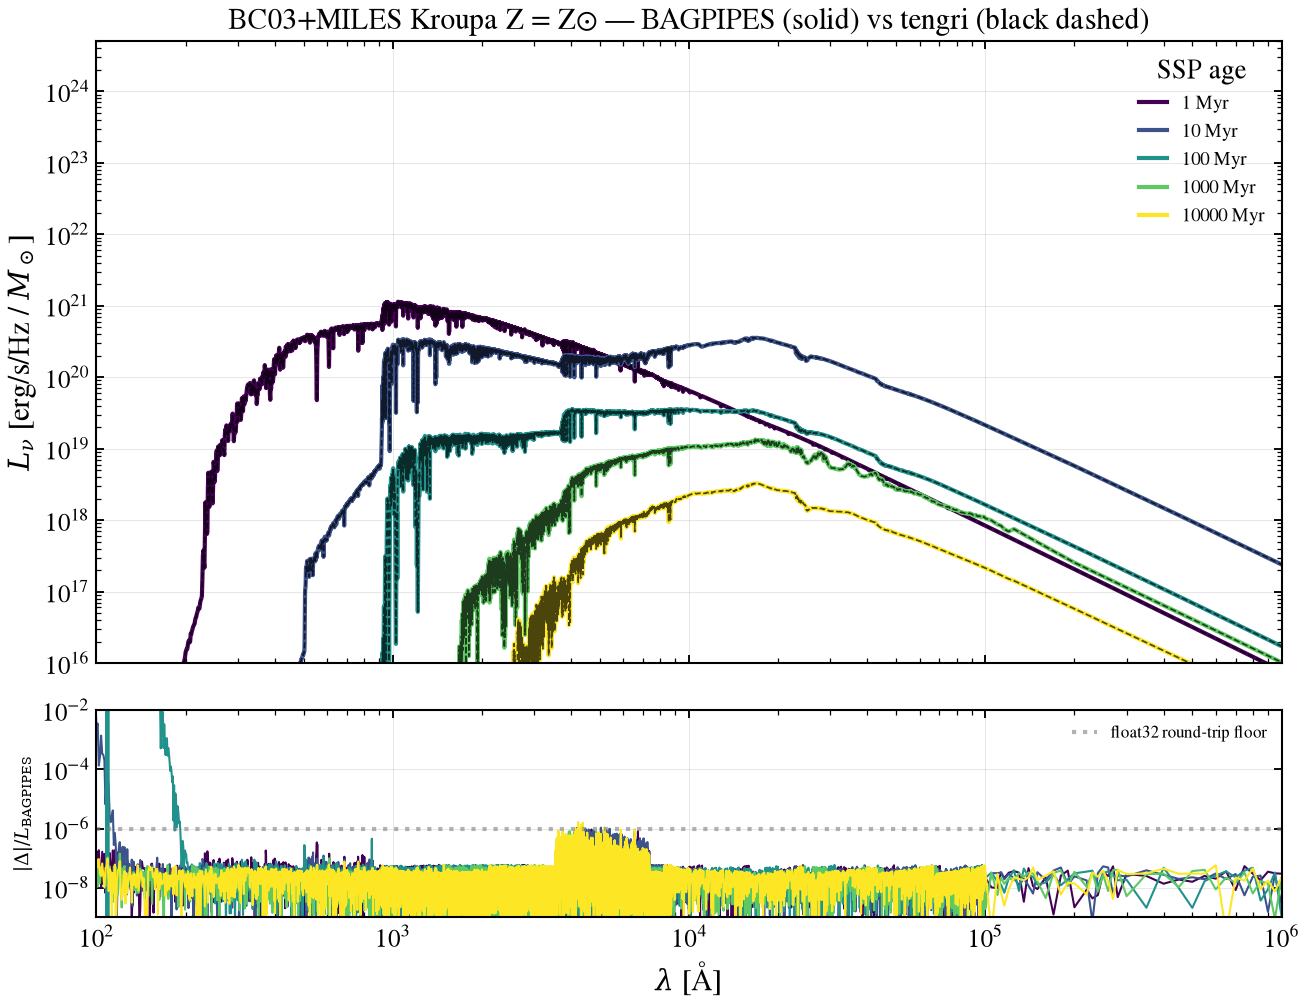

In [5]:
from astropy.io import fits as _fits

ages_yr = [1e6, 1e7, 1e8, 1e9, 1e10]
# BAGPIPES hard-codes its own solar luminosity, so its grid is scaled by that
# value and tengri's by tengri's. The 0.05% difference cancels in the ratio
# below. docs-const: intentional — upstream constant, not tengri's.
L_SUN_BAGPIPES = 3.826e33  # docs-const: intentional — BAGPIPES' own L_sun, not tengri's

_grid_path = Path(B.__file__).resolve().parent / "data"  # not used directly
_bagpipes_grid_dir = Path(__import__("bagpipes").config.grid_dir)
_fits_file = _bagpipes_grid_dir / "bc03_miles_stellar_grids.fits"
with _fits.open(_fits_file) as hdul:
    _wave_aa = np.asarray(hdul["WAVELENGTHS_AA"].data, dtype=np.float64)
    _age_yr_native = np.asarray(hdul["STELLAR_AGE_YR"].data, dtype=np.float64)
    _flux_zsol_aa = np.asarray(hdul["ZMET_1.000ZSOL"].data, dtype=np.float64)

bagpipes_ssp = []
for age_yr in ages_yr:
    ia = int(np.argmin(np.abs(_age_yr_native - age_yr)))
    # Lsun/Å/Msun → erg/s/Hz/Msun: × λ²/c × L_sun
    lnu = _flux_zsol_aa[ia] * _wave_aa**2 / C_AA * L_SUN_BAGPIPES
    bagpipes_ssp.append((_wave_aa, lnu))

i_zsun = int(np.argmin(np.abs(ssp.ssp_lgmet - LOG10_ZSUN)))
tengri_ssp = []
for age_yr in ages_yr:
    i_age = int(np.argmin(np.abs(ssp.ssp_lg_age_gyr - np.log10(age_yr / 1e9))))
    tengri_ssp.append((ssp.ssp_wave, ssp.ssp_flux[i_zsun, i_age, :] * L_SUN))

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
colors = plt.cm.viridis(np.linspace(0, 1, len(ages_yr)))
for color, age_yr, (w_b, L_b), (w_t, L_t) in zip(colors, ages_yr, bagpipes_ssp, tengri_ssp):
    label = f"{age_yr / 1e6:g} Myr"
    ax.plot(w_b, L_b, color=color, linewidth=2.0, label=label)
    ax.plot(w_t, L_t, color="k", linewidth=0.8, linestyle="--", alpha=0.7)
    L_t_on_b = U.regrid(w_t, L_t, w_b)
    resid = np.abs(L_t_on_b - L_b) / np.maximum(np.abs(L_b), 1e-30)
    resid[~np.isfinite(resid)] = 0.0
    ax_r.plot(w_b, resid, color=color, linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e6)
ax.set_ylim(1e16, 5e24)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz / $M_\odot$]")
ax.set_title("BC03+MILES Kroupa Z = Z⊙ — BAGPIPES (solid) vs tengri (black dashed)")
ax.legend(fontsize=9, title="SSP age")
ax.grid(True, alpha=0.3)
ax_r.set_xscale("log")
ax_r.set_yscale("log")
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"$|\Delta| / L_{\rm BAGPIPES}$", fontsize=9)
ax_r.set_ylim(1e-9, 1e-2)
ax_r.axhline(1e-6, color="gray", linestyle=":", alpha=0.6, label="float32 round-trip floor")
ax_r.legend(loc="upper right", fontsize=8)
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("bagpipes_01_ssp_templates.png")

def _ssp_deviation(w_b, L_b, w_t, L_t):
    """Max |tengri - BAGPIPES| / BAGPIPES where BAGPIPES carries more than 1e-4 of its peak."""
    keep = L_b > 1e-4 * L_b.max()
    return float(np.max(np.abs(U.regrid(w_t, L_t, w_b)[keep] - L_b[keep]) / L_b[keep]))


_ssp_dev = max(
    _ssp_deviation(w_b, L_b, w_t, L_t)
    for (w_b, L_b), (w_t, L_t) in zip(bagpipes_ssp, tengri_ssp)
)
print(f"§1 max |tengri - BAGPIPES| / BAGPIPES over the five SSPs, where BAGPIPES exceeds 1e-4 of its peak: {_ssp_dev:.2e}")
RESULTS["§1 SSP templates"] = ("max SSP flux deviation", _ssp_dev)

## §2 Star formation histories

Delayed-$\tau$, $\mathrm{SFR}(t) \propto t\,e^{-t/\tau}$, is built from the same $\tau$, age and
formed mass in both codes. The first panel shows $\mathrm{SFR}$ against cosmic time since
formation, and the printed integrals of each history over its full grid test the mass.

In [6]:
AV_FIDUCIAL = 1.0
# BAGPIPES's single screen has optical depth tau_V = A_V * ln(10) / 2.5 on the whole stellar continuum.
TAU_DIFF = AV_FIDUCIAL * np.log(10.0) / 2.5
TAU_BC = 0.0  # no extra birth-cloud attenuation at eta = 1

tengri   ∫SFR dt = 1.0000e+10 M☉  (log_total_mass=10 → 1.0000e+10)
BAGPIPES        ∫SFR dt = 9.9997e+09 M☉  (target: 1.0000e+10 from massformed=10)
  (after overlap masking) t_b range [0.1583, 4.9990] Gyr, t_t range [0.3315, 4.9990] Gyr


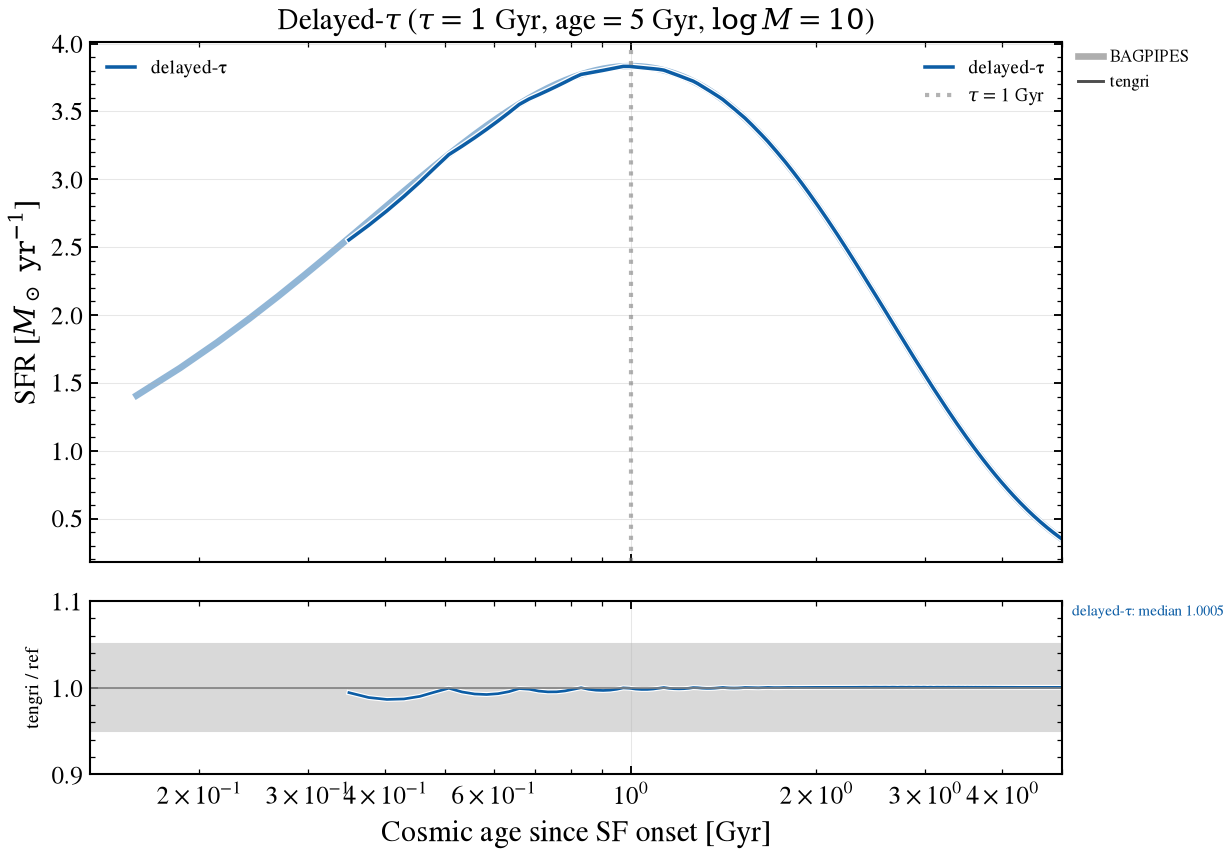

In [7]:
LOG_MASS_FIDUCIAL = 10.0
TAU_GYR_FIDUCIAL = 1.0
AGE_GYR_FIDUCIAL = 5.0

t_b, sfr_b = B.sfh_curve(
    sfh_type="delayed",
    age=AGE_GYR_FIDUCIAL,
    tau=TAU_GYR_FIDUCIAL,
    massformed=LOG_MASS_FIDUCIAL,
)
# BAGPIPES' sfh.ages is lookback time; convert to cosmic-age-since-onset
# for matched plotting.
t_b_cosmic_gyr = AGE_GYR_FIDUCIAL - t_b / 1e9
_keep = (t_b_cosmic_gyr >= 0) & (t_b_cosmic_gyr <= AGE_GYR_FIDUCIAL)
t_b_cosmic_gyr = t_b_cosmic_gyr[_keep]
sfr_b_keep = sfr_b[_keep]

_m_sfh = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
_state_sfh = _m_sfh.predict_state({})
_lbt_yr = np.asarray(_state_sfh.derived["sfh_grid_lbt_yr"])
_sfr_history = np.asarray(_state_sfh.derived["sfr_history"])
t_t = (AGE_GYR_FIDUCIAL - _lbt_yr / 1e9) * 1e9
# The SFH grid spans the full cosmic lookback; keep the epoch after formation.
_keep_t = t_t >= 0
t_t_valid = t_t[_keep_t]
_sfr_history_valid = _sfr_history[_keep_t]
assert t_t_valid.min() >= 0, f"negative cosmic age: min={t_t_valid.min()}"

# Formed mass: integrate each history over its whole lookback grid (the SFR is zero
# beyond the onset), so the segment between the last non-zero node and the zero node
# that closes the rising edge is included.
_order_t = np.argsort(_lbt_yr)
_mass_formed = float(np.trapezoid(_sfr_history[_order_t], _lbt_yr[_order_t]))
print(
    f"tengri   ∫SFR dt = {_mass_formed:.4e} M☉  (log_total_mass=10 → 1.0000e+10)"
)
_mass_b = float(np.trapezoid(sfr_b, t_b))
print(f"BAGPIPES        ∫SFR dt = {_mass_b:.4e} M☉  (target: 1.0000e+10 from massformed=10)")
RESULTS["§2 SFH: formed mass"] = ("integrated SFR, BAGPIPES vs 1e10", abs(_mass_b / 1e10 - 1.0))

# Ensure both arms have overlapping data: restrict to the common time range.
# Two-pass approach to handle discrete sampling mismatches:
# 1. Broad range based on array mins/maxes
t_min_broad = max(t_b_cosmic_gyr.min(), (t_t_valid / 1e9).min())
t_max_broad = min(t_b_cosmic_gyr.max(), (t_t_valid / 1e9).max())
_keep_b_1 = (t_b_cosmic_gyr >= t_min_broad) & (t_b_cosmic_gyr <= t_max_broad)
_keep_t_1 = (t_t_valid / 1e9 >= t_min_broad) & (t_t_valid / 1e9 <= t_max_broad)
# 2. Recalculate from actual masked samples to align boundaries
t_b_temp = t_b_cosmic_gyr[_keep_b_1]
t_t_temp = (t_t_valid / 1e9)[_keep_t_1]
t_min_aligned = max(t_b_temp.min(), t_t_temp.min())  # Both arms guaranteed to start here
_keep_final_b = (t_b_temp >= t_min_aligned)
_keep_final_t = (t_t_temp >= t_min_aligned)
t_b_cosmic_gyr_overlap = t_b_temp[_keep_final_b]
sfr_b_keep_overlap = sfr_b_keep[_keep_b_1][_keep_final_b]
t_t_valid_overlap = t_t_valid[_keep_t_1][_keep_final_t]
_sfr_history_valid_overlap = _sfr_history_valid[_keep_t_1][_keep_final_t]

print(
    f"  (after overlap masking) t_b range [{t_b_cosmic_gyr_overlap.min():.4f}, "
    f"{t_b_cosmic_gyr_overlap.max():.4f}] Gyr, "
    f"t_t range [{(t_t_valid_overlap/1e9).min():.4f}, {(t_t_valid_overlap/1e9).max():.4f}] Gyr"
)

fig, (ax, ax_r), _ = V.sweep_fig(
    [("delayed-τ", t_b_cosmic_gyr_overlap, sfr_b_keep_overlap, t_t_valid_overlap / 1e9, _sfr_history_valid_overlap)],
    ref_label="BAGPIPES",
    title=r"Delayed-$\tau$ ($\tau = 1$ Gyr, age = 5 Gyr, $\log M = 10$)",
    xlabel="Cosmic age since SF onset [Gyr]",
    ylabel=r"SFR [$M_\odot\ \mathrm{yr}^{-1}$]",
    xlim=(0, 5),
    logy=False,
    ratio_ylim=(0.9, 1.1),
    band=(0.95, 1.05),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
)
ax.axvline(
    TAU_GYR_FIDUCIAL,
    color="gray",
    linestyle=":",
    alpha=0.6,
    label=rf"$\tau$ = {TAU_GYR_FIDUCIAL:g} Gyr",
)
ax.legend(fontsize=9)
fig.tight_layout()
save_fig("bagpipes_02_sfh_delayed.png")

### Intrinsic SED per SFH form

Delayed-$\tau$ ($\tau = 0.3, 1, 3$ Gyr), constant, double power-law and lognormal histories, with the
nebular block on in both codes ($\log U = -2$). The double power-law and lognormal forms are cosmic-time
shapes, $T = \mathrm{age} - t_{\rm lookback}$, and tengri takes BAGPIPES's age of the universe and, for the
lognormal, BAGPIPES's solved width (both printed). The ladders give band ratios with the SEDs
integrated on their own nodes; the worst band of each case is named.

Ratio panels with the nebular block on omit the pixels within 500 km/s of a BAGPIPES emission line, where
BAGPIPES places each line in one model pixel and tengri gives it a 100 km/s width; the spectrum panels are
unchanged and line strengths are compared in §9.

In [8]:
assert abs(float(air_to_vac(6562.80)) - 6564.61) < 0.05, "air-to-vacuum relation does not reproduce H-alpha"


_mg_lines = B._build_model(
    {
        "redshift": 0.0,
        "constant": {"metallicity": 1.0, "age_min": 0.0, "age_max": 0.01, "massformed": 9.0},
        "nebular": {"logU": -2.0, "metallicity": 1.0},
    }
)
_wl_air, _ = B.line_table(_mg_lines)
# BAGPIPES labels the lines below 2000 A in vacuum and above in air.
LINE_MASK_AA = np.where(_wl_air > 2000.0, air_to_vac(_wl_air), _wl_air)

BAGPIPES age of the universe at z = 0: 13.466984 Gyr (tengri age_gyr); lognormal tmax = 4 Gyr, FWHM = 2 Gyr -> width 0.091279 dex (small-width estimate 0.092207 dex)


§2 intrinsic SED per SFH form:
  §2 delayed τ=0.3 Gyr                                 median 1.010x  worst 1.018x (GALEX NUV)  0/10 outside 5%
  §2 delayed τ=1.0 Gyr                                 median 1.002x  worst 0.993x (SDSS u)  0/10 outside 5%
  §2 delayed τ=3.0 Gyr                                 median 1.002x  worst 0.988x (SDSS u)  0/10 outside 5%
  §2 constant SFR age 0–5 Gyr                          median 1.002x  worst 0.987x (SDSS u)  0/10 outside 5%
  §2 dblplaw α=1.5 β=1 τ=3 Gyr                         median 1.002x  worst 0.990x (SDSS u)  0/10 outside 5%
  §2 lognormal tmax=4 Gyr FWHM=2 Gyr                   median 1.009x  worst 0.978x (GALEX FUV)  0/10 outside 5%


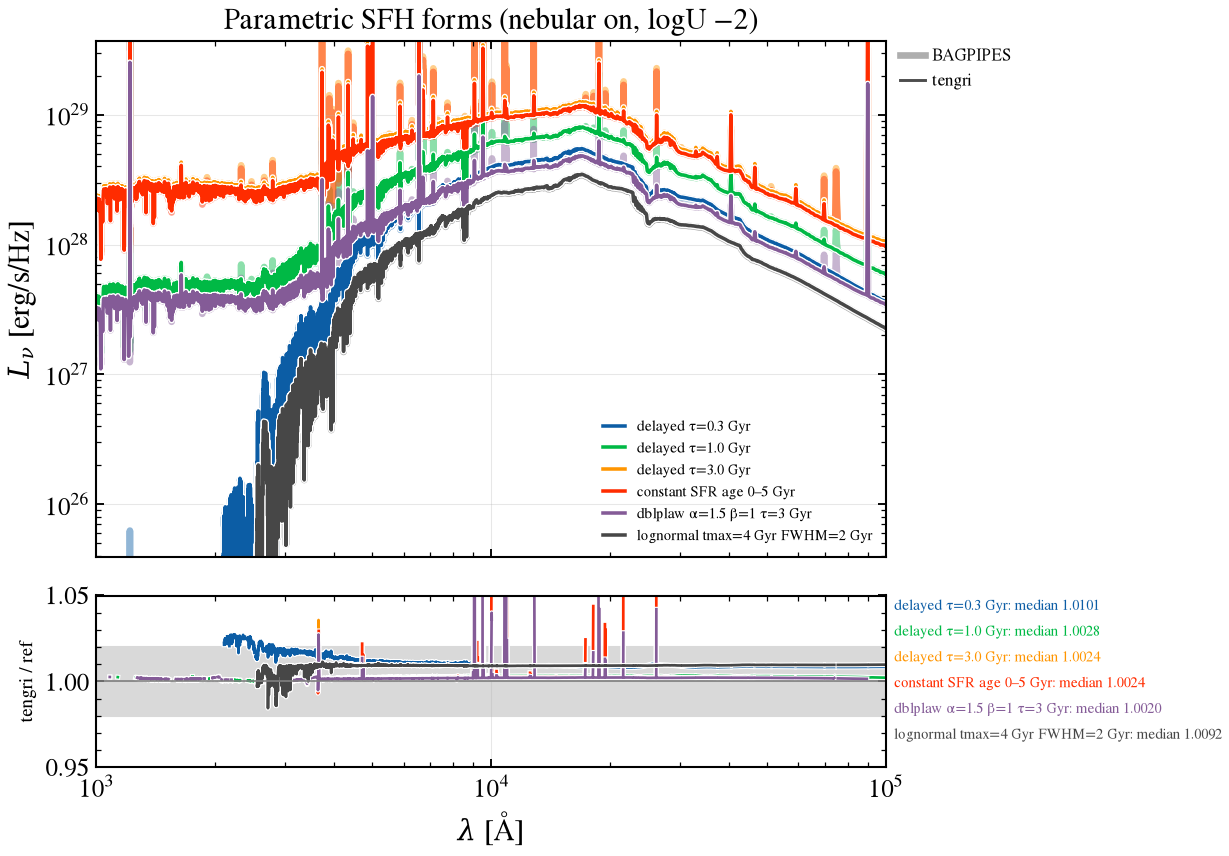

In [9]:
# The double power-law and lognormal forms are functions of cosmic time T = age - lookback.
# BAGPIPES anchors them to its own age of the universe at z = 0 and solves for the
# lognormal width; tengri's `dpl` / `lnorm` take the same two numbers.
_comp_b_dpl = {
    "redshift": 0.0,
    "dblplaw": {
        "alpha": 1.5,
        "beta": 1.0,
        "tau": 3.0,
        "metallicity": 1.0,
        "massformed": LOG_MASS_FIDUCIAL,
    },
    "dust": {"type": "Calzetti", "Av": 0.0},
    "nebular": {"logU": -2.0},
}
_mg_b_dpl = B._build_model(_comp_b_dpl)
AGE_OF_UNIVERSE_GYR = B.age_of_universe_gyr(_mg_b_dpl)
_LN_TMAX_GYR, _LN_FWHM_GYR = 4.0, 2.0
_ln_width_dex = B.lognormal_width_dex(_LN_TMAX_GYR, _LN_FWHM_GYR)
print(
    f"BAGPIPES age of the universe at z = 0: {AGE_OF_UNIVERSE_GYR:.6f} Gyr (tengri age_gyr); "
    f"lognormal tmax = {_LN_TMAX_GYR:g} Gyr, FWHM = {_LN_FWHM_GYR:g} Gyr -> width "
    f"{_ln_width_dex:.6f} dex (small-width estimate "
    f"{_LN_FWHM_GYR / (2.355 * _LN_TMAX_GYR * np.log(10.0)):.6f} dex)"
)

# Fiducial nebular block for all sweeps (logU -2 on both sides).
_NEB_FIDUCIAL = {"logU": -2.0}

cases_sfh = []
SFH_FORM_ROWS = {}

# 1. Delayed-τ with τ = 0.3 Gyr
for tau_gyr in [0.3, 1.0, 3.0]:
    label = f"delayed τ={tau_gyr:.1f} Gyr"
    w_ref, L_ref = B.attenuated_lnu(
        dust_block={"type": "Calzetti", "Av": 0.0},
        nebular_block={"logU": -2.0, "metallicity": 1.0},
        sfh_type="delayed",
        massformed=LOG_MASS_FIDUCIAL,
        metallicity=1.0,
        age=AGE_GYR_FIDUCIAL,
        tau=tau_gyr,
    )

    m_t = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(tau_gyr),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_t = m_t.predict_state({})
    L_t = s_t.sed_intrinsic
    cases_sfh.append((label, w_ref, L_ref, s_t.wave, L_t))

# 2. Constant SFR: age_min=0, age_max=5 Gyr
label = "constant SFR age 0–5 Gyr"
w_ref, L_ref = B.attenuated_lnu(
    dust_block={"type": "Calzetti", "Av": 0.0},
    nebular_block={"logU": -2.0, "metallicity": 1.0},
    sfh_type="constant",
    massformed=LOG_MASS_FIDUCIAL,
    metallicity=1.0,
    age=5.0,
)
m_t = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(5.0),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_t = m_t.predict_state({})
L_t = s_t.sed_intrinsic
cases_sfh.append((label, w_ref, L_ref, s_t.wave, L_t))

# 3. Double power-law: α=1.5, β=1.0, τ=3 Gyr
label = "dblplaw α=1.5 β=1 τ=3 Gyr"
w_ref_dpl = np.asarray(_mg_b_dpl.wavelengths, dtype=np.float64)
L_lambda_dpl = np.asarray(_mg_b_dpl.spectrum_full, dtype=np.float64)
_, L_ref = U.ergs_per_aa_to_erg_per_hz(w_ref_dpl, L_lambda_dpl)
w_ref = w_ref_dpl

m_t = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "dpl",
        "alpha": Fixed(1.5),
        "beta": Fixed(1.0),
        "tau_gyr": Fixed(3.0),
        "age_gyr": Fixed(AGE_OF_UNIVERSE_GYR),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_t = m_t.predict_state({})
L_t = s_t.sed_intrinsic
cases_sfh.append((label, w_ref, L_ref, s_t.wave, L_t))

# 4. Lognormal: tmax=4 Gyr, FWHM=2 Gyr
label = "lognormal tmax=4 Gyr FWHM=2 Gyr"
_comp_b_ln = {
    "redshift": 0.0,
    "lognormal": {
        "tmax": _LN_TMAX_GYR,
        "fwhm": _LN_FWHM_GYR,
        "metallicity": 1.0,
        "massformed": LOG_MASS_FIDUCIAL,
    },
    "dust": {"type": "Calzetti", "Av": 0.0},
    "nebular": {"logU": -2.0},
}
_mg_b_ln = B._build_model(_comp_b_ln)
w_ref_ln = np.asarray(_mg_b_ln.wavelengths, dtype=np.float64)
L_lambda_ln = np.asarray(_mg_b_ln.spectrum_full, dtype=np.float64)
_, L_ref = U.ergs_per_aa_to_erg_per_hz(w_ref_ln, L_lambda_ln)
w_ref = w_ref_ln

m_t = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "lnorm",
        "peak_gyr": Fixed(_LN_TMAX_GYR),
        "width_gyr": Fixed(_ln_width_dex),
        "age_gyr": Fixed(AGE_OF_UNIVERSE_GYR),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_t = m_t.predict_state({})
L_t = s_t.sed_intrinsic
cases_sfh.append((label, w_ref, L_ref, s_t.wave, L_t))

# Check comparability
for label, w_ref, L_ref, w_t, L_t in cases_sfh:
    _assert_comparable(L_ref, L_t, name=f"§2 {label}")

# Plot sweep with ratio panel
fig, (ax, ax_r), ratios = V.sweep_fig(
    cases_sfh,
    ref_label="BAGPIPES",
    title="Parametric SFH forms (nebular on, logU −2)",
    xlim=(1e3, 1e5),
    ratio_ylim=(0.95, 1.05),
    band=(0.98, 1.02),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
    mask_lines_aa=LINE_MASK_AA,
)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.get_legend().remove()
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
save_fig("bagpipes_03_sfh_forms.png")

# UV-to-NIR band ratios per SFH form.
print("§2 intrinsic SED per SFH form:")
# Band-average each tengri case on its native wavelength grid for filter calculation
for label, w_ref, L_ref, w_t, L_t in cases_sfh:
    rows = V.filter_rows_native(w_t, L_t, w_ref, L_ref, filters=V.UV_TO_NIR, integrate="sed")
    SFH_FORM_ROWS[label] = rows
    V.print_filter_table(
        rows,
        ref_name="BAGPIPES",
        title=f"§2 {label}",
        compact=True,
        show_worst_band=True,
    )
_sfh_dev = max(abs(r[4] - 1.0) for _rows in SFH_FORM_ROWS.values() for r in _rows if np.isfinite(r[4]))
RESULTS["§2 SFH forms"] = ("worst band ratio over the six forms", _sfh_dev)

## §3 Non-parametric continuity SFH

Piecewise-constant SFR with log-ratios between adjacent bins on the edges
$[0, 0.03, 0.1, 0.3, 1, 3, 6, T_U]$ Gyr of lookback, where $T_U$ is BAGPIPES's age of the universe (printed in
§2), six free log-ratios with $\mathrm{StudentT}(0, 0.3, 2)$ priors in both codes (Leja et al. 2019). tengri
takes the edges explicitly through `bin_edges_gyr`; its default ladder is scaled to the source redshift and
differs from BAGPIPES's. BAGPIPES indexes `dsfr` from oldest to youngest and tengri's `ratio_i` runs youngest to
oldest, so the BAGPIPES array is reversed. The printed table gives the mass formed in each bin over the exact value
that follows from the ratios, the edges and the total mass, for each code and for two tengri history grids, followed
by the stellar-only UV-to-NIR band ratios of the three histories.

§3 mass formed per lookback bin over the exact value from the ratios, edges and total mass (bins 0-0.03, 0.03-0.1, 0.1-0.3, 0.3-1, 1-3, 3-6, 6-13.467 Gyr):
    flat           tengri, 256-point history grid  1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 0.9962
                   tengri, 4096-point history grid 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 0.9997
                   BAGPIPES                          1.0012 1.0012 1.0012 1.0012 1.0012 1.0012 0.9986
    recent burst   tengri, 256-point history grid  1.0000 1.0000 1.0000 1.0000 0.9994 1.0251 1.0000
                   tengri, 4096-point history grid 1.0000 1.0000 1.0000 1.0000 0.9999 1.0016 1.0021
                   BAGPIPES                          1.0009 1.0009 1.0009 1.0009 0.9986 1.0009 1.0021
    quenched       tengri, 256-point history grid  0.9879 0.9994 1.0136 1.0347 1.0014 1.0313 0.9953
                   tengri, 4096-point history grid 1.0000 1.0009 1.0007 1.0006 1.0003 0.9997 0.9991
                   BAGPIPES             

**Caveat:** the bin masses of a tengri history read from its default 256-point lookback grid deviate from the exact values by up to 0.0347, in the bins next to a jump in the SFR, and by up to 0.0021 on a 4096-point grid (`n_grid=4096`; BAGPIPES 0.0112). The SED does not depend on the grid: the stellar band ratios above deviate from 1 by at most 0.002. Read the SFH of a continuity model with `n_grid=4096` when bin masses matter.

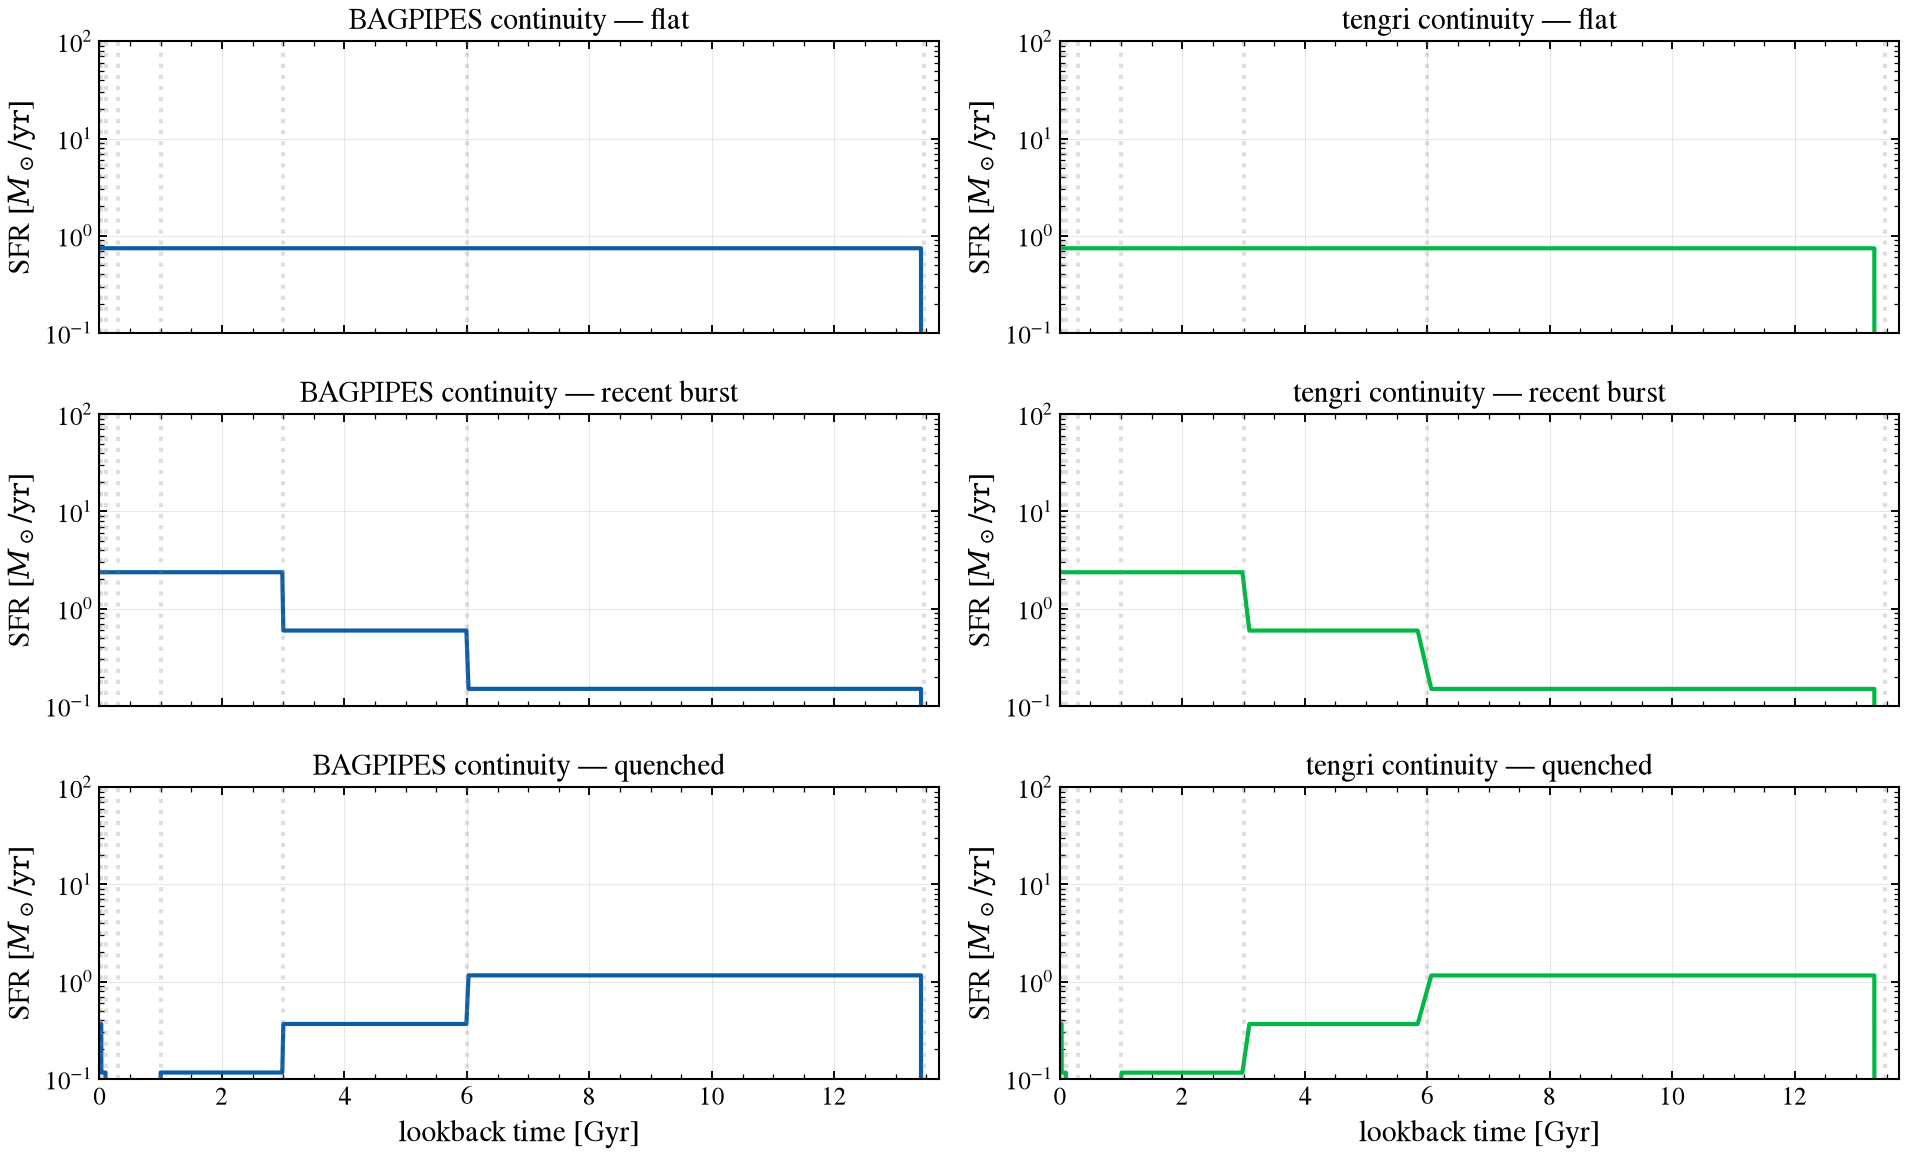

In [10]:
# Bin edges shared between codes. Both want them in **increasing**
# order (lookback time from 0 to age of universe). BAGPIPES expects
# Myr; tengri expects Gyr.
_BIN_EDGES_GYR = [0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 6.0, AGE_OF_UNIVERSE_GYR]
_BIN_EDGES_MYR_ASC = [e * 1e3 for e in _BIN_EDGES_GYR]

_cases = [
    ("flat", [0.0] * 6),
    ("recent burst", [0.0, 0.0, 0.0, 0.0, +0.6, +0.6]),
    ("quenched", [+0.5, +0.5, 0.0, -0.5, -0.5, -0.5]),
]

def _bin_masses(lbt_yr, sfr, edges_gyr):
    """Mass formed [Msun] in each lookback bin, trapezoid on a 2001-point grid per bin."""
    order = np.argsort(lbt_yr)
    out = []
    for lo, hi in zip(edges_gyr[:-1], edges_gyr[1:]):
        g = np.linspace(lo * 1e9, hi * 1e9, 2001)
        out.append(float(np.trapezoid(np.interp(g, lbt_yr[order], sfr[order]), g)))
    return np.array(out)


def _exact_bin_masses(log_ratios, edges_gyr, log_total_mass):
    """Mass formed [Msun] per bin from the inputs: SFR_j = 10**(sum of the ratios k >= j), scaled to the total."""
    log_sfr = np.append(np.cumsum(np.asarray(log_ratios)[::-1])[::-1], 0.0)
    unnorm = 10.0**log_sfr * np.diff(np.asarray(edges_gyr))
    return 10.0**log_total_mass * unnorm / unnorm.sum()


def _continuity_state(ratios, n_grid):
    """tengri state for a continuity history on BAGPIPES's bin edges, stellar light only."""
    return SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        n_grid=n_grid,
        sfh={
            "type": "continuity",
            "bin_edges_gyr": np.array(_BIN_EDGES_GYR),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            **{f"ratio_{i}": Fixed(ratios[i]) for i in range(6)},
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    ).predict_state({})


_CONT_BIN_MASSES = {}
_CONT_LADDERS = {}
fig, axes = plt.subplots(len(_cases), 2, figsize=(13, 8), sharex=True)
for row, (label, ratios) in enumerate(_cases):
    # BAGPIPES side
    comp_b = {
        "redshift": 0.0,
        "continuity": {
            "metallicity": 1.0,
            "massformed": LOG_MASS_FIDUCIAL,
            "bin_edges": _BIN_EDGES_MYR_ASC,
            # BAGPIPES indexes dsfr_i from OLDEST to YOUNGEST — reverse
            # the array so the SFR(t) shape matches tengri's young-first
            # convention.
            **{f"dsfr{i + 1}": ratios[5 - i] for i in range(6)},
        },
    }
    mg_b_c = B._build_model(comp_b)
    t_b_c = np.asarray(mg_b_c.sfh.ages, dtype=np.float64)
    sfr_b_c = np.asarray(mg_b_c.sfh.sfh, dtype=np.float64)

    # tengri side: the default 256-point history grid and a 4096-point one
    s_c = _continuity_state(ratios, 256)
    s_c_fine = _continuity_state(ratios, 4096)
    lbt_t_c = np.asarray(s_c.derived["sfh_grid_lbt_yr"])
    sfr_t_c = np.asarray(s_c.derived["sfr_history"])

    _exact = _exact_bin_masses(ratios, _BIN_EDGES_GYR, LOG_MASS_FIDUCIAL)
    _CONT_BIN_MASSES[label] = (
        _bin_masses(lbt_t_c, sfr_t_c, _BIN_EDGES_GYR) / _exact,
        _bin_masses(t_b_c, sfr_b_c, _BIN_EDGES_GYR) / _exact,
        _bin_masses(
            np.asarray(s_c_fine.derived["sfh_grid_lbt_yr"]),
            np.asarray(s_c_fine.derived["sfr_history"]),
            _BIN_EDGES_GYR,
        )
        / _exact,
    )
    _w_cb, _L_cb = B.to_lnu(mg_b_c)
    _CONT_LADDERS[label] = V.filter_rows_native(
        s_c.wave, s_c.sed_intrinsic, _w_cb, _L_cb, filters=V.UV_TO_NIR, integrate="sed"
    )
    ax_l, ax_r = axes[row]
    ax_l.plot(t_b_c / 1e9, sfr_b_c, "C0-", linewidth=2.0)
    ax_r.plot(lbt_t_c / 1e9, sfr_t_c, "C1-", linewidth=2.0)
    for ax in (ax_l, ax_r):
        ax.set_xlim(0, 13.7)
        ax.set_yscale("log")
        ax.set_ylim(1e-1, 1e2)
        ax.set_ylabel(r"SFR [$M_\odot/\mathrm{yr}$]")
        ax.grid(True, alpha=0.3)
        for edge in _BIN_EDGES_GYR:
            ax.axvline(edge, color="gray", linestyle=":", alpha=0.25)
    ax_l.set_title(f"BAGPIPES continuity — {label}")
    ax_r.set_title(f"tengri continuity — {label}")

for ax in axes[-1]:
    ax.set_xlabel("lookback time [Gyr]")

fig.tight_layout()
save_fig("bagpipes_04_sfh_continuity.png")

print("§3 mass formed per lookback bin over the exact value from the ratios, edges and total mass (bins " + ", ".join(
    f"{a:g}-{b:g}" for a, b in zip(_BIN_EDGES_GYR[:-1], _BIN_EDGES_GYR[1:])
) + " Gyr):")
for _label, (_rt, _rb, _rf) in _CONT_BIN_MASSES.items():
    print(f"    {_label:14s} tengri, 256-point history grid  " + " ".join(f"{v:.4f}" for v in _rt))
    print(f"    {'':14s} tengri, 4096-point history grid " + " ".join(f"{v:.4f}" for v in _rf))
    print(f"    {'':14s} BAGPIPES                          " + " ".join(f"{v:.4f}" for v in _rb))
_cont_dev_t = max(float(np.max(np.abs(v[0] - 1.0))) for v in _CONT_BIN_MASSES.values())
_cont_dev_f = max(float(np.max(np.abs(v[2] - 1.0))) for v in _CONT_BIN_MASSES.values())
_cont_dev_b = max(float(np.max(np.abs(v[1] - 1.0))) for v in _CONT_BIN_MASSES.values())
print(
    f"§3 worst bin deviation from the exact mass: tengri {_cont_dev_t:.4f} (256 points), {_cont_dev_f:.4f} (4096 points), "
    f"BAGPIPES {_cont_dev_b:.4f}"
)
print("§3 stellar-only UV-to-NIR band ratios tengri/BAGPIPES (" + ", ".join(lab.split()[-1] for _, lab in V.UV_TO_NIR) + "):")
for _label, _rows in _CONT_LADDERS.items():
    print(f"    {_label:14s} " + " ".join(f"{r[4]:.3f}" for r in _rows))
_cont_ladder_dev = max(abs(r[4] - 1.0) for _rows in _CONT_LADDERS.values() for r in _rows)
RESULTS["§3 continuity SFH"] = ("worst stellar band ratio over the three histories", _cont_ladder_dev)
caveat(
    f"the bin masses of a tengri history read from its default 256-point lookback grid deviate from the exact values by up "
    f"to {_cont_dev_t:.4f}, in the bins next to a jump in the SFR, and by up to {_cont_dev_f:.4f} on a 4096-point grid "
    f"(`n_grid=4096`; BAGPIPES {_cont_dev_b:.4f}). The SED does not depend on the grid: the stellar band ratios above "
    f"deviate from 1 by at most {_cont_ladder_dev:.3f}. Read the SFH of a continuity model with `n_grid=4096` when "
    f"bin masses matter."
)

## §4 Composite stellar SED

Stellar light from the delayed-$\tau$ history convolved with the BC03+MILES Kroupa SSPs, with no dust
or nebular emission, normalized to $10^{10}\,M_\odot$ formed. The ratio panel is shown at $\pm 2$ % over 100 Å to 10 µm, the range where the stellar SED is compared.

§4 stellar SED tengri/BAGPIPES optical (3000–10000 Å): median 1.003, P5 1.002, P95 1.003


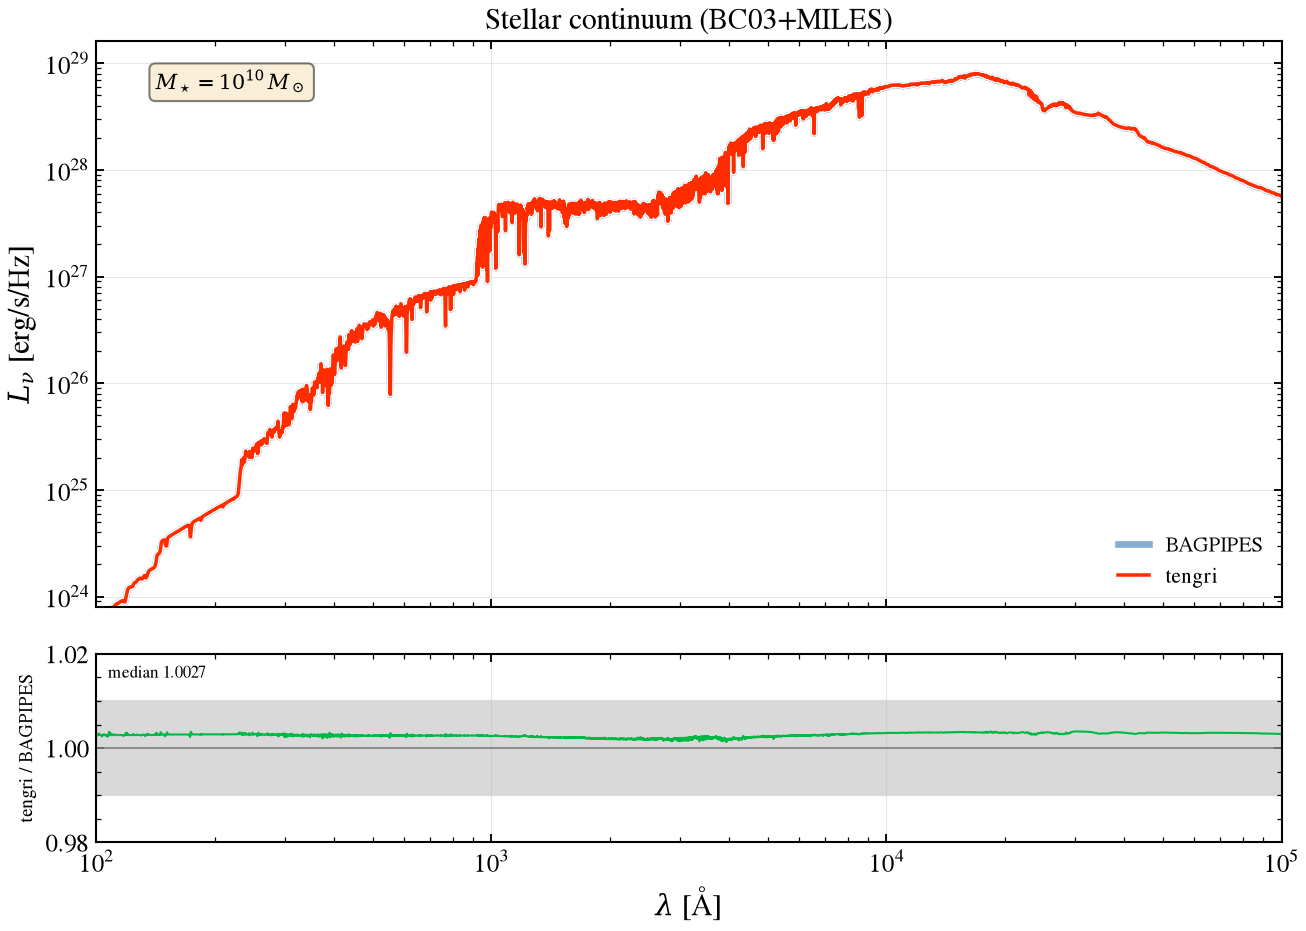

In [11]:
w_b, L_b = B.stellar_only_lnu(
    massformed=LOG_MASS_FIDUCIAL,
    metallicity=1.0,
    age_max=AGE_GYR_FIDUCIAL,
    tau=TAU_GYR_FIDUCIAL,
    sfh_type="delayed",
)

m_stellar = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_stellar = m_stellar.predict_state({})
_assert_comparable(L_b, s_stellar.sed_intrinsic, name="§4 stellar")

m_star_t = 10.0 ** float(s_stellar.derived["log_mstar"])
_ypk = float(max(np.max(L_b), np.max(np.asarray(s_stellar.sed_intrinsic))))

fig, ax, ax_r, _ = V.overlay_ratio_fig(
    w_b,
    L_b,
    s_stellar.wave,
    s_stellar.sed_intrinsic,
    xlabel=r"$\lambda$ [Å]",
    title="Stellar continuum (BC03+MILES)",
    ref_label="BAGPIPES",
    label_t="tengri",
    xlim=(1e2, 1e5),
    ratio_ylim=(0.98, 1.02),
    band=(0.99, 1.01),
    ref_style="line",
    annotate_median=True,
)
ax.text(
    0.05,
    0.95,
    rf"$M_\star = 10^{{{LOG_MASS_FIDUCIAL:.0f}}}\,M_\odot$",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
fig.tight_layout()
save_fig("bagpipes_05_stellar_sed.png")

# Median tengri/BAGPIPES ratio in the optical (3000–10000 Å), a useful
# scalar diagnostic for the docs page.
_mask_opt = (w_b >= 3000) & (w_b <= 10000)
_t_on_b = U.regrid(s_stellar.wave, np.asarray(s_stellar.sed_intrinsic), w_b)
_ratios = _t_on_b[_mask_opt] / L_b[_mask_opt]
_ratios = _ratios[np.isfinite(_ratios) & (_ratios > 0)]
if _ratios.size:
    RESULTS["§4 composite stellar SED"] = ("optical median, 3000-10000 A", abs(float(np.median(_ratios)) - 1.0))
    print(
        f"§4 stellar SED tengri/BAGPIPES optical (3000–10000 Å): "
        f"median {np.median(_ratios):.3f}, "
        f"P5 {np.percentile(_ratios, 5):.3f}, "
        f"P95 {np.percentile(_ratios, 95):.3f}"
    )

### Metallicity scatter

BAGPIPES uses one $Z$ per population. tengri's default spreads a requested metallicity over a
log-$Z$ distribution; every model on this page switches that off. The cell below builds the same
population with the default width and prints what it changes.

In [12]:
_m_default_scatter = SEDModel.build(
    ssp_data=ssp,
    met={"logzsol": Fixed(MET_LOGZSOL), "all_params": Fixed(DEFAULT)},
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
_default_scatter = float(_m_default_scatter.spec.get_distribution("met_logzsol_scatter").bounds[0])
_s_default = _m_default_scatter.predict_state({})
_rows_node = V.filter_rows_native(
    s_stellar.wave, s_stellar.sed_intrinsic, w_b, L_b, filters=V.UV_TO_NIR, integrate="sed"
)
_rows_default = V.filter_rows_native(
    _s_default.wave, _s_default.sed_intrinsic, w_b, L_b, filters=V.UV_TO_NIR, integrate="sed"
)
_by_band = {lab: (rn, rd) for (lab, _, _, _, rn), (_, _, _, _, rd) in zip(_rows_node, _rows_default)}
print(f"band ratios tengri/BAGPIPES, scatter {MET_SCATTER_DEX:g} dex / default {_default_scatter:g} dex:")
for _lab, (_rn, _rd) in _by_band.items():
    print(f"    {_lab:10s} {_rn:.4f} / {_rd:.4f}")
caveat(
    f"tengri's default metallicity scatter ({_default_scatter:g} dex) is an input BAGPIPES does not have. "
    f"For this population it changes the tengri/BAGPIPES ratio in SDSS g from {_by_band['SDSS g'][0]:.4f} to "
    f"{_by_band['SDSS g'][1]:.4f} and in GALEX NUV from {_by_band['GALEX NUV'][0]:.4f} to "
    f"{_by_band['GALEX NUV'][1]:.4f}. Every comparison on this page uses the {MET_SCATTER_DEX:g} dex width so "
    f"that the requested metallicity node is the only one weighted; a fit that leaves the scatter at its "
    f"default carries this offset relative to a single-$Z$ BAGPIPES model."
)

band ratios tengri/BAGPIPES, scatter 0.001 dex / default 0.1 dex:
    GALEX FUV  1.0023 / 1.0029
    GALEX NUV  1.0018 / 1.0030
    SDSS u     1.0027 / 1.0059
    SDSS g     1.0024 / 1.0052
    SDSS r     1.0028 / 1.0051
    SDSS i     1.0030 / 1.0047
    SDSS z     1.0032 / 1.0036
    2MASS J    1.0033 / 1.0028
    2MASS H    1.0034 / 1.0027
    2MASS Ks   1.0033 / 1.0030


**Caveat:** tengri's default metallicity scatter (0.1 dex) is an input BAGPIPES does not have. For this population it changes the tengri/BAGPIPES ratio in SDSS g from 1.0024 to 1.0052 and in GALEX NUV from 1.0018 to 1.0030. Every comparison on this page uses the 0.001 dex width so that the requested metallicity node is the only one weighted; a fit that leaves the scatter at its default carries this offset relative to a single-$Z$ BAGPIPES model.

### Reference convolution

The raw BAGPIPES SSP file convolved with each history on a 40001-node lookback grid, with linear weights
in $\log t$ onto the SSP age nodes, gives a reference for both codes. BAGPIPES bins the age axis
in 0.1-dex bins (`config.age_bins`) and integrates the history on that grid.

In [13]:
C_L = U.C_ANGSTROM_PER_S


def reference_lnu(sfr_of_lbt, lbt_max_yr, mass=1e10):
    """L_nu [erg/s/Hz] of a history convolved with the raw BAGPIPES SSP grid (Z = Z_sun,B).

    The history is sampled on a 40001-node log lookback grid and its mass is spread over the SSP
    age nodes with linear weights in log10(age); the SSP flux is the file's L_lambda per Msun.
    """
    lb = np.logspace(5, np.log10(lbt_max_yr), 40001)
    mid, dl = 0.5 * (lb[1:] + lb[:-1]), np.diff(lb)
    w = sfr_of_lbt(mid) * dl
    w = w * (mass / w.sum())
    la = np.log10(np.maximum(_age_yr_native, 1e5))
    x = np.log10(mid)
    idx = np.clip(np.searchsorted(la, x) - 1, 0, la.size - 2)
    f = (x - la[idx]) / (la[idx + 1] - la[idx])
    wn = np.zeros(la.size)
    np.add.at(wn, idx, w * (1.0 - f))
    np.add.at(wn, idx + 1, w * f)
    return (wn @ _flux_zsol_aa) * _wave_aa**2 / C_L * L_SUN_BAGPIPES


def _tengri_stellar(sfh):
    st = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh=sfh,
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    ).predict_state({})
    return np.asarray(st.wave, float), np.asarray(st.sed_intrinsic, float)


_aou_yr = AGE_OF_UNIVERSE_GYR * 1e9
_sig_ln = _ln_width_dex * np.log(10.0)
_t0_ln = np.log(_LN_TMAX_GYR * 1e9) + _sig_ln**2  # mode exp(t0 - sigma^2) = tmax
REF_CASES = {
    "delayed tau = 1 Gyr": (
        lambda lb: np.where(lb < 5e9, (5e9 - lb) * np.exp(-(5e9 - lb) / 1e9), 0.0),
        5e9,
        {"type": "delayed", "tau_gyr": Fixed(1.0), "age_gyr": Fixed(5.0), "log_total_mass": Fixed(10.0), "all_params": Fixed(DEFAULT)},
        {"delayed": {"metallicity": 1.0, "age": 5.0, "tau": 1.0, "massformed": 10.0}},
    ),
    "delayed tau = 0.3 Gyr": (
        lambda lb: np.where(lb < 5e9, (5e9 - lb) * np.exp(-(5e9 - lb) / 0.3e9), 0.0),
        5e9,
        {"type": "delayed", "tau_gyr": Fixed(0.3), "age_gyr": Fixed(5.0), "log_total_mass": Fixed(10.0), "all_params": Fixed(DEFAULT)},
        {"delayed": {"metallicity": 1.0, "age": 5.0, "tau": 0.3, "massformed": 10.0}},
    ),
    "lognormal": (
        lambda lb: np.where(
            lb < _aou_yr,
            np.exp(-((np.log(np.maximum(_aou_yr - lb, 1.0)) - _t0_ln) ** 2) / (2.0 * _sig_ln**2))
            / np.maximum(_aou_yr - lb, 1.0),
            0.0,
        ),
        _aou_yr * 0.999999,
        {"type": "lnorm", "peak_gyr": Fixed(_LN_TMAX_GYR), "width_gyr": Fixed(_ln_width_dex), "age_gyr": Fixed(AGE_OF_UNIVERSE_GYR), "log_total_mass": Fixed(10.0), "all_params": Fixed(DEFAULT)},
        {"lognormal": {"tmax": _LN_TMAX_GYR, "fwhm": _LN_FWHM_GYR, "metallicity": 1.0, "massformed": 10.0}},
    ),
}
REF_RATIOS = {}
print("§4 band ratios against the reference convolution (SDSS bands in the UV-to-NIR ladder order):")
print(f"{'':24s}" + "".join(f"{lab.split()[-1]:>8s}" for _, lab in V.UV_TO_NIR))
for _name, (_sfr, _lbmax, _sfh_t, _comp_b) in REF_CASES.items():
    _ref = reference_lnu(_sfr, _lbmax)
    _wt, _Lt = _tengri_stellar(_sfh_t)
    _wb, _Lb = B.to_lnu(B._build_model({"redshift": 0.0, **_comp_b}))
    _rt = np.array([r[4] for r in V.filter_rows_native(_wt, _Lt, _wave_aa, _ref, filters=V.UV_TO_NIR, integrate="sed")])
    _rb = np.array([r[4] for r in V.filter_rows_native(_wb, _Lb, _wave_aa, _ref, filters=V.UV_TO_NIR, integrate="sed")])
    REF_RATIOS[_name] = (_rt, _rb)
    print(f"{_name:18s} tengri   " + "".join(f"{v:8.4f}" for v in _rt))
    print(f"{'':18s} BAGPIPES " + "".join(f"{v:8.4f}" for v in _rb))
_dev_t = {k: float(np.max(np.abs(v[0] - 1.0))) for k, v in REF_RATIOS.items()}
_dev_b = {k: float(np.max(np.abs(v[1] - 1.0))) for k, v in REF_RATIOS.items()}
_lab_idx = {lab: i for i, (_, lab) in enumerate(V.UV_TO_NIR)}
_tau03 = REF_RATIOS["delayed tau = 0.3 Gyr"][1][_lab_idx["GALEX NUV"]]
_lnorm = REF_RATIOS["lognormal"][1][_lab_idx["GALEX FUV"]]
_f2 = lambda form, band: {r[0]: r[4] for r in SFH_FORM_ROWS[form]}[band]
caveat(
    "Against the reference convolution (a fine-grid convolution of the same SSP file with the exact history) the worst "
    "band of tengri deviates by "
    + ", ".join(f"{_dev_t[k]:.4f} ({k})" for k in REF_CASES)
    + ", and that of BAGPIPES by "
    + ", ".join(f"{_dev_b[k]:.4f}" for k in REF_CASES)
    + f". BAGPIPES integrates the history on its 0.1-dex age grid (`config.age_bins`), which contributes to its offsets; "
    f"this cell does not isolate it as the whole cause. The BAGPIPES offsets are the band ratios of §2: "
    f"BAGPIPES/reference is {_tau03:.4f} in GALEX NUV for $\\tau = 0.3$ Gyr and {_lnorm:.4f} in GALEX FUV for the "
    f"lognormal, against tengri/BAGPIPES of {_f2('delayed τ=0.3 Gyr', 'GALEX NUV'):.3f} and "
    f"{_f2('lognormal tmax=4 Gyr FWHM=2 Gyr', 'GALEX FUV'):.3f}."
)

§4 band ratios against the reference convolution (SDSS bands in the UV-to-NIR ladder order):
                             FUV     NUV       u       g       r       i       z       J       H      Ks


delayed tau = 1 Gyr tengri     1.0061  1.0044  1.0014  1.0004  1.0002  1.0001  1.0001  1.0000  1.0000  1.0000
                   BAGPIPES   1.0037  1.0026  0.9986  0.9980  0.9973  0.9971  0.9969  0.9968  0.9967  0.9967


delayed tau = 0.3 Gyr tengri     1.0004  1.0001  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                   BAGPIPES   0.9912  0.9824  0.9829  0.9878  0.9890  0.9895  0.9899  0.9910  0.9915  0.9919


lognormal          tengri     1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
                   BAGPIPES   1.0226  1.0056  0.9891  0.9907  0.9905  0.9907  0.9909  0.9910  0.9909  0.9909


**Caveat:** Against the reference convolution (a fine-grid convolution of the same SSP file with the exact history) the worst band of tengri deviates by 0.0061 (delayed tau = 1 Gyr), 0.0004 (delayed tau = 0.3 Gyr), 0.0000 (lognormal), and that of BAGPIPES by 0.0037, 0.0176, 0.0226. BAGPIPES integrates the history on its 0.1-dex age grid (`config.age_bins`), which contributes to its offsets; this cell does not isolate it as the whole cause. The BAGPIPES offsets are the band ratios of §2: BAGPIPES/reference is 0.9824 in GALEX NUV for $\tau = 0.3$ Gyr and 1.0226 in GALEX FUV for the lognormal, against tengri/BAGPIPES of 1.018 and 0.978.

## §5 Metallicity

$Z/Z_{\odot,B} \in \{0.2, 0.5, 1, 1.5, 2.5\}$ on the fiducial history, stellar light only (the nebular response to
metallicity is in §9). The cases at 0.2, 1 and 2.5 request a BC03 grid node in both codes; 0.5
and 1.5 fall between nodes, where BAGPIPES interpolates linearly in $Z$ and tengri applies a
triweight kernel in $\log Z$ (width fixed at its smallest value).

  §5 Z = 0.2 Z☉                                        median 1.002x  worst 1.003x (SDSS u)  0/10 outside 5%
  §5 Z = 0.5 Z☉                                        median 1.017x  worst 1.038x (SDSS u)  0/10 outside 5%
  §5 Z = 1 Z☉                                          median 1.003x  worst 1.003x (2MASS H)  0/10 outside 5%
  §5 Z = 1.5 Z☉                                        median 1.047x  worst 1.090x (SDSS u)  5/10 outside 5%
  §5 Z = 2.5 Z☉                                        median 1.002x  worst 1.003x (SDSS z)  0/10 outside 5%


**Caveat:** between SSP metallicity nodes the codes interpolate differently (BAGPIPES linearly in $Z$ between the two straddling nodes, tengri with a triweight kernel in $\log Z$). At the node metallicities ($Z/Z_{\odot,B} = 0.2, 1, 2.5$) the worst band ratio deviates from 1 by 0.003; between nodes ($0.5, 1.5$) it deviates by 0.090 (SDSS u at $Z/Z_{\odot,B} = 1.5$). A fit that places stars between BC03 metallicity nodes inherits the difference between the two interpolation schemes, mostly in the blue bands.

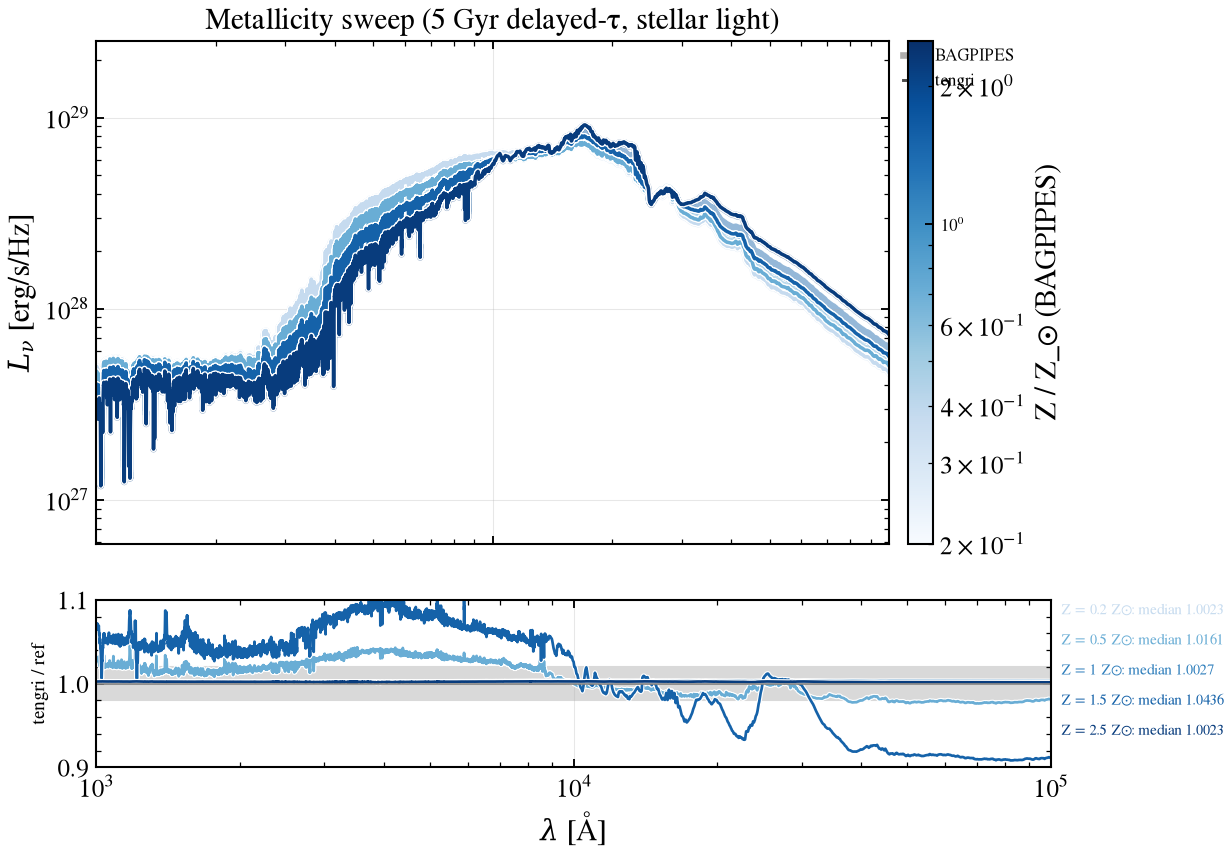

In [14]:
_Z_EXTENDED = [0.2, 0.5, 1.0, 1.5, 2.5]
# Convert BAGPIPES metallicity fractions to tengri's absolute Z pins.
_logzsol_extended = [float(np.log10(z * Z_SUN_BAGPIPES) - LOG10_ZSUN) for z in _Z_EXTENDED]
# Gas metallicity is matched as each code's solar-scaled value: Z_gas / Z_gas,sun = z.
_loggas_extended = [float(np.log10(z)) for z in _Z_EXTENDED]

cases_z = []
for z, logz, loggas in zip(_Z_EXTENDED, _logzsol_extended, _loggas_extended):
    w_b_z, L_b_z = B.attenuated_lnu(
        dust_block={"type": "Calzetti", "Av": 0.0},
        sfh_type="delayed",
        massformed=LOG_MASS_FIDUCIAL,
        metallicity=z,
        age=AGE_GYR_FIDUCIAL,
        tau=TAU_GYR_FIDUCIAL,
    )

    m_z_neb = SEDModel.build(
        ssp_data=ssp,
        met={"logzsol": Fixed(logz), **MET_NODE},
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_z_neb = m_z_neb.predict_state({})
    L_t_z = s_z_neb.sed_intrinsic
    _assert_comparable(L_b_z, L_t_z, name=f"§5 Z={z:g}")
    cases_z.append((f"Z = {z:g} Z⊙", w_b_z, L_b_z, s_z_neb.wave, L_t_z))

# Plot with ratio panel
fig, (ax, ax_r), ratios = V.sweep_fig(
    cases_z,
    ref_label="BAGPIPES",
    title="Metallicity sweep (5 Gyr delayed-τ, stellar light)",
    xlim=(1e3, 1e5),
    ratio_ylim=(0.9, 1.1),
    band=(0.98, 1.02),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
    cmap="Blues",
    values=[0.2, 0.5, 1.0, 1.5, 2.5],
    param_label="Z / Z_☉ (BAGPIPES)",
)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
fig.tight_layout()
save_fig("bagpipes_06_metallicity.png")

# UV-to-NIR band ratios per metallicity, SEDs integrated on their own nodes.
_Z_ROWS = {}
for _z, (_lab, _wb, _Lb, _wt, _Lt) in zip(_Z_EXTENDED, cases_z):
    _Z_ROWS[_z] = V.filter_rows_native(_wt, np.asarray(_Lt), _wb, _Lb, filters=V.UV_TO_NIR, integrate="sed")
    V.print_filter_table(
        _Z_ROWS[_z], ref_name="BAGPIPES", title=f"§5 Z = {_z:g} Z☉", compact=True, show_worst_band=True
    )
_NODE_ZS_PAGE = (0.2, 1.0, 2.5)
_dev_node = max(abs(r[4] - 1.0) for z in _NODE_ZS_PAGE for r in _Z_ROWS[z] if np.isfinite(r[4]))
_dev_between = max(abs(r[4] - 1.0) for z in _Z_EXTENDED if z not in _NODE_ZS_PAGE for r in _Z_ROWS[z] if np.isfinite(r[4]))
RESULTS["§5 metallicity"] = ("worst band, nodes and between nodes", max(_dev_node, _dev_between))
_wz, _wr = max(
    ((z, r) for z in _Z_EXTENDED if z not in _NODE_ZS_PAGE for r in _Z_ROWS[z] if np.isfinite(r[4])),
    key=lambda t: abs(t[1][4] - 1.0),
)
caveat(
    f"between SSP metallicity nodes the codes interpolate differently (BAGPIPES linearly in $Z$ between the "
    f"two straddling nodes, tengri with a triweight kernel in $\\log Z$). At the node metallicities "
    f"($Z/Z_{{\\odot,B}} = 0.2, 1, 2.5$) the worst band ratio deviates from 1 by {_dev_node:.3f}; between nodes "
    f"($0.5, 1.5$) it deviates by {_dev_between:.3f} ({_wr[0]} at $Z/Z_{{\\odot,B}} = {_wz:g}$). A fit that places stars between "
    f"BC03 metallicity nodes inherits the difference between the two interpolation schemes, mostly in the blue bands."
)

## §6 Attenuation curves

$A(\lambda)/A_V$ for Calzetti et al. (2000), Cardelli et al. (1989) and Salim et al. (2018) at
$\delta = 0$, each normalized at 5500 Å. BAGPIPES's `Salim` is tengri's `salim_sbl18`. Charlot & Fall
(2000) is a two-component prescription in BAGPIPES and is not a single-screen law, so it is not
compared here. BAGPIPES re-emits the absorbed light in the infrared whenever a `dust` block is present, so its
curve, read from a spectrum ratio, is shown to 1.2 µm; the infrared emission is compared in §8.

§6 Calzetti A(5500 Å)/A_V as returned: BAGPIPES 0.99947, tengri 1.00000
§6 A(λ)/A_V, tengri / BAGPIPES, Calzetti: 1500 Å 0.9924, 2175 Å 0.9935, 3000 Å 0.9949, 5500 Å 1.0005
§6 max |tengri/BAGPIPES - 1| over 1300-12000 Å: Calzetti+2000 0.0122, Cardelli+1989 (MW) 0.0135, Salim+2018 (δ=0) 0.0140
§6 wavelength of that maximum [Å]: Calzetti+2000 10557, Cardelli+1989 (MW) 10557, Salim+2018 (δ=0) 1300


**Caveat:** BAGPIPES's Calzetti curve uses the coefficient 2.695 on the 0.12-0.63 µm branch (`dust_attenuation_model.py`, lines 175-179), where Calzetti et al. (2000) give 2.659, which tengri uses. The tengri/BAGPIPES ratio of $A(\lambda)/A_V$ is 0.9924 at 1500 Å and 0.9949 at 3000 Å, so BAGPIPES attenuates the UV more strongly at fixed $A_V$; the effect enters the §7 band ratios in the near-UV bands. Both curves are evaluated at exactly the quoted wavelengths at $A_V = 1$; BAGPIPES's own curve is 0.99947 $A_V$ at 5500 Å and tengri's 1.00000, so the ratio at 5500 Å is 1.0005. The plotted curves are each divided by their own value at 5500 Å.

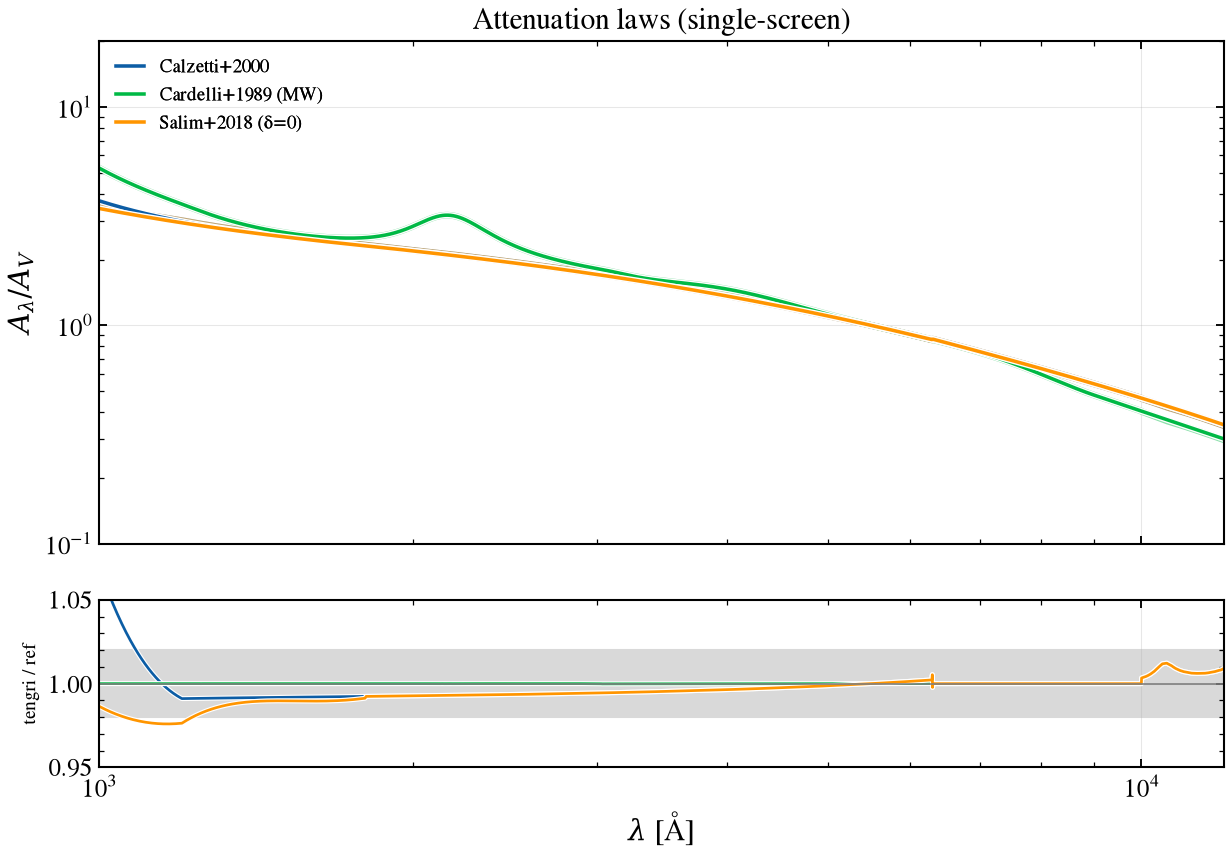

In [15]:
from tengri.dust import list_laws

# (BAGPIPES dust block, tengri law, label) for three matched single-screen laws.
# Charlot & Fall 2000 is excluded: it is a two-component prescription in BAGPIPES
# (birth-cloud attenuation + ISM), while tengri's noll09 is single-screen only.
_law_pairs = [
    ({"type": "Calzetti", "Av": 1.0}, "calzetti", "Calzetti+2000"),
    ({"type": "Cardelli", "Av": 1.0}, "cardelli", "Cardelli+1989 (MW)"),
    ({"type": "Salim", "Av": 1.0, "delta": 0.0, "B": 0.0}, "salim_sbl18", "Salim+2018 (δ=0)"),
]
_tengri_laws = list_laws(headline=False).to_dict("fn")  # {name: fn(wave_aa) -> k at tau_V=1}
wave_law = np.logspace(np.log10(1000.0), np.log10(50000.0), 2000)


def _norm_AV(wave, A):
    """A(λ) normalized to its own value interpolated at exactly 5500 Å."""
    return A / np.interp(5500.0, wave, A)


cases_laws = []
_raw_laws = {}
for dust_block, tengri_law, label in _law_pairs:
    try:
        w_b, A_b = B.attenuation_curve(dust_block)
        A_b_norm = _norm_AV(w_b, A_b)
    except Exception as exc:
        print(f"  skip BAGPIPES {label!r}: {exc}")
        continue

    A_t = np.asarray(_tengri_laws[tengri_law](wave_law))
    A_t_norm = _norm_AV(wave_law, A_t)
    cases_laws.append((label, w_b, A_b_norm, wave_law, A_t_norm))
    _raw_laws[label] = (w_b, A_b, wave_law, A_t)

fig, (ax, ax_r), ratios_laws = V.sweep_fig(
    cases_laws,
    ref_label="BAGPIPES",
    title="Attenuation laws (single-screen)",
    xlabel=r"$\lambda$ [Å]",
    ylabel=r"$A_\lambda / A_V$",
    xlim=(1e3, 1.2e4),
    logy=True,
    ratio_ylim=(0.95, 1.05),
    band=(0.98, 1.02),
    ref_style="line",
    fixed_ratio_ylim=True,
)
ax.set_ylim(1e-1, 2e1)
fig.tight_layout()
save_fig("bagpipes_07_attenuation_curves.png")

_lab_c, _wb_c, _Ab_c, _wt_c, _At_c = cases_laws[0]
# Both curves as returned at A_V = 1, interpolated to exactly the quoted wavelengths.
_w_b_raw, _A_b_raw, _w_t_raw, _A_t_raw = _raw_laws[_lab_c]
_A5500_b = float(np.interp(5500.0, _w_b_raw, _A_b_raw))
_A5500_t = float(np.interp(5500.0, _w_t_raw, _A_t_raw))
print(f"§6 Calzetti A(5500 Å)/A_V as returned: BAGPIPES {_A5500_b:.5f}, tengri {_A5500_t:.5f}")
_calz = {
    lam: float(np.interp(lam, _w_t_raw, _A_t_raw) / np.interp(lam, _w_b_raw, _A_b_raw))
    for lam in (1500.0, 2175.0, 3000.0, 5500.0)
}
_law_dev = {
    lab: float(np.max(np.abs(np.interp(np.geomspace(1300.0, 1.2e4, 400), wt, At) / np.interp(np.geomspace(1300.0, 1.2e4, 400), wb, Ab) - 1.0)))
    for lab, wb, Ab, wt, At in cases_laws
}
print("§6 A(λ)/A_V, tengri / BAGPIPES, Calzetti: " + ", ".join(f"{lam:g} Å {v:.4f}" for lam, v in _calz.items()))
print("§6 max |tengri/BAGPIPES - 1| over 1300-12000 Å: " + ", ".join(f"{k} {v:.4f}" for k, v in _law_dev.items()))
_dev_all = {
    lab: np.abs(np.interp(np.geomspace(1300.0, 1.2e4, 400), wt, At) / np.interp(np.geomspace(1300.0, 1.2e4, 400), wb, Ab) - 1.0)
    for lab, wb, Ab, wt, At in cases_laws
}
_lam_grid = np.geomspace(1300.0, 1.2e4, 400)
_lam_max = {k: float(_lam_grid[int(np.argmax(v))]) for k, v in _dev_all.items()}
print("§6 wavelength of that maximum [Å]: " + ", ".join(f"{k} {v:.0f}" for k, v in _lam_max.items()))
RESULTS["§6 attenuation curves"] = ("Calzetti A/A_V at 1500 A", abs(_calz[1500.0] - 1.0))
caveat(
    f"BAGPIPES's Calzetti curve uses the coefficient 2.695 on the 0.12-0.63 µm branch "
    f"(`dust_attenuation_model.py`, lines 175-179), where Calzetti et al. (2000) give 2.659, which tengri uses. "
    f"The tengri/BAGPIPES ratio of $A(\\lambda)/A_V$ is {_calz[1500.0]:.4f} at 1500 Å and {_calz[3000.0]:.4f} at "
    f"3000 Å, so BAGPIPES attenuates the UV more strongly at fixed $A_V$; the effect enters the §7 band ratios in "
    f"the near-UV bands. Both curves are evaluated at exactly the quoted wavelengths at $A_V = 1$; BAGPIPES's own "
    f"curve is {_A5500_b:.5f} $A_V$ at 5500 Å and tengri's {_A5500_t:.5f}, so the ratio at 5500 Å is "
    f"{_calz[5500.0]:.4f}. The plotted curves are each divided by their own value at 5500 Å."
)

## §7 Attenuated SED and the `eta` mapping

BAGPIPES's `{"type": "Calzetti", "Av": A_V}` is one screen of optical depth
$\tau_V = A_V \ln 10 / 2.5$ on the whole stellar continuum, which tengri reproduces with
`tau_diff` $= \tau_V$ and `tau_bc = 0`. With `eta` $\neq 1$ BAGPIPES attenuates stars
younger than `t_bc` by an extra $(\eta - 1) A_V$, mapped to `tau_bc` $= (\eta - 1)\,\tau_V$.

In [16]:
from tengri.components.dust.two_component import DustSEDComponentConfig, _young_indicator

_gate_cfg = DustSEDComponentConfig()
_ages_probe_yr = np.array([3e6, 1e7, 3e7])
_gate = np.asarray(_young_indicator(_ages_probe_yr, _gate_cfg.t_birth_yr, _gate_cfg.transition_width_dex))
print(
    f"tengri birth-cloud gate: logistic in log10(age), centered at {_gate_cfg.t_birth_yr:.0e} yr, width "
    f"{_gate_cfg.transition_width_dex:g} dex; fraction of stars inside the cloud at 3, 10, 30 Myr: "
    + ", ".join(f"{g:.3f}" for g in _gate)
    + " (BAGPIPES: 1, 1, 0 for t_bc = 0.01 Gyr)"
)

# A young burst, eta = 2: constant SFR over the last 30 Myr, stellar light only.
_ETA = 2.0
_burst_b = {
    "redshift": 0.0,
    "constant": {"metallicity": 1.0, "age_min": 0.0, "age_max": 0.03, "massformed": 8.0},
    "dust": {"type": "Calzetti", "Av": AV_FIDUCIAL, "eta": _ETA},
}
_wb_burst, _Lb_burst = B.to_lnu(B._build_model(_burst_b))
_m_burst = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(0.03),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(8.0),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed((_ETA - 1.0) * TAU_DIFF),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
_s_burst = _m_burst.predict_state({})
_rows_burst = V.filter_rows_native(
    _s_burst.wave, _s_burst.derived["sed_dust_attenuated"], _wb_burst, _Lb_burst,
    filters=V.UV_TO_NIR, integrate="sed",
)
_burst = {lab: r for lab, _, _, _, r in _rows_burst}
print(
    "§7 young burst (constant SFR over 30 Myr), eta = 2, tengri/BAGPIPES: "
    + ", ".join(f"{k} {v:.3f}" for k, v in _burst.items())
)
RESULTS["§7 birth-cloud gate (eta = 2, 30 Myr burst)"] = (
    "worst UV-NIR band", max(abs(v - 1.0) for v in _burst.values())
)
caveat(
    f"with $\\eta = {_ETA:g}$ BAGPIPES attenuates every star younger than `t_bc` by the extra screen, a step at "
    f"10 Myr, while tengri's gate falls over about 0.3 dex ({_gate[0]:.3f}, {_gate[1]:.3f} and {_gate[2]:.3f} of the "
    f"stars inside the cloud at 3, 10 and 30 Myr). For a 30 Myr constant-SFR burst the tengri/BAGPIPES band ratios "
    f"are {_burst['GALEX FUV']:.3f} in GALEX FUV, {_burst['GALEX NUV']:.3f} in NUV and {_burst['SDSS g']:.3f} in SDSS g. "
    f"For populations that are old compared with 30 Myr, or at $\\eta = 1$, the gate does not act and the "
    f"mapping in the table above is exact."
)

tengri birth-cloud gate: logistic in log10(age), centered at 1e+07 yr, width 0.3 dex; fraction of stars inside the cloud at 3, 10, 30 Myr: 0.851, 0.500, 0.169 (BAGPIPES: 1, 1, 0 for t_bc = 0.01 Gyr)


§7 young burst (constant SFR over 30 Myr), eta = 2, tengri/BAGPIPES: GALEX FUV 0.770, GALEX NUV 0.862, SDSS u 0.929, SDSS g 0.938, SDSS r 0.951, SDSS i 0.958, SDSS z 0.960, 2MASS J 0.916, 2MASS H 0.931, 2MASS Ks 0.892


**Caveat:** with $\eta = 2$ BAGPIPES attenuates every star younger than `t_bc` by the extra screen, a step at 10 Myr, while tengri's gate falls over about 0.3 dex (0.851, 0.500 and 0.169 of the stars inside the cloud at 3, 10 and 30 Myr). For a 30 Myr constant-SFR burst the tengri/BAGPIPES band ratios are 0.770 in GALEX FUV, 0.862 in NUV and 0.938 in SDSS g. For populations that are old compared with 30 Myr, or at $\eta = 1$, the gate does not act and the mapping in the table above is exact.

### $A_V$, curve family and `eta`

Calzetti $A_V \in \{0.3, 1, 3\}$, power-law slopes $n \in \{0.5, 0.7, 1\}$ (Charlot & Fall 2000, $\eta = 1$),
Salim $(\delta, B)$ pairs and Cardelli, with the nebular block on and the fiducial history, shown to 2.5 µm (the infrared emission BAGPIPES adds at longer
wavelengths is compared in §8).

§7 Salim δ=-0.3 B=0: A(2175)/A_V = BAGPIPES 2.786, tengri 2.767


§7 Salim δ=+0.0 B=1: A(2175)/A_V = BAGPIPES 2.353, tengri 2.338


§7 Salim δ=+0.3 B=3: A(2175)/A_V = BAGPIPES 2.090, tengri 2.079


  §7 Calzetti A_V=0.3                                  median 1.002x  worst 1.008x (GALEX FUV)  0/10 outside 5%
  §7 Calzetti A_V=1                                    median 1.001x  worst 1.021x (GALEX FUV)  0/10 outside 5%
  §7 Calzetti A_V=3                                    median 1.001x  worst 1.057x (GALEX FUV)  1/10 outside 5%
  §7 CF00 n=0.5                                        median 1.001x  worst 0.993x (SDSS u)  0/10 outside 5%
  §7 CF00 n=0.7                                        median 1.000x  worst 0.993x (SDSS u)  0/10 outside 5%
  §7 CF00 n=1.0                                        median 1.000x  worst 0.993x (SDSS u)  0/10 outside 5%
  §7 Salim δ=-0.3 B=0                                  median 1.001x  worst 1.037x (GALEX FUV)  0/10 outside 5%
  §7 Salim δ=+0.0 B=1                                  median 1.002x  worst 1.030x (GALEX FUV)  0/10 outside 5%
  §7 Salim δ=+0.3 B=3                                  median 1.003x  worst 1.023x (GALEX FUV)  0/10 outside 5%
 

**Caveat:** the largest band deviation in the attenuation sweeps is 0.057 (Calzetti A_V=3, GALEX FUV). BAGPIPES's Calzetti coefficient (§6) makes its attenuation at 1500 Å 0.76 % larger relative to A_V than tengri's. Combined with the stellar-only ratio, that predicts a GALEX FUV band ratio of 1.008, 1.021 and 1.058 at $A_V = 0.3, 1, 3$; the measured values are 1.008, 1.021 and 1.057, so the prediction is within 0.001 at all three (-0.000, -0.000, +0.001). The effect scales with $A_V$; outside the GALEX bands the Calzetti cases deviate from 1 by at most 0.008.

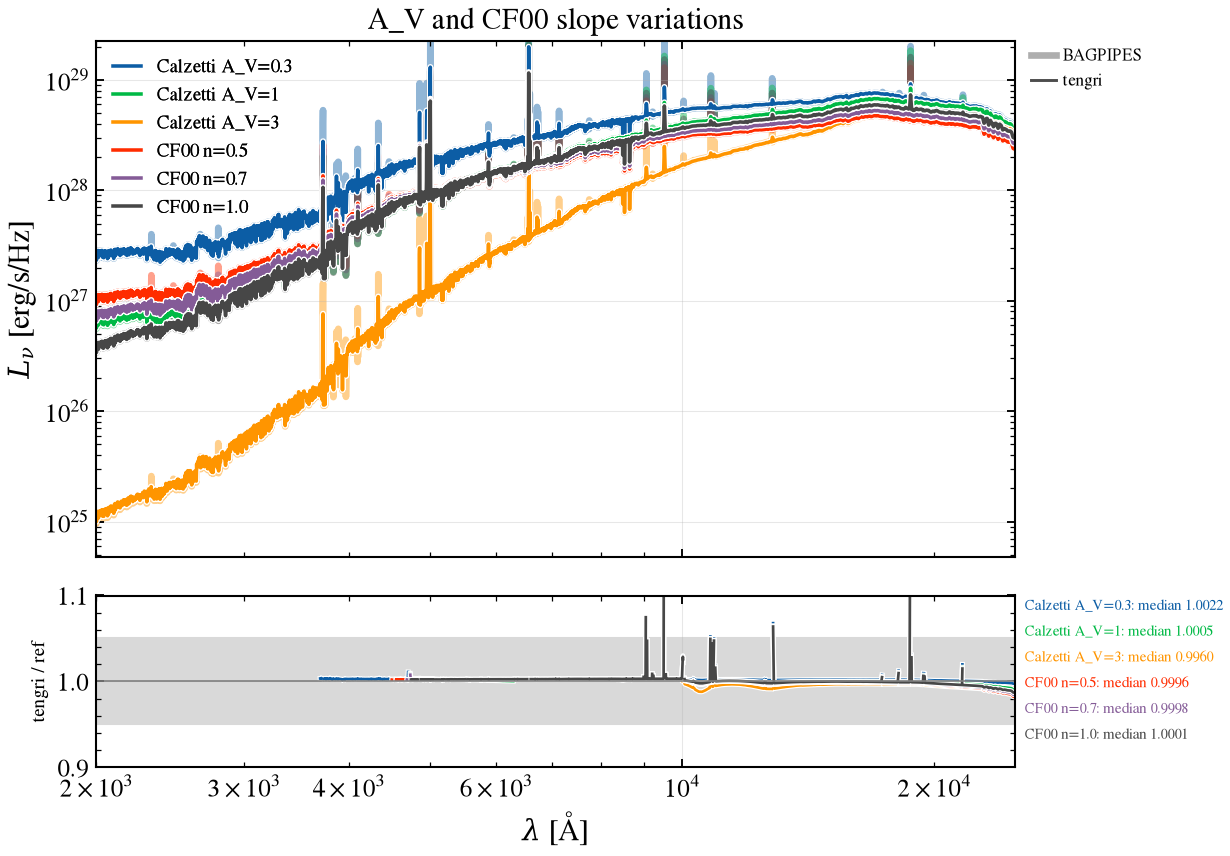

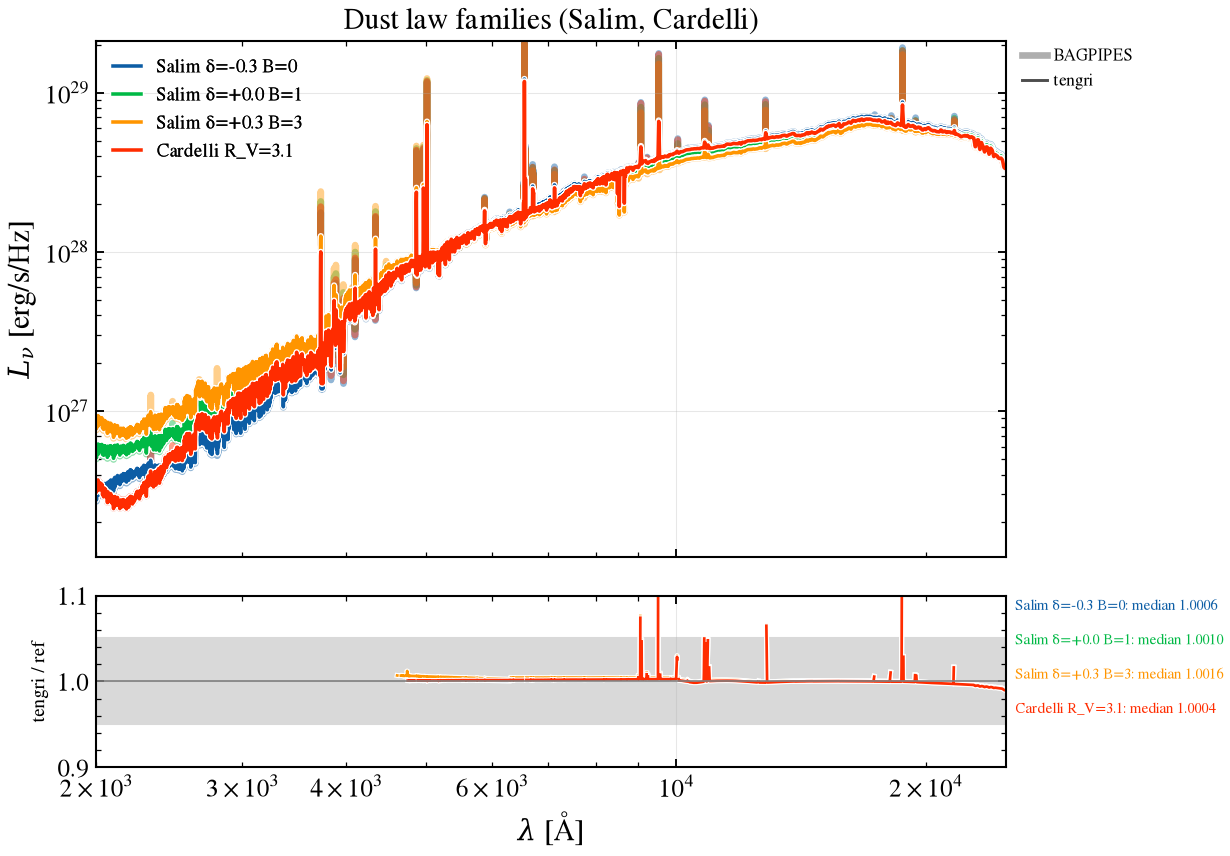

In [17]:
# Figure 1: A_V and eta variations with Calzetti + CF00
cases_av = []

# Calzetti A_V sweep
for av in [0.3, 1.0, 3.0]:
    label = f"Calzetti A_V={av:g}"
    w_ref, L_ref = B.attenuated_lnu(
        dust_block={"type": "Calzetti", "Av": av},
        nebular_block={"logU": -2.0, "metallicity": 1.0},
        sfh_type="delayed",
        massformed=LOG_MASS_FIDUCIAL,
        metallicity=1.0,
        age=AGE_GYR_FIDUCIAL,
        tau=TAU_GYR_FIDUCIAL,
    )
    tau_diff_av = av * np.log(10.0) / 2.5

    m_av = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "type": "two_component",
            "law_bc": "calzetti",
            "law_diff": "calzetti",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(tau_diff_av),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_av = m_av.predict_state({})
    L_t = s_av.sed_intrinsic
    _assert_comparable(L_ref, L_t, name=f"§7 {label}")
    cases_av.append((label, w_ref, L_ref, s_av.wave, L_t))

# CF00 with n sweep (eta=1.0 fixed)
for n in [0.5, 0.7, 1.0]:
    label = f"CF00 n={n:.1f}"
    w_ref, L_ref = B.attenuated_lnu(
        dust_block={"type": "CF00", "Av": 1.0, "n": n, "eta": 1.0},
        nebular_block={"logU": -2.0, "metallicity": 1.0},
        sfh_type="delayed",
        massformed=LOG_MASS_FIDUCIAL,
        metallicity=1.0,
        age=AGE_GYR_FIDUCIAL,
        tau=TAU_GYR_FIDUCIAL,
    )
    slope_diff_n = -n

    m_n = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "type": "two_component",
            "law_bc": "power_law",
            "law_diff": "power_law",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(AV_FIDUCIAL * np.log(10.0) / 2.5),
            "slope_diff": slope_diff_n,
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_n = m_n.predict_state({})
    L_t = s_n.sed_intrinsic
    _assert_comparable(L_ref, L_t, name=f"§7 {label}")
    cases_av.append((label, w_ref, L_ref, s_n.wave, L_t))

fig, (ax, ax_r), ratios = V.sweep_fig(
    cases_av,
    ref_label="BAGPIPES",
    title="A_V and CF00 slope variations",
    xlim=(2e3, 2.5e4),
    ratio_ylim=(0.9, 1.1),
    band=(0.95, 1.05),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
    mask_lines_aa=LINE_MASK_AA,
)
fig.tight_layout()
save_fig("bagpipes_08_dust_av_slope.png")

# Figure 2: Dust laws (Salim, Cardelli) with bump characterization
cases_laws = []

# Salim (delta, B) sweep: calculate A(2175)/A_V for reference
for delta, b in [(-0.3, 0.0), (0.0, 1.0), (0.3, 3.0)]:
    label = f"Salim δ={delta:+.1f} B={b:.0f}"
    w_ref, L_ref = B.attenuated_lnu(
        dust_block={"type": "Salim", "Av": 1.0, "delta": delta, "B": b},
        nebular_block={"logU": -2.0, "metallicity": 1.0},
        sfh_type="delayed",
        massformed=LOG_MASS_FIDUCIAL,
        metallicity=1.0,
        age=AGE_GYR_FIDUCIAL,
        tau=TAU_GYR_FIDUCIAL,
    )

    m_salim = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "type": "two_component",
            "law": "salim_sbl18",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(AV_FIDUCIAL * np.log(10.0) / 2.5),
            "delta_diff": delta,
            "bump_strength_diff": b,
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_salim = m_salim.predict_state({})
    L_t = s_salim.sed_intrinsic
    _assert_comparable(L_ref, L_t, name=f"§7 {label}")

    # Calculate A(2175)/A_V on both sides, anchored at exactly 2175 and
    # 5500 Å so the two grids' sampling drops out of the ratio: the BAGPIPES
    # curve is a spectrum ratio on its model wavelength grid, interpolated to
    # the two anchors; the tengri law evaluates at the anchors directly.
    w_ref_bump, A_ref_bump = B.attenuation_curve(
        dust_block={"type": "Salim", "Av": 1.0, "delta": delta, "B": b}
    )
    a_2175_ref = float(
        np.interp(2175.0, w_ref_bump, A_ref_bump)
        / np.interp(5500.0, w_ref_bump, A_ref_bump)
    )

    _A_t_anchor = np.asarray(
        _tengri_laws["salim_sbl18"](
            np.array([2175.0, 5500.0]), dust_bump_strength=b, dust_delta=delta
        )
    )
    a_2175_t = float(_A_t_anchor[0] / _A_t_anchor[1])

    print(
        f"§7 Salim δ={delta:+.1f} B={b:.0f}: "
        f"A(2175)/A_V = BAGPIPES {a_2175_ref:.3f}, tengri {a_2175_t:.3f}"
    )

    cases_laws.append((label, w_ref, L_ref, s_salim.wave, L_t))

# Cardelli
label = "Cardelli R_V=3.1"
w_ref, L_ref = B.attenuated_lnu(
    dust_block={"type": "Cardelli", "Av": 1.0},
    nebular_block={"logU": -2.0, "metallicity": 1.0},
    sfh_type="delayed",
    massformed=LOG_MASS_FIDUCIAL,
    metallicity=1.0,
    age=AGE_GYR_FIDUCIAL,
    tau=TAU_GYR_FIDUCIAL,
)

m_cardelli = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law": "cardelli",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(AV_FIDUCIAL * np.log(10.0) / 2.5),
        "Rv_diff": 3.1,
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_cardelli = m_cardelli.predict_state({})
L_t = s_cardelli.sed_intrinsic
_assert_comparable(L_ref, L_t, name=f"§7 {label}")
cases_laws.append((label, w_ref, L_ref, s_cardelli.wave, L_t))

fig, (ax, ax_r), ratios = V.sweep_fig(
    cases_laws,
    ref_label="BAGPIPES",
    title="Dust law families (Salim, Cardelli)",
    xlim=(2e3, 2.5e4),
    ratio_ylim=(0.9, 1.1),
    band=(0.95, 1.05),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
    mask_lines_aa=LINE_MASK_AA,
)
fig.tight_layout()
save_fig("bagpipes_09_dust_laws.png")

# UV-to-NIR band ratios for every case of the two sweeps, worst band named.
_dust_rows = {}
for _lab, _wb, _Lb, _wt, _Lt in cases_av + cases_laws:
    _dust_rows[_lab] = V.filter_rows_native(_wt, np.asarray(_Lt), _wb, _Lb, filters=V.UV_TO_NIR, integrate="sed")
    V.print_filter_table(
        _dust_rows[_lab], ref_name="BAGPIPES", title=f"§7 {_lab}", compact=True, show_worst_band=True
    )
# FUV ratio expected from the Calzetti coefficient alone: BAGPIPES's A(1500 Å) = A_V k_B, tengri's = r k_B A_V.
_k1500 = float(np.interp(1500.0, _w_b_raw, _A_b_raw))
_stellar_fuv = _by_band["GALEX FUV"][0]
print("§7 Calzetti, GALEX FUV tengri/BAGPIPES: measured / predicted from the A(1500 Å)/A_V ratio of §6 times the stellar-only ratio")
_calz_pred = {}
_calz_meas = {}
for _av in (0.3, 1.0, 3.0):
    _meas = {r[0]: r[4] for r in _dust_rows[f"Calzetti A_V={_av:g}"]}["GALEX FUV"]
    _calz_meas[_av] = _meas
    _calz_pred[_av] = _stellar_fuv * 10.0 ** (0.4 * _av * _k1500 * (1.0 - _calz[1500.0]))
    print(f"    A_V = {_av:g}: {_meas:.3f} / {_calz_pred[_av]:.3f}")
_calz_nongalex = max(
    abs(r[4] - 1.0)
    for _k, _rows in _dust_rows.items() if _k.startswith("Calzetti")
    for r in _rows if np.isfinite(r[4]) and not r[0].startswith("GALEX")
)
_worst_case = max(
    _dust_rows, key=lambda k: max(abs(r[4] - 1.0) for r in _dust_rows[k] if np.isfinite(r[4]))
)
_dust_dev = max(abs(r[4] - 1.0) for r in _dust_rows[_worst_case] if np.isfinite(r[4]))
print(f"§7 worst case of the sweeps: {_worst_case}")
RESULTS["§7 attenuated SED"] = (f"worst band over the sweeps ({_worst_case})", _dust_dev)
caveat(
    f"the largest band deviation in the attenuation sweeps is {_dust_dev:.3f} ({_worst_case}, GALEX FUV). BAGPIPES's "
    f"Calzetti coefficient (§6) makes its attenuation at 1500 Å {(1.0 - _calz[1500.0]) * 100:.2f} % larger relative to "
    f"A_V than tengri's. Combined with the stellar-only ratio, that predicts a GALEX FUV band ratio of "
    f"{_calz_pred[0.3]:.3f}, {_calz_pred[1.0]:.3f} and {_calz_pred[3.0]:.3f} at $A_V = 0.3, 1, 3$; the measured values are "
    f"{_calz_meas[0.3]:.3f}, {_calz_meas[1.0]:.3f} and {_calz_meas[3.0]:.3f}, so the prediction is within "
    f"{max(abs(_calz_pred[a] - _calz_meas[a]) for a in _calz_pred):.3f} at all three ({_calz_pred[0.3] - _calz_meas[0.3]:+.3f}, "
    f"{_calz_pred[1.0] - _calz_meas[1.0]:+.3f}, {_calz_pred[3.0] - _calz_meas[3.0]:+.3f}). The effect scales with $A_V$; outside the GALEX bands the Calzetti cases "
    f"deviate from 1 by at most {_calz_nongalex:.3f}."
)

## §8 Dust emission and energy balance

Absorbed stellar light is re-emitted through Draine & Li (2007) templates with parameters
$(q_{\rm PAH}, U_{\min}, \gamma)$. tengri conserves energy by construction: the printed
$L_{\rm IR}$ equals $L_{\rm abs}$. The sweep varies each parameter around the fiducial with the nebular
block on in both codes, and the band ratios use the thirteen bands of the helper's IR ladder, 3.4-863 µm.

tengri energy balance: L_absorbed = 2.047e+43, L_IR_emitted = 2.047e+43, resid = 0.00e+00


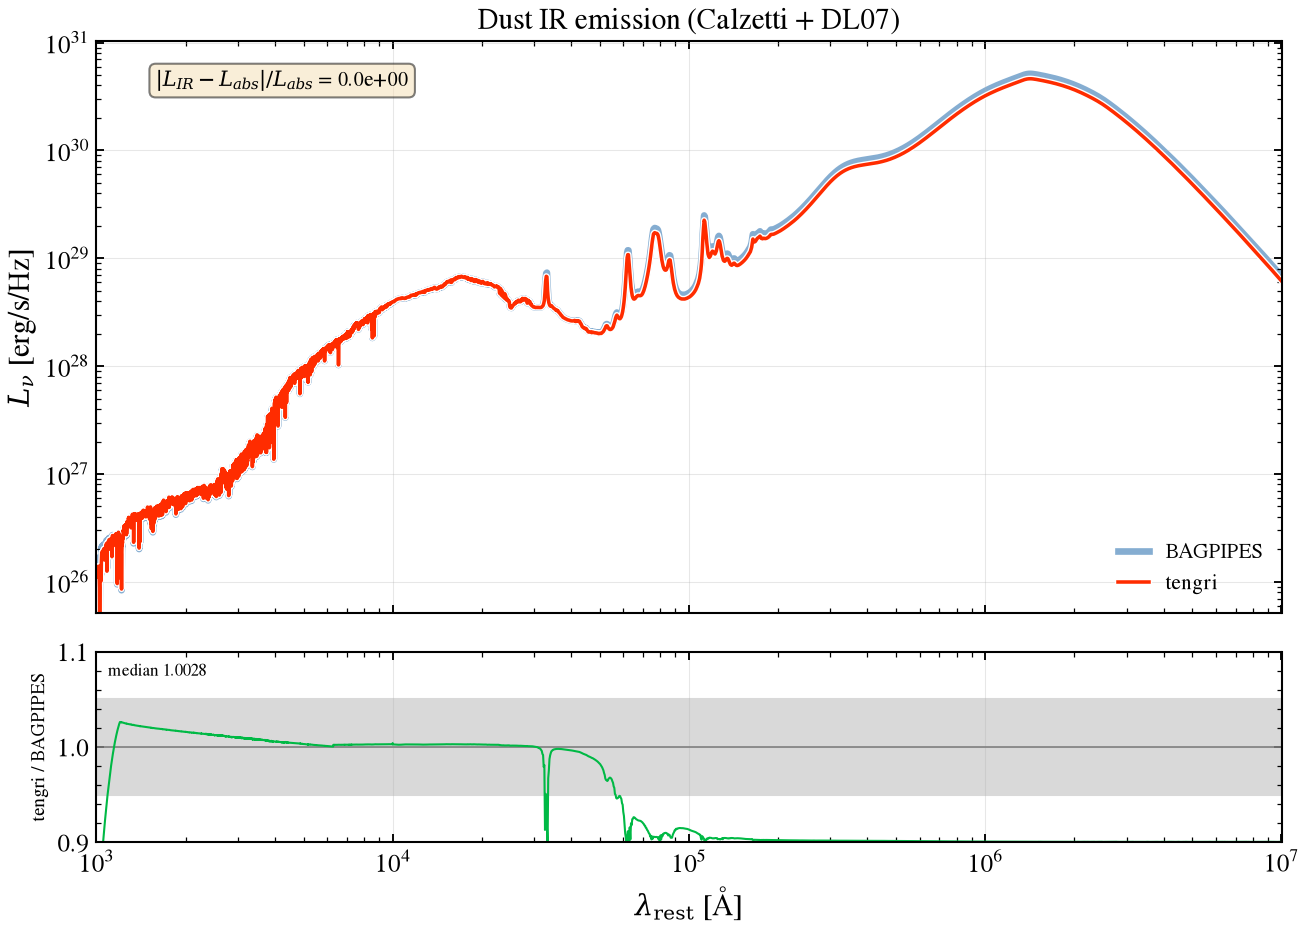

In [18]:
QPAH_FIDUCIAL = 2.5
UMIN_FIDUCIAL = 1.0
GAMMA_FIDUCIAL = 0.05

# Bagpipes: dust + dust_emission triggered by including `dust` block
# with the energy-balance autoflag. We use the same Calzetti fiducial
# as §5, plus the DL07 emission block.
comp_b = {
    "redshift": 0.0,
    "delayed": {
        "metallicity": 1.0,
        "age": AGE_GYR_FIDUCIAL,
        "tau": TAU_GYR_FIDUCIAL,
        "massformed": LOG_MASS_FIDUCIAL,
    },
    "dust": {
        "type": "Calzetti",
        "Av": AV_FIDUCIAL,
        "eta": 1.0,
        "qpah": QPAH_FIDUCIAL,
        "umin": UMIN_FIDUCIAL,
        "gamma": GAMMA_FIDUCIAL,
    },
}
mg_b = B._build_model(comp_b)
w_b_ir, L_b_ir = B.to_lnu(mg_b)

m_ir = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_ir = m_ir.predict_state({})

_L_abs = float(np.asarray(s_ir.derived["L_absorbed"]))
_L_ir = float(np.asarray(s_ir.derived["L_ir"]))
_eb_resid = abs(_L_ir - _L_abs) / max(_L_abs, 1e-30)
print(
    f"tengri energy balance: L_absorbed = {_L_abs:.3e}, "
    f"L_IR_emitted = {_L_ir:.3e}, resid = {_eb_resid:.2e}"
)

sed_full_t = s_ir.derived["sed_dust_attenuated"] + s_ir.derived["sed_dust_ir"]
_ypk = float(max(np.max(L_b_ir), np.max(np.asarray(sed_full_t))))

fig, ax, ax_r, _ = V.overlay_ratio_fig(
    w_b_ir,
    L_b_ir,
    s_ir.wave,
    sed_full_t,
    xlabel=r"$\lambda_{\rm rest}$ [Å]",
    title="Dust IR emission (Calzetti + DL07)",
    ref_label="BAGPIPES",
    label_t="tengri",
    xlim=(1e3, 1e7),
    ratio_ylim=(0.9, 1.1),
    band=(0.95, 1.05),
    ref_style="line",
    annotate_median=True,
)
ax.text(
    0.05,
    0.95,
    rf"$|L_{{IR}} - L_{{abs}}| / L_{{abs}}$ = {_eb_resid:.1e}",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
fig.tight_layout()
save_fig("bagpipes_10_dust_ir.png")

§8 fiducial: L_IR/L_abs = 1.000, EB resid = 0.0e+00


§8 q_PAH=0.47: L_IR/L_abs = 1.000, EB resid = 0.0e+00


§8 U_min=5: L_IR/L_abs = 1.000, EB resid = 0.0e+00


§8 γ=0.3: L_IR/L_abs = 1.000, EB resid = 0.0e+00


§8 q_PAH=4.58: L_IR/L_abs = 1.000, EB resid = 0.0e+00


  §8 fiducial                                          median 0.994x  worst 0.961x (WISE W3)  0/13 outside 5%
  §8 q_PAH=0.47                                        median 0.995x  worst 0.940x (WISE W3)  1/13 outside 5%
  §8 U_min=5                                           median 0.994x  worst 0.962x (WISE W3)  0/13 outside 5%
  §8 γ=0.3                                             median 0.991x  worst 0.971x (WISE W3)  0/13 outside 5%
  §8 q_PAH=4.58                                        median 0.994x  worst 0.974x (WISE W3)  0/13 outside 5%
§8 worst case of the DL07 sweep: q_PAH=0.47


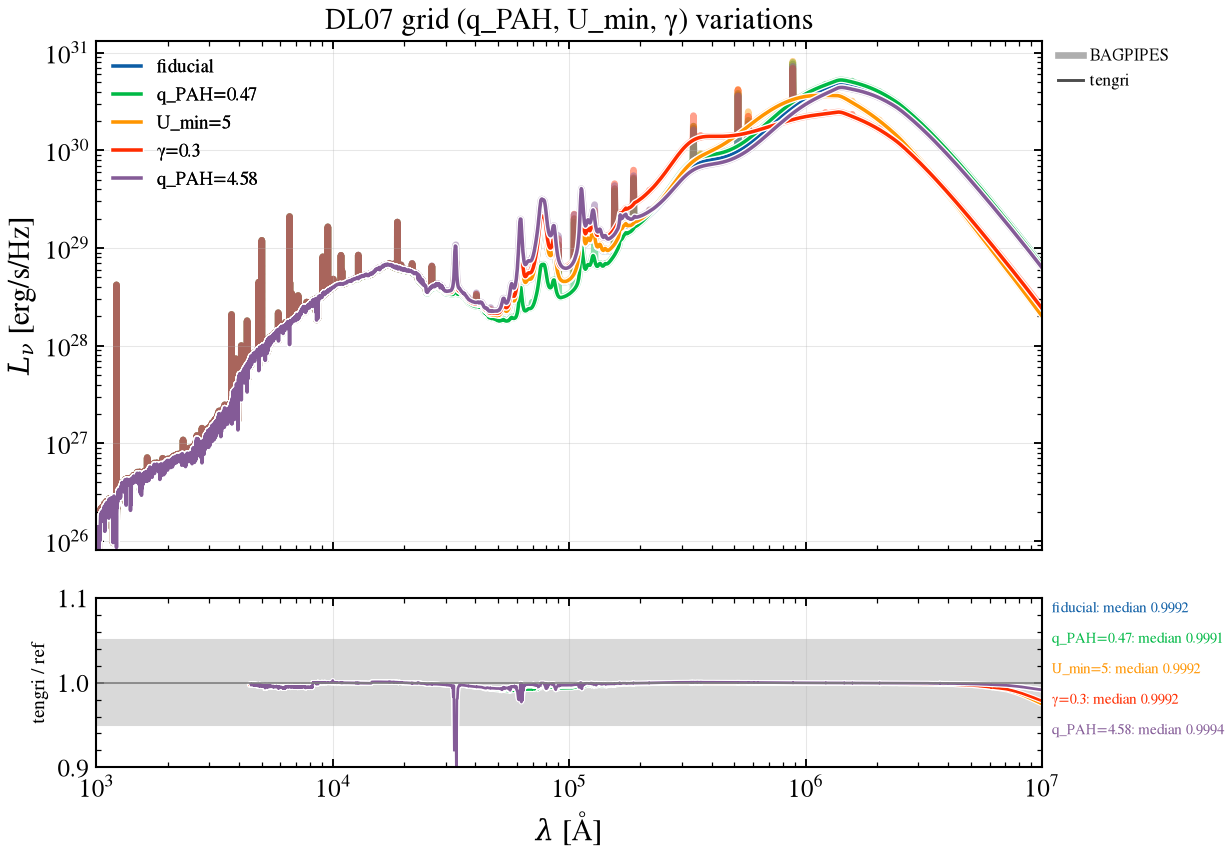

In [19]:
dl07_cases = [
    ("fiducial", QPAH_FIDUCIAL, UMIN_FIDUCIAL, GAMMA_FIDUCIAL),
    ("q_PAH=0.47", 0.47, UMIN_FIDUCIAL, GAMMA_FIDUCIAL),
    ("U_min=5", QPAH_FIDUCIAL, 5.0, GAMMA_FIDUCIAL),
    ("γ=0.3", QPAH_FIDUCIAL, UMIN_FIDUCIAL, 0.3),
    ("q_PAH=4.58", 4.58, UMIN_FIDUCIAL, GAMMA_FIDUCIAL),
]

cases_dl07 = []
for label, qpah, umin, gamma in dl07_cases:
    comp_b_dl = {
        "redshift": 0.0,
        "delayed": {
            "metallicity": 1.0,
            "age": AGE_GYR_FIDUCIAL,
            "tau": TAU_GYR_FIDUCIAL,
            "massformed": LOG_MASS_FIDUCIAL,
        },
        "dust": {
            "type": "Calzetti",
            "Av": AV_FIDUCIAL,
            "eta": 1.0,
            "qpah": qpah,
            "umin": umin,
            "gamma": gamma,
        },
        "nebular": {"logU": -2.0},
    }
    mg_b_dl = B._build_model(comp_b_dl)
    w_b_dl, L_b_dl = B.to_lnu(mg_b_dl)

    m_dl = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "type": "two_component",
            "law_bc": "calzetti",
            "law_diff": "calzetti",
            "tau_bc": Fixed(TAU_BC),
            "tau_diff": Fixed(TAU_DIFF),
            "all_params": Fixed(DEFAULT),
        },
        dust_emission={
            "type": "draine_li2007",
            "qpah": Fixed(qpah),
            "umin": Fixed(umin),
            "gamma_dl": Fixed(gamma),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    s_dl = m_dl.predict_state({})
    sed_full_t_dl = s_dl.derived["sed_dust_attenuated"] + s_dl.derived["sed_dust_ir"]

    L_ir_t = float(np.asarray(s_dl.derived["L_ir"]))
    L_abs_t = float(np.asarray(s_dl.derived["L_absorbed"]))
    eb_resid_dl = abs(L_ir_t - L_abs_t) / max(L_abs_t, 1e-30)

    print(
        f"§8 {label}: L_IR/L_abs = {L_ir_t / max(L_abs_t, 1e-30):.3f}, "
        f"EB resid = {eb_resid_dl:.1e}"
    )

    _assert_comparable(L_b_dl, sed_full_t_dl, name=f"§8 {label}")
    cases_dl07.append((label, w_b_dl, L_b_dl, s_dl.wave, sed_full_t_dl))

fig, (ax, ax_r), ratios = V.sweep_fig(
    cases_dl07,
    ref_label="BAGPIPES",
    title="DL07 grid (q_PAH, U_min, γ) variations",
    xlim=(1e3, 1e7),
    ratio_ylim=(0.9, 1.1),
    band=(0.95, 1.05),
    ref_style="line",
    fixed_ratio_ylim=True,
    annotate_median=True,
    mask_lines_aa=LINE_MASK_AA,
)
fig.tight_layout()
save_fig("bagpipes_11_dl07_grid.png")

# IR-band ratios for every case (3.4-863 µm), worst band named.
_dl_rows = {}
for _lab, _wb, _Lb, _wt, _Lt in cases_dl07:
    _dl_rows[_lab] = V.filter_rows_native(_wt, np.asarray(_Lt), _wb, _Lb, filters=V.IR_BANDS, integrate="sed")
    V.print_filter_table(
        _dl_rows[_lab], ref_name="BAGPIPES", title=f"§8 {_lab}", compact=True, show_worst_band=True
    )
_dl_worst_case = max(
    _dl_rows, key=lambda k: max(abs(r[4] - 1.0) for r in _dl_rows[k] if np.isfinite(r[4]))
)
_dl_dev = max(abs(r[4] - 1.0) for r in _dl_rows[_dl_worst_case] if np.isfinite(r[4]))
print(f"§8 worst case of the DL07 sweep: {_dl_worst_case}")
RESULTS["§8 dust emission"] = (f"worst IR band over the DL07 sweep ({_dl_worst_case})", _dl_dev)

### Energy balance inputs

Absorbed luminosity $L_{\rm abs} = \int (L_{\rm in} - L_{\rm att})\,d\lambda$ in erg/s. BAGPIPES integrates
over its whole grid, including $\lambda < 912$ Å, and counts nebular emission in $L_{\rm in}$ when the
block is present. tengri excludes $\lambda < 912$ Å by default; `eb_include_lyc=True` includes it.

In [20]:
_DL07_DUST = {"type": "Calzetti", "Av": AV_FIDUCIAL, "eta": 1.0, "qpah": QPAH_FIDUCIAL,
              "umin": UMIN_FIDUCIAL, "gamma": GAMMA_FIDUCIAL}
_DL07_SFH_B = {"metallicity": 1.0, "age": AGE_GYR_FIDUCIAL, "tau": TAU_GYR_FIDUCIAL,
               "massformed": LOG_MASS_FIDUCIAL}


def _l_abs_tengri(*, neb: bool, include_lyc: bool) -> float:
    """tengri absorbed luminosity [erg/s] for the §8 DL07 fiducial."""
    dust_att = {
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    }
    if include_lyc:
        dust_att["eb_include_lyc"] = True
    groups = dict(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation=dust_att,
        dust_emission={
            "type": "draine_li2007",
            "qpah": Fixed(QPAH_FIDUCIAL),
            "umin": Fixed(UMIN_FIDUCIAL),
            "gamma_dl": Fixed(GAMMA_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    if neb:
        groups["neb"] = {
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        }
    return float(np.asarray(SEDModel.build(**groups).predict_state({}).derived["L_absorbed"]))


def _l_abs_bagpipes(*, neb: bool) -> float:
    comp = {"redshift": 0.0, "delayed": _DL07_SFH_B, "dust": _DL07_DUST}
    if neb:
        comp["nebular"] = {"logU": -2.0}
    return B.absorbed_luminosity(comp)


_eb_rows = [
    ("nebular off in both; tengri default (λ ≥ 912 Å)", False, False),
    ("nebular off in both; tengri eb_include_lyc=True", False, True),
    ("nebular on in both; tengri default (λ ≥ 912 Å)", True, False),
]
_L_ABS_RATIOS = {}
print(f"{'§8 energy balance, L_abs [erg/s]':54s} {'tengri':>11s} {'BAGPIPES':>11s} {'t/B':>7s}")
for _label, _neb, _lyc in _eb_rows:
    _lt, _lb = _l_abs_tengri(neb=_neb, include_lyc=_lyc), _l_abs_bagpipes(neb=_neb)
    _L_ABS_RATIOS[_label] = _lt / _lb
    print(f"  {_label:52s} {_lt:11.4e} {_lb:11.4e} {_lt / _lb:7.4f}")
_lab_off, _lab_lyc, _lab_on = (r[0] for r in _eb_rows)
RESULTS["§8 energy balance (L_abs)"] = ("L_abs, nebular off, default", abs(_L_ABS_RATIOS[_lab_off] - 1.0))
caveat(
    f"tengri excludes $\\lambda < 912$ Å from the absorbed luminosity by default, and BAGPIPES does not. With the nebular "
    f"block off in both codes tengri's $L_{{\\rm abs}}$, and so its IR luminosity, is {_L_ABS_RATIOS[_lab_off]:.4f} of "
    f"BAGPIPES's; with `eb_include_lyc=True` it is {_L_ABS_RATIOS[_lab_lyc]:.4f}. With the nebular block on in both, "
    f"the ionizing light is reprocessed into lines and the ratio is {_L_ABS_RATIOS[_lab_on]:.4f} at the default. "
    f"The IR shape is unaffected (§8 ladders); a stellar-only BAGPIPES model compared in IR luminosity needs the "
    f"keyword."
)

§8 energy balance, L_abs [erg/s]                            tengri    BAGPIPES     t/B


  nebular off in both; tengri default (λ ≥ 912 Å)       2.0471e+43  2.2728e+43  0.9007


  nebular off in both; tengri eb_include_lyc=True       2.2807e+43  2.2728e+43  1.0035


  nebular on in both; tengri default (λ ≥ 912 Å)        2.1968e+43  2.1981e+43  0.9994


**Caveat:** tengri excludes $\lambda < 912$ Å from the absorbed luminosity by default, and BAGPIPES does not. With the nebular block off in both codes tengri's $L_{\rm abs}$, and so its IR luminosity, is 0.9007 of BAGPIPES's; with `eb_include_lyc=True` it is 1.0035. With the nebular block on in both, the ionizing light is reprocessed into lines and the ratio is 0.9994 at the default. The IR shape is unaffected (§8 ladders); a stellar-only BAGPIPES model compared in IR luminosity needs the keyword.

## §9 Nebular emission

BAGPIPES reads Cloudy v25 grids indexed by $(\log U, Z)$; tengri uses Cue trained on Cloudy 22.00
(Li et al. 2025). Line luminosities are taken from each code's own line table (BAGPIPES
`line_fluxes`, tengri `derived["line_lums"]`), so they depend on neither wavelength grid nor line
width. The fiducial is a 10 Myr constant-SFR population, where the lines dominate; the Balmer decrement
is pinned by case B, which makes it a check on the ionizing continuum.

In [21]:
# Young 10 Myr constant-SFR fiducial — the regime where nebular
# lines dominate. Otherwise the Hα signal is buried under the
# evolved stellar continuum.
NEB_AGE = 0.01  # Gyr

# The overlay figure and the continuum windows below need BAGPIPES's spectrum at 1 Å
# pitch through the optical, so this section builds with an explicit `spec_wavs`.
_neb_spec_wavs = np.arange(900.0, 7000.0, 1.0)

comp_b_neb_on = {
    "redshift": 0.0,
    "constant": {"metallicity": 1.0, "age_min": 0.0, "age_max": NEB_AGE, "massformed": 9.0},
    "nebular": {"logU": -2.0},
}
mg_b_neb_on = B._build_model(comp_b_neb_on, spec_wavs=_neb_spec_wavs)
# At redshift=0 with spec_wavs set, mg.spectrum carries erg/s/Å directly
# (no cosmological dimming applied). Column 0 is wavelength, column 1
# is L_λ.
w_b_neb = mg_b_neb_on.spectrum[:, 0]
L_b_neb_on = mg_b_neb_on.spectrum[:, 1] * w_b_neb**2 / U.C_ANGSTROM_PER_S

comp_b_neb_off = {
    "redshift": 0.0,
    "constant": {"metallicity": 1.0, "age_min": 0.0, "age_max": NEB_AGE, "massformed": 9.0},
}
mg_b_neb_off = B._build_model(comp_b_neb_off, spec_wavs=_neb_spec_wavs)
_L_stellar_only_aa = mg_b_neb_off.spectrum[:, 1]
L_b_stellar_only = _L_stellar_only_aa * w_b_neb**2 / U.C_ANGSTROM_PER_S
L_b_neb_alone = np.clip(L_b_neb_on - L_b_stellar_only, 0.0, None)

m_neb_on = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(NEB_AGE),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(9.0),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_neb_on = m_neb_on.predict_state({})

m_neb_off = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(NEB_AGE),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(9.0),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_neb_off = m_neb_off.predict_state({})
# Cue exposes its emission directly under derived["sed_nebular"];
# avoid subtracting two SEDs on different wave grids.
L_t_neb_alone = np.asarray(s_neb_on.derived["sed_nebular"])

# Line luminosities are read from each code's own line table (BAGPIPES `line_fluxes`,
# tengri `derived["line_lums"]`), so they depend on neither wavelength grid nor line width
# (§10 addresses widths). Each entry lists the line wavelengths in BAGPIPES's air scale and
# tengri's vacuum scale.
_w_t_neb = np.asarray(s_neb_on.wave)
LINE_SETS = {
    "[O II] 3727": ((3726.03, 3728.81), (3727.09, 3729.88)),
    "Hβ": ((4861.32,), (4862.68,)),
    "[O III] 5007": ((5006.84,), (5008.24,)),
    "Hα": ((6562.80,), (6564.61,)),
    "[N II] 6584": ((6583.45,), (6585.27,)),
}
_AIR_TOL, _VAC_TOL = 0.02, 0.6  # Å: match windows on each code's line wavelengths


def line_luminosity_pair(mg_b, state_t, name):
    """(BAGPIPES, tengri) luminosity [erg/s] of one `LINE_SETS` entry from the line tables."""
    air, vac = LINE_SETS[name]
    wb, lb = B.line_table(mg_b)
    wt = np.asarray(state_t.derived["line_waves"])
    lt = np.asarray(state_t.derived["line_lums"])
    return B.sum_lines(wb, lb, air, _AIR_TOL), B.sum_lines(wt, lt, vac, _VAC_TOL)


print("§9 line luminosity from the line tables (tengri Cue, Cloudy 22.00 / BAGPIPES Cloudy v25):")
for _name in LINE_SETS:
    _lb, _lt = line_luminosity_pair(mg_b_neb_on, s_neb_on, _name)
    print(f"    {_name} : BAGPIPES {_lb:.2e}, tengri {_lt:.2e} erg/s → {_lt / _lb:.2f}×")

# Case B pins Hα/Hβ near 2.86 whatever the metallicity or ionization parameter, so the
# decrement is the one number that a mis-scaled SSP cannot fake.
_ha_b, _ha_t = line_luminosity_pair(mg_b_neb_on, s_neb_on, "Hα")
_hb_b, _hb_t = line_luminosity_pair(mg_b_neb_on, s_neb_on, "Hβ")
print(
    f"    Balmer decrement Hα/Hβ: BAGPIPES {_ha_b / _hb_b:.2f}, "
    f"tengri {_ha_t / _hb_t:.2f}   (Case B ≈ 2.86)"
)

# Lines are not the whole nebular block: the free-free / free-bound / two-photon
# continuum rides underneath, and being smooth it is what a broadband filter
# integrates most of. Sample it in windows that are line-free in both codes, so
# §13's photometric residual can be attributed rather than assumed.
print("§9 nebular continuum (line-free windows), tengri / BAGPIPES:")
for _lo, _hi in [(3000.0, 3600.0), (4000.0, 4300.0), (5500.0, 6300.0)]:
    _mb = (w_b_neb >= _lo) & (w_b_neb <= _hi)
    _mt = (_w_t_neb >= _lo) & (_w_t_neb <= _hi)
    if _mb.sum() < 3 or _mt.sum() < 3:
        continue
    # The 20th percentile sits below the lines but on the continuum.
    _cb = float(np.percentile(L_b_neb_alone[_mb], 20))
    _ct = float(np.percentile(L_t_neb_alone[_mt], 20))
    if _cb > 0:
        print(f"    {_lo:.0f}–{_hi:.0f} Å: {_ct / _cb:.2f}×")

§9 line luminosity from the line tables (tengri Cue, Cloudy 22.00 / BAGPIPES Cloudy v25):
    [O II] 3727 : BAGPIPES 1.39e+43, tengri 1.07e+43 erg/s → 0.77×
    Hβ : BAGPIPES 9.81e+42, tengri 9.64e+42 erg/s → 0.98×
    [O III] 5007 : BAGPIPES 2.62e+43, tengri 2.65e+43 erg/s → 1.01×
    Hα : BAGPIPES 2.77e+43, tengri 2.72e+43 erg/s → 0.98×
    [N II] 6584 : BAGPIPES 3.77e+42, tengri 3.09e+42 erg/s → 0.82×
    Balmer decrement Hα/Hβ: BAGPIPES 2.82, tengri 2.82   (Case B ≈ 2.86)
§9 nebular continuum (line-free windows), tengri / BAGPIPES:
    3000–3600 Å: 0.98×
    4000–4300 Å: 0.97×
    5500–6300 Å: 0.98×


### Line ratios across $\log U$, $Z$ and $f_{\rm esc}$

The dot chart shows tengri over BAGPIPES for the twenty strongest BAGPIPES lines in six cases. Stars
are requested at the same absolute $Z$ and gas is solar-scaled, `neb_logZ_gas` $= \log_{10} z$, against
BAGPIPES's `metallicity` $= z$ (shared Dopita et al. 2000 scale). Cue's [N/O] is set to BAGPIPES's value at
that metallicity.

In [22]:
neb_cases_list = [
    # logU sweep at Z=1 Z☉, f_esc=0
    ("logU=-3.0", -3.0, 1.0, 0.0),
    ("logU=-2.0", -2.0, 1.0, 0.0),
    ("logU=-1.5", -1.5, 1.0, 0.0),
    # Z_gas sweep at logU=-2, f_esc=0
    ("Z=0.3 Z☉", -2.0, 0.3, 0.0),
    ("Z=2 Z☉", -2.0, 2.0, 0.0),
    # f_esc sweep at logU=-2, Z=1 Z☉
    ("f_esc=0.5", -2.0, 1.0, 0.5),
]

from tengri.components.nebular.cue import CUE_TRAINED_LOG_NO


def bagpipes_log_no(z):
    """[N/O] [dex] of BAGPIPES's Cloudy grid at gas metallicity z (solar units), clipped to Cue's trained range.

    `make_cloudy_models.py` sets N/H = -3.94 + 2 log10 z for log10 z > -0.63 ([N/O] = log10 z) and
    N/H = -4.57 + log10 z below ([N/O] = -0.63); oxygen scales with z.
    """
    log_z = float(np.log10(z))
    log_no = log_z if log_z > -0.63 else -0.63
    return float(np.clip(log_no, *CUE_TRAINED_LOG_NO))


def neb_case_models(z, logu, fesc, *, match_nitrogen=True):
    """BAGPIPES model and tengri state for the 10 Myr fiducial at gas/stellar Z = z (in solar units).

    BAGPIPES takes `metallicity = z` for stars and gas; tengri requests the same absolute
    stellar Z, the solar-scaled gas metallicity `neb_logZ_gas = log10(z)` and, unless
    `match_nitrogen` is False, BAGPIPES's [N/O] at that metallicity as `gas_logno`.
    """
    mg = B._build_model(
        {
            "redshift": 0.0,
            "constant": {"metallicity": z, "age_min": 0.0, "age_max": NEB_AGE, "massformed": 9.0},
            "nebular": {"logU": logu, "fesc": fesc, "metallicity": z},
        }
    )
    logz_stellar = float(np.log10(z * Z_SUN_BAGPIPES) - LOG10_ZSUN)
    m = SEDModel.build(
        ssp_data=ssp,
        met={"logzsol": Fixed(logz_stellar), **MET_NODE},
        sfh={
            "type": "const",
            "start_gyr": Fixed(NEB_AGE),
            "end_gyr": Fixed(0.0),
            "log_total_mass": Fixed(9.0),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(logu),
            "neb_logZ_gas": Fixed(float(np.log10(z))),
            "neb_fesc": Fixed(fesc),
            **({"gas_logno": Fixed(bagpipes_log_no(z))} if match_nitrogen else {}),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    return mg, m.predict_state({})


print("§9 line-table luminosity ratios (tengri Cue / BAGPIPES Cloudy v25):")
NEB_CASE_RATIOS = {}
NEB_CASE_MODELS = {}
for label, logu, z, fesc in neb_cases_list:
    mg_case, s_case = neb_case_models(z, logu, fesc)
    NEB_CASE_MODELS[label] = (mg_case, s_case)
    print(f"  {label}:")
    for name in ("Hα", "Hβ", "[O III] 5007", "[O II] 3727", "[N II] 6584"):
        lb, lt = line_luminosity_pair(mg_case, s_case, name)
        NEB_CASE_RATIOS[(label, name)] = lt / lb
        print(f"    {name:>12s}: {lt / lb:.2f}×")

_nii_default = line_luminosity_pair(*neb_case_models(0.3, -2.0, 0.0, match_nitrogen=False), "[N II] 6584")
_nii_matched = NEB_CASE_RATIOS[("Z=0.3 Z☉", "[N II] 6584")]
_nii_default_ratio = _nii_default[1] / _nii_default[0]
_nii_solar = NEB_CASE_RATIOS[("logU=-2.0", "[N II] 6584")]
print(
    f"§9 [N II] 6584 tengri/BAGPIPES at Z = 0.3 Z☉: default gas_logno = 0 {_nii_default_ratio:.3f}; matched gas_logno = "
    f"{bagpipes_log_no(0.3):.3f} {_nii_matched:.3f}; at Z = 1 Z☉ (gas_logno = {bagpipes_log_no(1.0):g}) {_nii_solar:.3f}"
)
RESULTS["§9 [N II] 6584 (Z = 0.3 Z☉, matched [N/O])"] = ("line-table luminosity", abs(_nii_matched - 1.0))
caveat(
    f"BAGPIPES's Cloudy grid sets nitrogen as [N/O] $= \\log_{{10}} z$ above $0.23\\,Z_\\odot$ and a constant $-0.63$ below "
    f"(`make_cloudy_models.py`), while Cue takes [N/O] as an input (`gas_logno`, default 0, the solar ratio at every "
    f"metallicity). At $Z = 0.3\\,Z_\\odot$ the tengri/BAGPIPES ratio of [N II] 6584 is {_nii_default_ratio:.3f} with the default and "
    f"{_nii_matched:.3f} with `gas_logno` $= {bagpipes_log_no(0.3):.3f}$, which every case on this page uses. The matched "
    f"value is not within 10 % of 1 ({_nii_solar:.3f} at $Z = 1\\,Z_\\odot$ with the same [N/O] in both codes), and the page does "
    f"not isolate why. A BAGPIPES setup below solar metallicity needs `gas_logno` set from this relation in tengri."
)

§9 line-table luminosity ratios (tengri Cue / BAGPIPES Cloudy v25):


  logU=-3.0:
              Hα: 0.97×
              Hβ: 0.97×
    [O III] 5007: 1.09×
     [O II] 3727: 0.86×
     [N II] 6584: 0.88×


  logU=-2.0:
              Hα: 0.98×
              Hβ: 0.98×
    [O III] 5007: 1.01×
     [O II] 3727: 0.77×
     [N II] 6584: 0.82×


  logU=-1.5:
              Hα: 0.98×
              Hβ: 0.98×
    [O III] 5007: 1.02×
     [O II] 3727: 0.72×
     [N II] 6584: 0.78×


  Z=0.3 Z☉:
              Hα: 0.97×
              Hβ: 0.97×
    [O III] 5007: 1.02×
     [O II] 3727: 0.89×
     [N II] 6584: 0.77×


  Z=2 Z☉:
              Hα: 1.86×
              Hβ: 1.82×
    [O III] 5007: 0.16×
     [O II] 3727: 0.96×
     [N II] 6584: 4.06×


  f_esc=0.5:
              Hα: 0.75×
              Hβ: 0.76×
    [O III] 5007: 0.78×
     [O II] 3727: 0.59×
     [N II] 6584: 0.63×


§9 [N II] 6584 tengri/BAGPIPES at Z = 0.3 Z☉: default gas_logno = 0 2.562; matched gas_logno = -0.523 0.775; at Z = 1 Z☉ (gas_logno = 0) 0.821


**Caveat:** BAGPIPES's Cloudy grid sets nitrogen as [N/O] $= \log_{10} z$ above $0.23\,Z_\odot$ and a constant $-0.63$ below (`make_cloudy_models.py`), while Cue takes [N/O] as an input (`gas_logno`, default 0, the solar ratio at every metallicity). At $Z = 0.3\,Z_\odot$ the tengri/BAGPIPES ratio of [N II] 6584 is 2.562 with the default and 0.775 with `gas_logno` $= -0.523$, which every case on this page uses. The matched value is not within 10 % of 1 (0.821 at $Z = 1\,Z_\odot$ with the same [N/O] in both codes), and the page does not isolate why. A BAGPIPES setup below solar metallicity needs `gas_logno` set from this relation in tengri.

§9 He I 3888.64 / H I 3889.05 (BAGPIPES air wavelengths), each tengri line against its own counterpart, tengri/BAGPIPES:
    logU=-3.0  He I 0.978   H I 0.968
    logU=-2.0  He I 0.984   H I 0.976
    logU=-1.5  He I 0.977   H I 0.976
    Z=0.3 Z☉   He I 0.990   H I 0.972
    Z=2 Z☉     He I 1.643   H I 1.758
    f_esc=0.5  He I 0.758   H I 0.751
§9 twenty strongest lines at logU = -2, Z = 1 Z☉: median tengri/BAGPIPES 0.973, range 0.767-1.052; weakest agreement O 2 3726.03A


**Caveat:** at $\log U = -2$ and $Z = Z_\odot$ the low-ionization forbidden lines are below BAGPIPES in the line tables (tengri/BAGPIPES: [O II] 3726.03 0.77, 3728.81 0.77; [N II] 6548.05 0.84, 6583.45 0.82; [S II] 6716.44 0.88, 6730.82 0.87), while the recombination lines lie at 0.97-0.98 (the H I lines among the twenty strongest) and [O III] at 4958.91 0.98, 5006.84 1.01. [O II] 3727 is 0.86, 0.77 and 0.72 of BAGPIPES at $\log U = -3, -2, -1.5$, and [N II] 6584 is 0.77 at $Z = 0.3\,Z_\odot$ after the nitrogen abundance is matched. The ionizing photon rate and the definition of $U$ are the same in the two codes. The page does not isolate the cause; line-ratio diagnostics that use these lines inherit the offset.

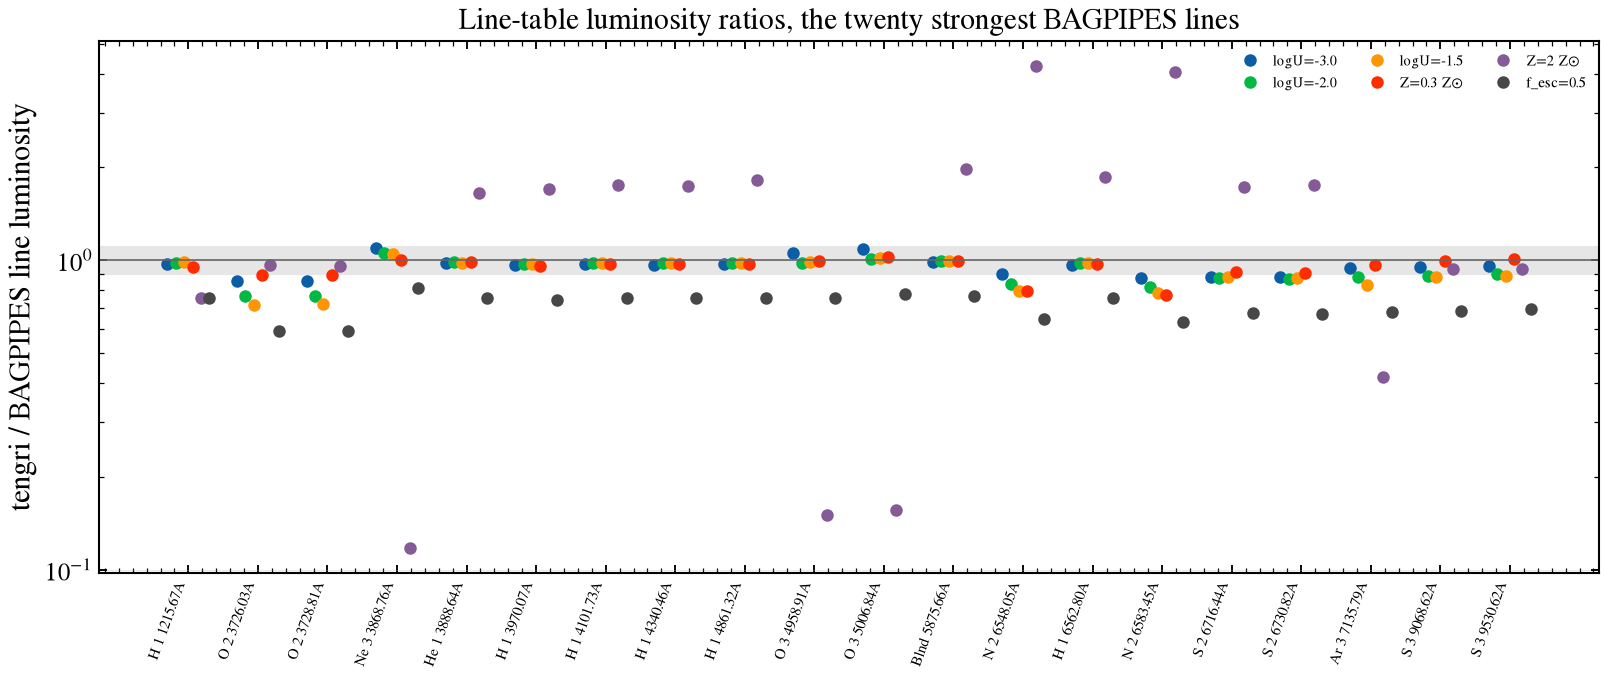

In [23]:


def paired_line_table(mg_b, state_t):
    """(BAGPIPES air wavelength, BAGPIPES L, tengri L) for every BAGPIPES line with a tengri partner."""
    wb, lb = B.line_table(mg_b)
    wt = np.asarray(state_t.derived["line_waves"])
    lt = np.asarray(state_t.derived["line_lums"])
    # BAGPIPES labels the lines below 2000 A in vacuum and above in air.
    wvac = np.where(wb > 2000.0, air_to_vac(wb), wb)
    # Each tengri line is assigned to the nearest BAGPIPES line, so two lines closer than the match window
    # (He I 3888.64 and H I 3889.05 in BAGPIPES's air scale) are compared each with its own counterpart.
    nearest = np.argmin(np.abs(wt[:, None] - wvac[None, :]), axis=1)
    matched = np.abs(wt - wvac[nearest]) < _VAC_TOL
    lum_t = np.bincount(nearest[matched], weights=lt[matched], minlength=wb.size)
    return wb, lb, lum_t


_fid = paired_line_table(*NEB_CASE_MODELS["logU=-2.0"])
_top = np.argsort(_fid[1])[::-1]
_top = [i for i in _top if _fid[2][i] > 0][:20]
_top = sorted(_top, key=lambda i: _fid[0][i])
_names_all = np.asarray(__import__("bagpipes").config.line_names)
_line_labels = [str(_names_all[i]).replace("  ", " ").strip() for i in _top]

fig, ax = plt.subplots(figsize=(11, 4.8))
_x = np.arange(len(_top))
LINE_RATIOS = {}
_LINE_TABLES = {}
for _k, (label, *_rest) in enumerate(neb_cases_list):
    wb_, lb_, lt_ = paired_line_table(*NEB_CASE_MODELS[label])
    _LINE_TABLES[label] = (wb_, lb_, lt_)
    _r = np.array([lt_[i] / lb_[i] if lb_[i] > 0 else np.nan for i in _top])
    LINE_RATIOS[label] = _r
    ax.plot(_x + 0.12 * (_k - 2.5), _r, "o", color=f"C{_k}", markersize=5, label=label)
ax.axhline(1.0, color="0.4", linewidth=0.8)
ax.axhspan(0.9, 1.1, color="0.9", zorder=0)
ax.set_yscale("log")
ax.set_xticks(_x, _line_labels, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("tengri / BAGPIPES line luminosity")
ax.set_title("Line-table luminosity ratios, the twenty strongest BAGPIPES lines")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
save_fig("bagpipes_12_line_ratios.png")
_i_he, _i_h = (int(np.argmin(np.abs(_fid[0] - w))) for w in (3888.64, 3889.05))
print("§9 He I 3888.64 / H I 3889.05 (BAGPIPES air wavelengths), each tengri line against its own counterpart, tengri/BAGPIPES:")
for _label, (_wb, _lb, _lt) in _LINE_TABLES.items():
    print(f"    {_label:10s} He I {_lt[_i_he] / _lb[_i_he]:.3f}   H I {_lt[_i_h] / _lb[_i_h]:.3f}")
_fid_ratio = LINE_RATIOS["logU=-2.0"]
print(
    f"§9 twenty strongest lines at logU = -2, Z = 1 Z☉: median tengri/BAGPIPES {np.nanmedian(_fid_ratio):.3f}, "
    f"range {np.nanmin(_fid_ratio):.3f}-{np.nanmax(_fid_ratio):.3f}; weakest agreement "
    f"{_line_labels[int(np.nanargmax(np.abs(np.log(_fid_ratio))))]}"
)
_o2 = NEB_CASE_RATIOS[("logU=-2.0", "[O II] 3727")]
RESULTS["§9 nebular lines ([O II] 3727, logU = -2)"] = ("line-table luminosity", abs(_o2 - 1.0))
_grp = lambda prefixes: [(l, r) for l, r in zip(_line_labels, _fid_ratio) if l.startswith(prefixes)]
_fmt = lambda pairs: ", ".join(f"{l.split()[-1].rstrip('A')} {r:.2f}" for l, r in pairs)
_low, _rec, _o3 = _grp(("O 2", "N 2", "S 2")), _grp(("H 1",)), _grp(("O 3",))
caveat(
    f"at $\\log U = -2$ and $Z = Z_\\odot$ the low-ionization forbidden lines are below BAGPIPES in the line tables "
    f"(tengri/BAGPIPES: [O II] {_fmt(_grp(('O 2',)))}; [N II] {_fmt(_grp(('N 2',)))}; [S II] {_fmt(_grp(('S 2',)))}), "
    f"while the recombination lines lie at {min(r for _, r in _rec):.2f}-{max(r for _, r in _rec):.2f} (the H I lines among the twenty "
    f"strongest) and [O III] at {_fmt(_o3)}. [O II] 3727 is {NEB_CASE_RATIOS[('logU=-3.0', '[O II] 3727')]:.2f}, {_o2:.2f} and "
    f"{NEB_CASE_RATIOS[('logU=-1.5', '[O II] 3727')]:.2f} of BAGPIPES at $\\log U = -3, -2, -1.5$, and [N II] 6584 is "
    f"{_nii_matched:.2f} at $Z = 0.3\\,Z_\\odot$ after the nitrogen abundance is matched. The ionizing photon rate and the "
    f"definition of $U$ are the same in the two codes. The page does not isolate the cause; line-ratio diagnostics that "
    f"use these lines inherit the offset."
)

### Escape fraction

BAGPIPES scales every line by $(1 - f_{\rm esc})$. tengri scales by the dust-escape factor
$k = (1 - f_{\rm esc})/(1 + 0.597\,f_{\rm esc})$. The table gives each code's line-table H$\alpha$ at
$f_{\rm esc}$ relative to its own $f_{\rm esc} = 0$ value.

In [24]:
_ha_b0, _ha_t0 = line_luminosity_pair(*neb_case_models(1.0, -2.0, 0.0), "Hα")
print(f"{'f_esc':>6s} {'tengri':>9s} {'BAGPIPES':>9s} {'tengri/BAGPIPES':>16s} {'k closed form':>14s} {'1 - f':>7s}")
FESC_TABLE = {}
for _f in (0.25, 0.5, 0.75):
    _hb, _ht = line_luminosity_pair(*neb_case_models(1.0, -2.0, _f), "Hα")
    FESC_TABLE[_f] = (_ht / _ha_t0, _hb / _ha_b0)
    print(
        f"{_f:6.2f} {_ht / _ha_t0:9.4f} {_hb / _ha_b0:9.4f} "
        f"{(_ht / _ha_t0) / (_hb / _ha_b0):16.4f} {(1 - _f) / (1 + 0.597 * _f):14.4f} {1 - _f:7.2f}"
    )
_f50 = FESC_TABLE[0.5]
caveat(
    f"at $f_{{\\rm esc}} = 0.5$ tengri's lines are scaled by {_f50[0]:.4f} and BAGPIPES's by {_f50[1]:.4f}, "
    f"so tengri's lines are {_f50[0] / _f50[1]:.3f} of BAGPIPES's ({FESC_TABLE[0.25][0] / FESC_TABLE[0.25][1]:.3f} at 0.25, "
    f"{FESC_TABLE[0.75][0] / FESC_TABLE[0.75][1]:.3f} at 0.75). The factor is common to all lines, and tengri's "
    f"follows the closed form shown in the last column. A BAGPIPES `fesc` is a tengri `neb_fesc` that gives "
    f"$k = 1 - f$ only at $f_{{\\rm esc}} = 0$."
)
RESULTS["§9 escape fraction (f_esc = 0.5)"] = ("line scaling", abs(_f50[0] / _f50[1] - 1.0))

 f_esc    tengri  BAGPIPES  tengri/BAGPIPES  k closed form   1 - f


  0.25    0.6526    0.7500           0.8702         0.6526    0.75


  0.50    0.3851    0.5000           0.7701         0.3851    0.50


  0.75    0.1727    0.2500           0.6908         0.1727    0.25


**Caveat:** at $f_{\rm esc} = 0.5$ tengri's lines are scaled by 0.3851 and BAGPIPES's by 0.5000, so tengri's lines are 0.770 of BAGPIPES's (0.870 at 0.25, 0.691 at 0.75). The factor is common to all lines, and tengri's follows the closed form shown in the last column. A BAGPIPES `fesc` is a tengri `neb_fesc` that gives $k = 1 - f$ only at $f_{\rm esc} = 0$.

### H$\alpha$ per ionizing photon versus metallicity

For an ionization-bounded nebula without dust, case B at $T = 10^4$ K gives
$L(\mathrm{H}\alpha) = 1.37\times10^{-12}\,Q_{\rm H}$ erg/s, with $Q_{\rm H}$ [photons/s] the stellar
ionizing rate. The figure shows each code's line-table H$\alpha$ in units of that value at $\log U = -2$,
$f_{\rm esc} = 0$, with $Q_{\rm H}$ from each code's own stars.

§9 Hα per case-B ionizing photon, BAGPIPES / tengri:
    Z =  0.20 Z☉: 0.985 / 0.964
    Z =  0.40 Z☉: 0.993 / 0.973
    Z =  0.75 Z☉: 1.008 / 1.024
    Z =  1.00 Z☉: 1.021 / 1.000
    Z =  1.50 Z☉: 0.795 / 0.933
    Z =  2.00 Z☉: 0.542 / 1.070
    Z =  2.50 Z☉: 0.257 / 1.047


**Caveat:** H$\alpha$ per case-B ionizing photon, as a fraction of the case-B value: BAGPIPES 1.021 at 1 Z☉, 0.542 at 2 Z☉ and 0.257 at its 2.5 Z☉ node; tengri 1.000, 1.070 and 1.047. The cell does not isolate a cause for the BAGPIPES drop, so the line ratios at Z = 2 Z☉ in the cases above follow BAGPIPES's H$\alpha$-per-photon drop and are listed as printed.

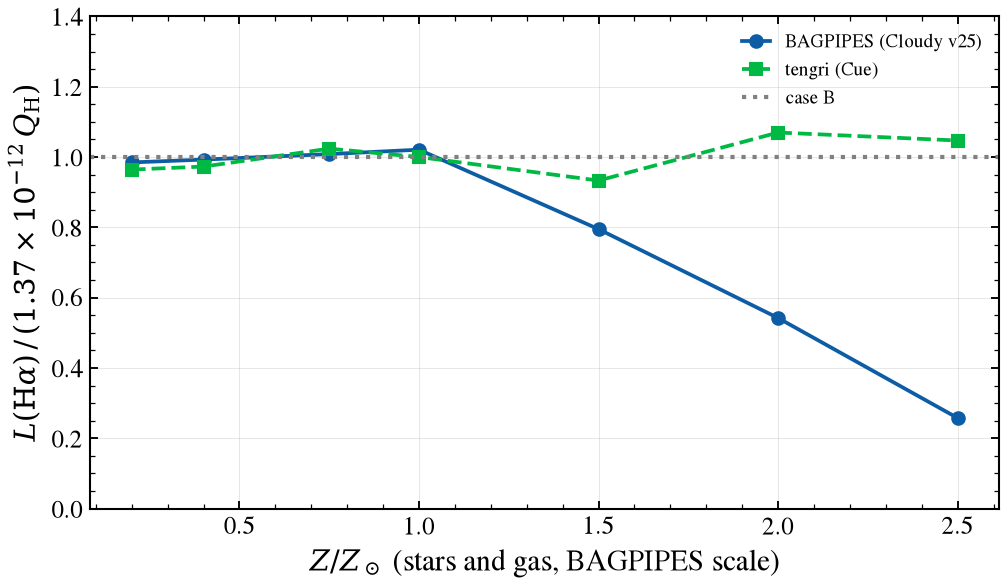

In [25]:
HC_ERG_AA = 6.62607015e-27 * 2.99792458e10 * 1e8  # h c [erg Å]
CASE_B_HALPHA_ERG = 1.37e-12  # erg per ionizing photon


def bagpipes_q_h(z):
    """Ionizing photon rate [1/s] of BAGPIPES's 10 Myr stars at Z = z (solar units)."""
    mg_s = B._build_model(
        {
            "redshift": 0.0,
            "constant": {"metallicity": z, "age_min": 0.0, "age_max": NEB_AGE, "massformed": 9.0},
        }
    )
    w = np.asarray(mg_s.wavelengths)
    keep = w < 911.76
    return float(np.trapezoid(np.asarray(mg_s.spectrum_full)[keep] * w[keep] / HC_ERG_AA, w[keep]))


Z_FIGURE = [0.2, 0.4, 0.75, 1.0, 1.5, 2.0, 2.5]
ha_per_q = {"BAGPIPES": [], "tengri": []}
for _z in Z_FIGURE:
    _mg_z, _s_z = neb_case_models(_z, -2.0, 0.0)
    _hb, _ht = line_luminosity_pair(_mg_z, _s_z, "Hα")
    ha_per_q["BAGPIPES"].append(_hb / (CASE_B_HALPHA_ERG * bagpipes_q_h(_z)))
    ha_per_q["tengri"].append(_ht / (CASE_B_HALPHA_ERG * 10.0 ** float(_s_z.derived["log_nion"])))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(Z_FIGURE, ha_per_q["BAGPIPES"], "C0o-", linewidth=1.8, label="BAGPIPES (Cloudy v25)")
ax.plot(Z_FIGURE, ha_per_q["tengri"], "C1s--", linewidth=1.8, label="tengri (Cue)")
ax.axhline(1.0, color="0.5", linestyle=":", label="case B")
ax.set_xlabel(r"$Z / Z_\odot$ (stars and gas, BAGPIPES scale)")
ax.set_ylabel(r"$L({\rm H}\alpha)\,/\,(1.37\times10^{-12}\,Q_{\rm H})$")
ax.set_ylim(0, 1.4)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
save_fig("bagpipes_13_halpha_per_photon.png")
print("§9 Hα per case-B ionizing photon, BAGPIPES / tengri:")
for _z, _hb, _ht in zip(Z_FIGURE, ha_per_q["BAGPIPES"], ha_per_q["tengri"]):
    print(f"    Z = {_z:5.2f} Z☉: {_hb:.3f} / {_ht:.3f}")
_i2 = Z_FIGURE.index(2.0)
_i25 = Z_FIGURE.index(2.5)
RESULTS["§9 H-alpha per photon (Z = 2.5 Z☉)"] = ("BAGPIPES vs case B", abs(ha_per_q["BAGPIPES"][_i25] - 1.0))
_hq = lambda code, z: ha_per_q[code][Z_FIGURE.index(z)]
caveat(
    f"H$\\alpha$ per case-B ionizing photon, as a fraction of the case-B value: BAGPIPES {_hq('BAGPIPES', 1.0):.3f} at 1 Z☉, "
    f"{_hq('BAGPIPES', 2.0):.3f} at 2 Z☉ and {_hq('BAGPIPES', 2.5):.3f} at its 2.5 Z☉ node; tengri "
    f"{_hq('tengri', 1.0):.3f}, {_hq('tengri', 2.0):.3f} and {_hq('tengri', 2.5):.3f}. The cell does not isolate a "
    f"cause for the BAGPIPES drop, so the line ratios at Z = 2 Z☉ in the cases above follow BAGPIPES's H$\\alpha$-per-photon "
    f"drop and are listed as printed."
)

## §10 Line widths

BAGPIPES applies Gaussian velocity broadening, `veldisp`, by convolving on its model grid with a kernel
of $\sigma_v / v_{\rm pix}$ pixels; tengri's `velocity_broaden` convolves in $\log\lambda$. At
$\sigma_v = 150$ km/s the kernel alone has FWHM $2.355\,\sigma_v \lambda/c$ at H$\alpha$. Each code's nebular
line has no width of its own, while tengri's lines carry `neb_eline_sigma_kms` (default 100 km/s), so the
matched tengri model sets it to 0. The cell fits a Gaussian to the H$\alpha$ profile on each code's own grid,
prints the pixel size, and also gives tengri at its default width with the quadrature expectation.

§10 kernel FWHM at σ_v = 150 km/s: 7.732 Å
§10 Hα FWHM, BAGPIPES: 8.032 Å (model pixel 3.282 Å, output grid 0.500 Å)
§10 Hα FWHM from three Gaussians of one width (Hα and [N II] 6550, 6585) on the nebular profile of each code; tengri's `sed_nebular` matches its nebular-on minus nebular-off spectrum to 2.8e-04 of the peak
§10 Hα FWHM, tengri with neb_eline_sigma_kms = 0: 7.786 Å (native grid pixel 0.900 Å, resampled log-λ grid pixel 0.078 Å)
§10 Hα FWHM, tengri at the default 100 km/s: 9.407 Å; line FWHM 5.155 Å, quadrature sum with the kernel 9.293 Å
§10 relative to the kernel: BAGPIPES +0.039, tengri at 0 +0.007; tengri at the default relative to the quadrature sum +0.012


**Caveat:** with the line width set to 0 the fitted Hα FWHM is 7.786 Å in tengri (+0.7 % from the 7.732 Å kernel) and 8.032 Å in BAGPIPES (+3.9 %), whose lines sit in single 3.282 Å pixels. At tengri's default of 100 km/s it is 9.407 Å against 9.293 Å for the quadrature sum (+1.2 %). A comparison of line widths between the codes needs `neb_eline_sigma_kms` set to 0 in tengri; BAGPIPES's fitted width carries its pixel.

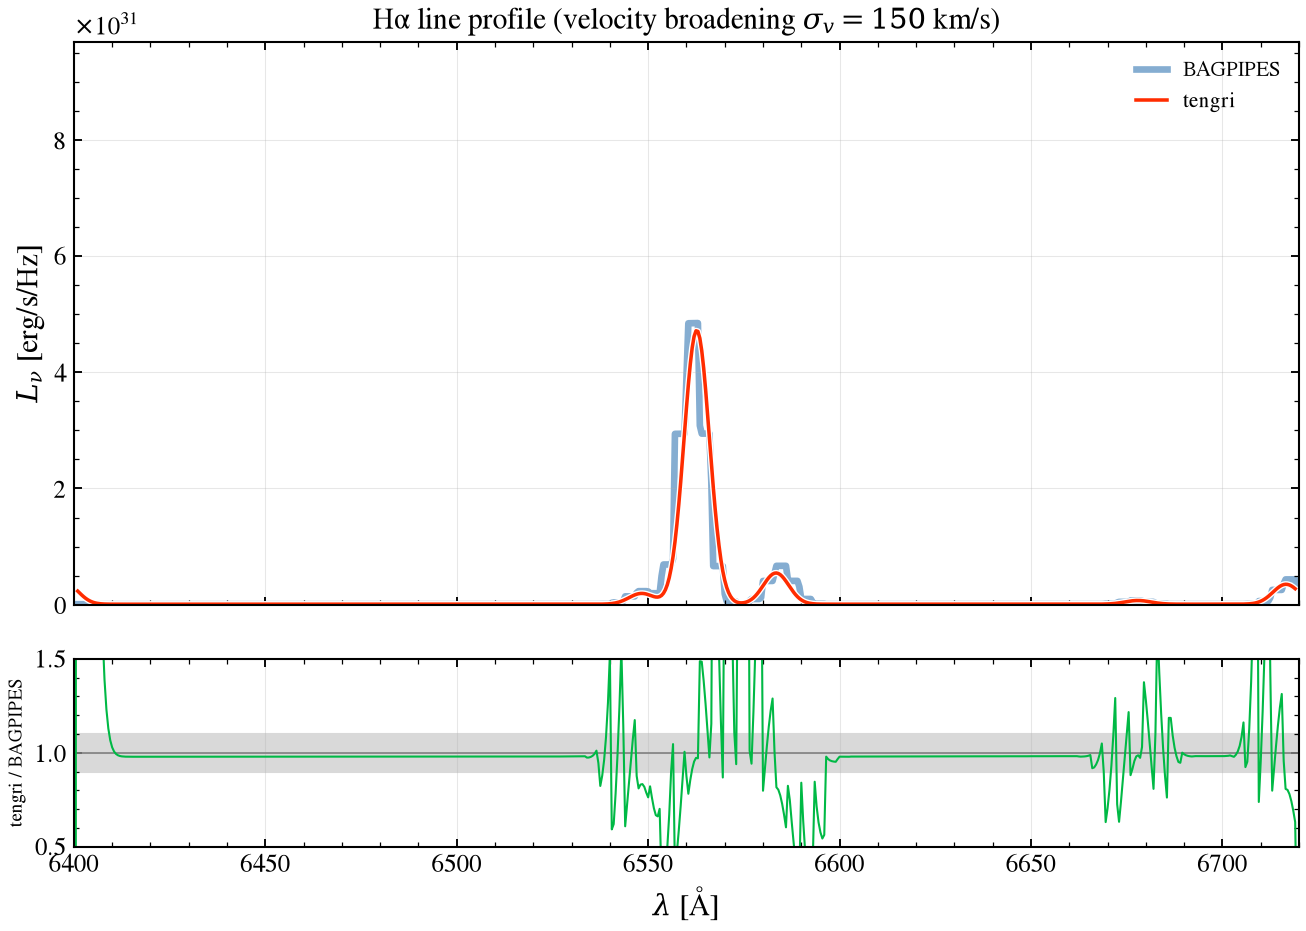

In [26]:
VELDISP_KMS = 150.0
VELDISP_SPEC_WAVS = np.arange(6400.0, 6720.0, 0.5)

# BAGPIPES with veldisp on the same young-CSF fiducial used in §9.
comp_b_lsf = {
    "redshift": 0.0,
    "constant": {"metallicity": 1.0, "age_min": 0.0, "age_max": NEB_AGE, "massformed": 9.0},
    "nebular": {"logU": -2.0},
    "veldisp": VELDISP_KMS,
}
mg_b_lsf = B._build_model(comp_b_lsf, spec_wavs=VELDISP_SPEC_WAVS)
w_b_lsf = mg_b_lsf.spectrum[:, 0]
L_b_lsf_lambda = mg_b_lsf.spectrum[:, 1]  # erg/s/Å at z=0
L_b_lsf = L_b_lsf_lambda * w_b_lsf**2 / U.C_ANGSTROM_PER_S  # erg/s/Hz
# Nebular profile only: subtract the same model without the nebular block (stellar continuum).
_comp_b_cont = {k: v for k, v in comp_b_lsf.items() if k != "nebular"}
_mg_b_cont = B._build_model(_comp_b_cont, spec_wavs=VELDISP_SPEC_WAVS)
L_b_lsf = np.clip(L_b_lsf - _mg_b_cont.spectrum[:, 1] * w_b_lsf**2 / U.C_ANGSTROM_PER_S, 0.0, None)

# BAGPIPES without veldisp — same spectrum, no broadening, for reference.
comp_b_unb = dict(comp_b_lsf)
del comp_b_unb["veldisp"]
mg_b_unb = B._build_model(comp_b_unb, spec_wavs=VELDISP_SPEC_WAVS)
w_b_unb = mg_b_unb.spectrum[:, 0]
L_b_unb = mg_b_unb.spectrum[:, 1] * w_b_unb**2 / U.C_ANGSTROM_PER_S

# tengri side: the §9 fiducial with the nebular line width set to 0 (matched) and at its default, each
# resampled onto a uniform log-wavelength grid over the Hα window and broadened at the same sigma.
from tengri import velocity_broaden as _tng_broaden


def _tengri_broadened_halpha(sigma_line_kms):
    m = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "const",
            "start_gyr": Fixed(NEB_AGE),
            "end_gyr": Fixed(0.0),
            "log_total_mass": Fixed(9.0),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "neb_eline_sigma_kms": Fixed(sigma_line_kms),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    st = m.predict_state({})
    w, L = np.asarray(st.wave), np.asarray(st.derived["sed_nebular"])
    keep = (w >= 6400) & (w <= 6720)
    w_uni = np.geomspace(w[keep][0], w[keep][-1], 4096)  # uniform in log wavelength for the FFT
    return w_uni, np.asarray(_tng_broaden(np.interp(w_uni, w[keep], L[keep]), w_uni, VELDISP_KMS))


_SIG_DEFAULT_KMS = float(m_neb_on.spec.get_distribution("neb_eline_sigma_kms").bounds[0])
_w_t_uni, L_t_lsf = _tengri_broadened_halpha(0.0)
_, L_t_lsf_default = _tengri_broadened_halpha(_SIG_DEFAULT_KMS)

fig, ax, ax_r, _ = V.overlay_ratio_fig(
    w_b_lsf,
    L_b_lsf,
    _w_t_uni,
    L_t_lsf,
    xlabel=r"$\lambda$ [Å]",
    title=rf"Hα line profile (velocity broadening $\sigma_v = {VELDISP_KMS:.0f}$ km/s)",
    ref_label="BAGPIPES",
    label_t="tengri",
    xlim=(6400, 6720),
    ratio_ylim=(0.5, 1.5),
    band=(0.9, 1.1),
    ref_style="line",
)
ax.set_xscale("linear")
ax_r.set_xscale("linear")
ax.set_yscale("linear")
ax.set_ylim(0, None)
fig.tight_layout()
save_fig("bagpipes_14_line_widths.png")


# FWHM from a Gaussian fit to each code's own profile, with the pixel size of each grid.
from scipy.optimize import curve_fit


_HA_NII_CENTERS = (6549.86, 6564.61, 6585.27)  # [N II] 6550, Hα, [N II] 6585 [Å, vacuum]


def _three_gauss(x, a1, a2, a3, shift, sig, c0):
    return sum(a * np.exp(-0.5 * ((x - (c + shift)) / sig) ** 2) for a, c in zip((a1, a2, a3), _HA_NII_CENTERS)) + c0


def _fit_fwhm(wave, spec, center=6565.0, half=30.0):
    """FWHM [Å] of Hα from a fit of three Gaussians of one width (Hα and the two [N II] lines) and a constant."""
    m = np.abs(wave - center) < half
    p0 = (0.1 * spec[m].max(), spec[m].max(), 0.3 * spec[m].max(), 0.0, 3.5, spec[m].min())
    popt, _ = curve_fit(_three_gauss, wave[m], spec[m], p0=p0, maxfev=20000)
    return 2.0 * np.sqrt(2.0 * np.log(2.0)) * abs(popt[4])


_expected_fwhm = 2.0 * np.sqrt(2.0 * np.log(2.0)) * VELDISP_KMS / 2.998e5 * 6563.0
_w_int = np.asarray(mg_b_lsf.wavelengths)
_pix_b = float(np.median(np.diff(_w_int[(_w_int > 6500) & (_w_int < 6630)])))
_w_t_native = np.asarray(s_neb_on.wave)
_pix_t_native = float(np.median(np.diff(_w_t_native[(_w_t_native > 6500) & (_w_t_native < 6630)])))
_pix_t = float(np.median(np.diff(_w_t_uni[(_w_t_uni > 6500) & (_w_t_uni < 6630)])))
# tengri's nebular-off spectrum (on its own grid, which lacks the line nodes) interpolated onto the nebular-on grid
# and subtracted from the nebular-on one, against the published `sed_nebular`.
_on_minus_off = np.asarray(s_neb_on.sed_intrinsic) - np.interp(
    _w_t_native, np.asarray(s_neb_off.wave), np.asarray(s_neb_off.sed_intrinsic)
)
_neb_sub_check = float(
    np.max(np.abs(_on_minus_off - np.asarray(s_neb_on.derived["sed_nebular"]))) / np.max(_on_minus_off)
)
_fw_b = _fit_fwhm(w_b_lsf, L_b_lsf)
_fw_t = _fit_fwhm(_w_t_uni, L_t_lsf)
_fw_t_default = _fit_fwhm(_w_t_uni, L_t_lsf_default)
_line_fwhm_default = 2.0 * np.sqrt(2.0 * np.log(2.0)) * _SIG_DEFAULT_KMS / 2.998e5 * 6563.0
_quad_default = float(np.hypot(_expected_fwhm, _line_fwhm_default))
print(f"§10 kernel FWHM at σ_v = {VELDISP_KMS:g} km/s: {_expected_fwhm:.3f} Å")
print(f"§10 Hα FWHM, BAGPIPES: {_fw_b:.3f} Å (model pixel {_pix_b:.3f} Å, output grid {float(np.median(np.diff(w_b_lsf))):.3f} Å)")
print(
    f"§10 Hα FWHM from three Gaussians of one width (Hα and [N II] 6550, 6585) on the nebular profile of each code; "
    f"tengri's `sed_nebular` matches its nebular-on minus nebular-off spectrum to {_neb_sub_check:.1e} of the peak"
)
print(
    f"§10 Hα FWHM, tengri with neb_eline_sigma_kms = 0: {_fw_t:.3f} Å (native grid pixel {_pix_t_native:.3f} Å, "
    f"resampled log-λ grid pixel {_pix_t:.3f} Å)"
)
print(
    f"§10 Hα FWHM, tengri at the default {_SIG_DEFAULT_KMS:g} km/s: {_fw_t_default:.3f} Å; "
    f"line FWHM {_line_fwhm_default:.3f} Å, quadrature sum with the kernel {_quad_default:.3f} Å"
)
print(
    f"§10 relative to the kernel: BAGPIPES {_fw_b / _expected_fwhm - 1.0:+.3f}, tengri at 0 {_fw_t / _expected_fwhm - 1.0:+.3f}; "
    f"tengri at the default relative to the quadrature sum {_fw_t_default / _quad_default - 1.0:+.3f}"
)
_w10_t = abs(_fw_t / _expected_fwhm - 1.0)
_w10_d = abs(_fw_t_default / _quad_default - 1.0)
RESULTS["§10 line widths"] = ("tengri fitted FWHM at width 0 vs kernel", _w10_t)
caveat(
    f"with the line width set to 0 the fitted Hα FWHM is {_fw_t:.3f} Å in tengri ({(_fw_t / _expected_fwhm - 1.0) * 100:+.1f} % "
    f"from the {_expected_fwhm:.3f} Å kernel) and {_fw_b:.3f} Å in BAGPIPES ({(_fw_b / _expected_fwhm - 1.0) * 100:+.1f} %), whose "
    f"lines sit in single {_pix_b:.3f} Å pixels. At tengri's default of {_SIG_DEFAULT_KMS:g} km/s it is {_fw_t_default:.3f} Å "
    f"against {_quad_default:.3f} Å for the quadrature sum ({(_fw_t_default / _quad_default - 1.0) * 100:+.1f} %). "
    f"A comparison of line widths between the codes needs `neb_eline_sigma_kms` set to 0 in tengri; BAGPIPES's fitted "
    f"width carries its pixel."
)

## §11 IGM transmission

Both codes implement the piecewise Lyman-series and Lyman-continuum opacity of Inoue et al. (2014).
tengri evaluates the formula; BAGPIPES tabulates it on a 1 Å rest-frame grid (`d_igm_grid_inoue14.fits`)
and interpolates linearly. tengri is compared with that table and with BAGPIPES's own generator.

§11 IGM Inoue14 at z=4.0, tengri vs BAGPIPES table: max |Δ| = 5.986e-01 at 1215.70 Å rest (tengri 1.0000, table 0.4014, BAGPIPES generator 1.0000), median |Δ| = 2.671e-08
§11 IGM Inoue14 at z=4.0, tengri vs BAGPIPES generator: max |Δ| = 4.404e-04 at 911.70 Å rest, median |Δ| = 0.000e+00


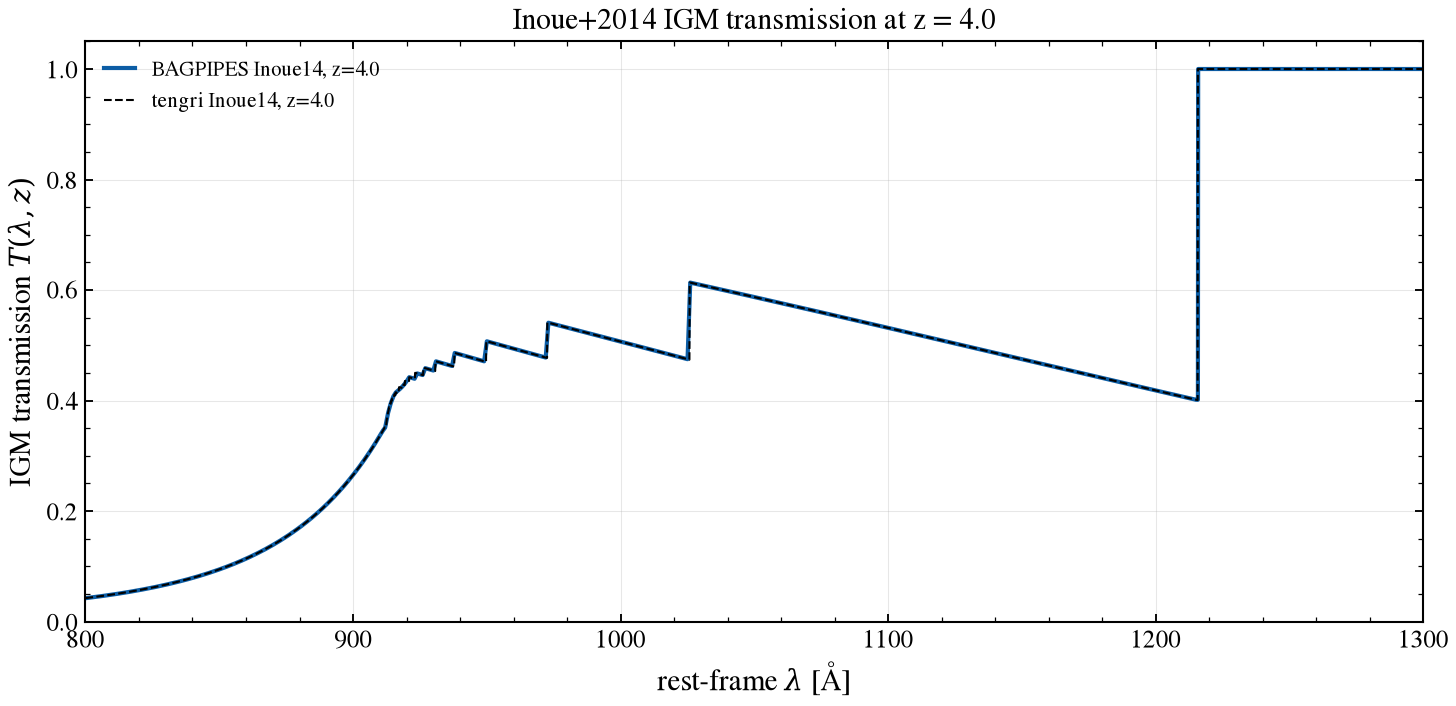

In [27]:
Z_FIDUCIAL_IGM = 4.0
w_b_igm, T_b_igm = B.igm_transmission(Z_FIDUCIAL_IGM)

# tengri side: evaluate igm.inoue14 at z=4 on the same rest-frame grid.
from tengri import igm_transmission as _tngigm

# tengri's IGM is parametrized on *observed*-frame wavelengths.
wave_obs = w_b_igm * (1.0 + Z_FIDUCIAL_IGM)
T_t_igm = np.asarray(_tngigm(wave_obs, np.asarray(Z_FIDUCIAL_IGM)))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(w_b_igm, T_b_igm, "C0-", linewidth=2.0, label=f"BAGPIPES Inoue14, z={Z_FIDUCIAL_IGM}")
ax.plot(w_b_igm, T_t_igm, "k--", linewidth=1.0, label=f"tengri Inoue14, z={Z_FIDUCIAL_IGM}")
ax.set_xlabel(r"rest-frame $\lambda$ [Å]")
ax.set_ylabel(r"IGM transmission $T(\lambda, z)$")
ax.set_xlim(800, 1300)
ax.set_ylim(0, 1.05)
ax.set_title(f"Inoue+2014 IGM transmission at z = {Z_FIDUCIAL_IGM}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("bagpipes_15_igm_z4.png")

# Quantify agreement against BAGPIPES's tabulated transmission and against the generator
# that tabulation is sampled from (`d_igm_grid_inoue14.fits` is that generator on a 1 Å
# rest-frame grid, interpolated linearly in between).
T_a_igm = B.igm_transmission_analytic(w_b_igm, Z_FIDUCIAL_IGM)
_igm_diff = np.abs(T_t_igm - T_b_igm)
_igm_diff_a = np.abs(T_t_igm - T_a_igm)
_i_max = int(np.argmax(_igm_diff))
print(
    f"§11 IGM Inoue14 at z={Z_FIDUCIAL_IGM}, tengri vs BAGPIPES table: "
    f"max |Δ| = {_igm_diff.max():.3e} at {w_b_igm[_i_max]:.2f} Å rest "
    f"(tengri {T_t_igm[_i_max]:.4f}, table {T_b_igm[_i_max]:.4f}, "
    f"BAGPIPES generator {T_a_igm[_i_max]:.4f}), median |Δ| = {np.median(_igm_diff):.3e}"
)
print(
    f"§11 IGM Inoue14 at z={Z_FIDUCIAL_IGM}, tengri vs BAGPIPES generator: "
    f"max |Δ| = {_igm_diff_a.max():.3e} at {w_b_igm[int(np.argmax(_igm_diff_a))]:.2f} Å rest, "
    f"median |Δ| = {np.median(_igm_diff_a):.3e}"
)

### Redshift sweep

$T(\lambda, z)$ for $z \in \{1, 2, 3, 5\}$ against BAGPIPES's table, and the transmission at the pixels
that set the maxima against both the table and the generator.


  §11 — Inoue14 IGM transmission, redshift sweep; deviation as % of unit transmission, 850–1210 Å
  case                           median × max |Δ| [% peak]    x at max [Å]
  --------------------------------------------------------------------------
  z=1                               1.000x            0.8%         1025.70
  z=2                               1.000x            2.5%         1025.70
  z=3                               1.000x            6.1%         1025.70  <-- check
  z=5                               1.000x           11.4%         1025.70  <-- check
§11 transmission at the pixels that carry the maximum |Δ|: tengri / BAGPIPES table / BAGPIPES generator
   z               1025.70 Å (Lyβ edge)              1215.70 Å (Lyα pixel)
   1           0.9574 / 0.9651 / 0.9574           1.0000 / 0.9613 / 1.0000
   2           0.8926 / 0.9178 / 0.8926           1.0000 / 0.8708 / 1.0000


   3           0.7205 / 0.7813 / 0.7205           1.0000 / 0.6702 / 1.0000
   4           0.4740 / 0.5719 / 0.4740           1.0000 / 0.4014 / 1.0000
   5           0.2207 / 0.3349 / 0.2207           1.0000 / 0.1409 / 1.0000


§11 max |Δ| of tengri against the BAGPIPES generator, 800-1300 Å, z = 1-5: 2.20e-03 at z = 1, 911.7 Å rest


**Caveat:** tengri equals BAGPIPES's own Inoue et al. (2014) generator to a maximum of 2.2e-03 over $z = 1$-5 (at 911.7 Å rest, the Lyman-limit pixel). Against BAGPIPES's table the maximum is 0.86, set by two table pixels: the Lyman-$\beta$ edge at 1025.70 Å, where the 1 Å tabulation is interpolated across the step, and the pixel at 1215.70 Å, which BAGPIPES forces to be absorbed. tengri evaluates the formula at the requested wavelength.

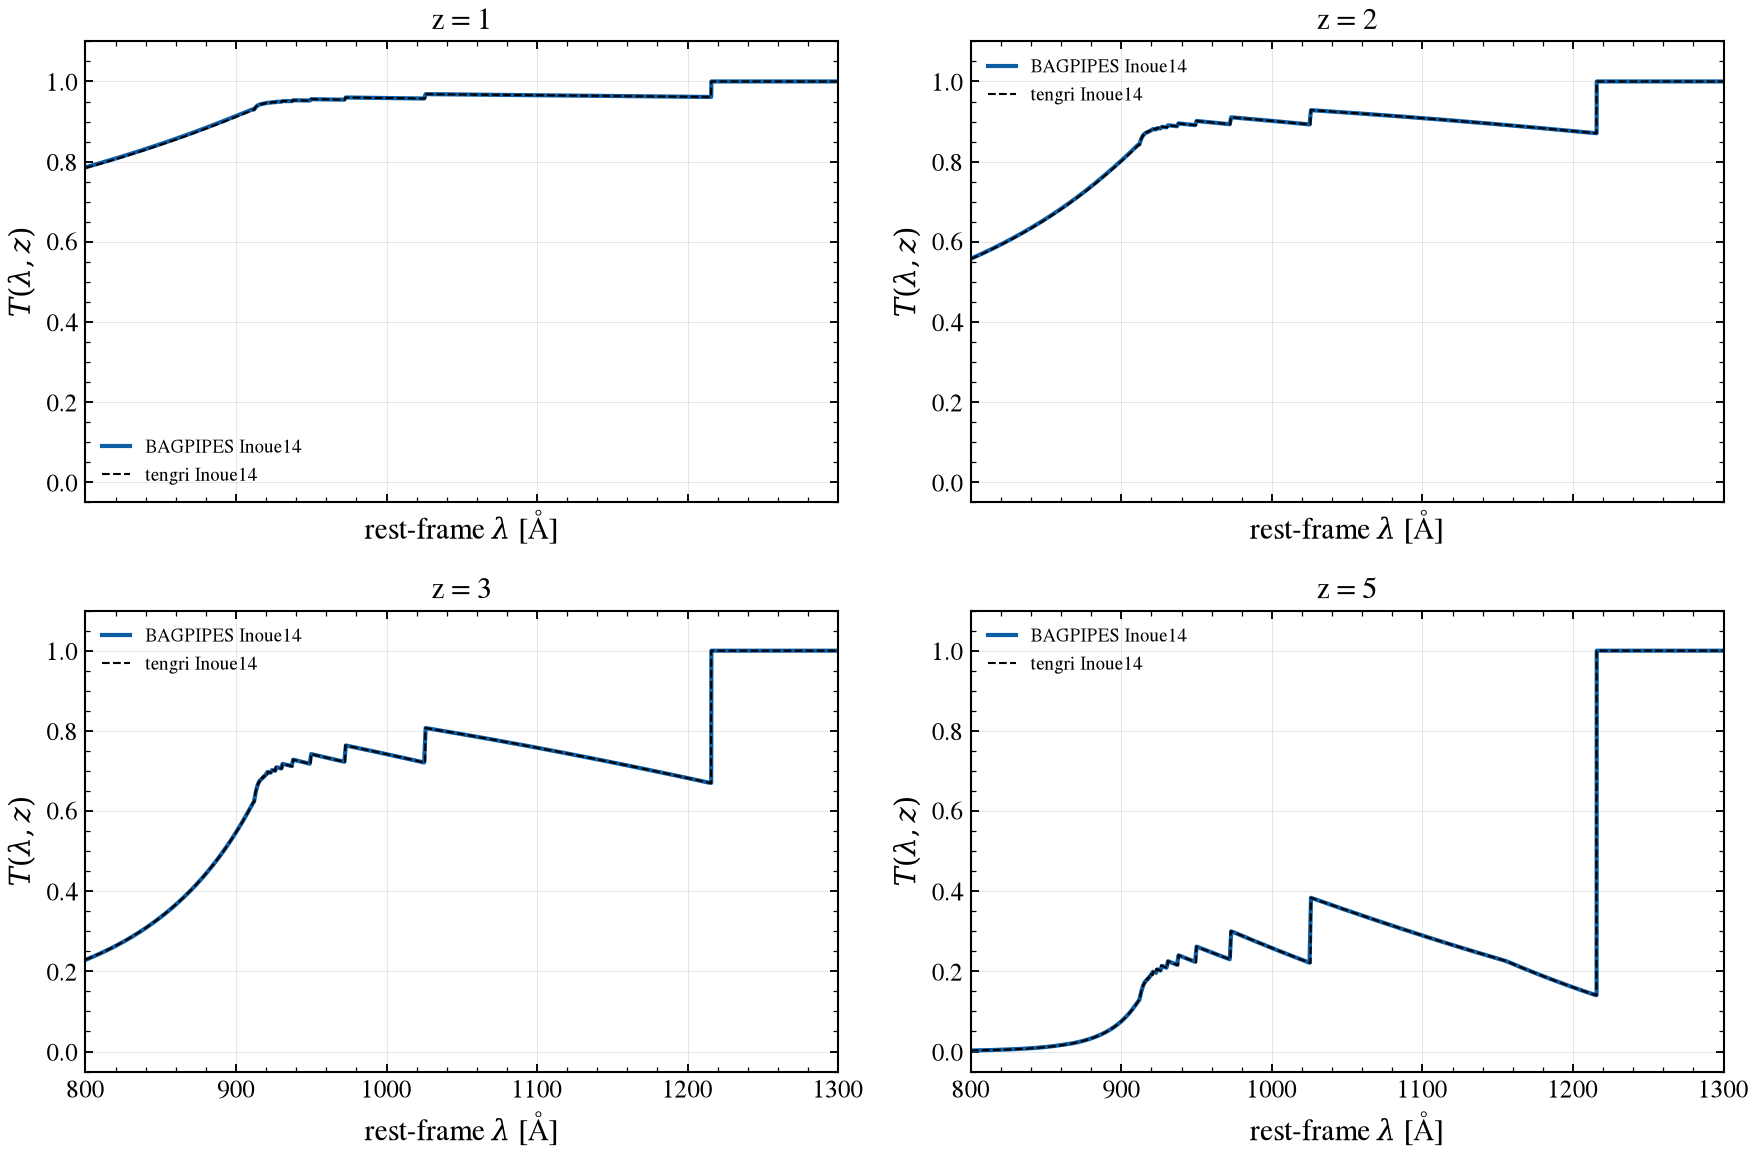

In [28]:
from tengri import igm_transmission as _tngigm_sweep

igm_zreds = [1.0, 2.0, 3.0, 5.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

cases_igm = []
for ax, z in zip(axes, igm_zreds):
    w_b_igm_z, T_b_igm_z = B.igm_transmission(z)

    wave_obs_z = w_b_igm_z * (1.0 + z)
    T_t_igm_z = np.asarray(_tngigm_sweep(wave_obs_z, np.asarray(z)))
    _assert_comparable(T_b_igm_z, T_t_igm_z, name=f"§11 z={z:.0f}")
    cases_igm.append((f"z={z:.0f}", w_b_igm_z, T_b_igm_z, w_b_igm_z, T_t_igm_z))

    ax.plot(w_b_igm_z, T_b_igm_z, "C0-", linewidth=2.0, label="BAGPIPES Inoue14")
    ax.plot(w_b_igm_z, T_t_igm_z, "k--", linewidth=1.0, label="tengri Inoue14")
    ax.set_xlabel(r"rest-frame $\lambda$ [Å]")
    ax.set_ylabel(r"$T(\lambda, z)$")
    ax.set_xlim(800, 1300)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title(f"z = {z:.0f}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_fig("bagpipes_16_igm_redshifts.png")

V.print_window_table(
    V.window_rows(cases_igm, lo=850.0, hi=1210.0, rel_to="peak", peak=1.0),
    ref_name="BAGPIPES",
    title="§11 — Inoue14 IGM transmission, redshift sweep; deviation as % of unit transmission, 850–1210 Å",
)

# The two pixels that set the maxima, against BAGPIPES's table and its generator.
print("§11 transmission at the pixels that carry the maximum |Δ|: tengri / BAGPIPES table / BAGPIPES generator")
print(f"{'z':>4s} {'1025.70 Å (Lyβ edge)':>34s} {'1215.70 Å (Lyα pixel)':>34s}")
for _z in (1.0, 2.0, 3.0, 4.0, 5.0):
    _w, _T_tab = B.igm_transmission(_z)
    _T_gen = B.igm_transmission_analytic(_w, _z)
    _T_tng = np.asarray(_tngigm_sweep(_w * (1.0 + _z), np.asarray(_z)))
    _cells = []
    for _lam in (1025.70, 1215.70):
        _k = int(np.argmin(np.abs(_w - _lam)))
        _cells.append(f"{_T_tng[_k]:.4f} / {_T_tab[_k]:.4f} / {_T_gen[_k]:.4f}")
    print(f"{_z:4.0f} {_cells[0]:>34s} {_cells[1]:>34s}")
_gen_rows = []
for _z in (1.0, 2.0, 3.0, 4.0, 5.0):
    _w = B.igm_transmission(_z)[0]
    _d = np.abs(np.asarray(_tngigm_sweep(_w * (1.0 + _z), np.asarray(_z))) - B.igm_transmission_analytic(_w, _z))
    _gen_rows.append((float(_d.max()), _z, float(_w[int(np.argmax(_d))])))
_gen_dev, _gen_z, _gen_w = max(_gen_rows)
print(f"§11 max |Δ| of tengri against the BAGPIPES generator, 800-1300 Å, z = 1-5: {_gen_dev:.2e} at z = {_gen_z:g}, {_gen_w:.1f} Å rest")
_tab_dev = max(float(np.abs(np.asarray(_tngigm_sweep(B.igm_transmission(_z)[0] * (1.0 + _z), np.asarray(_z))) - B.igm_transmission(_z)[1]).max()) for _z in (1.0, 2.0, 3.0, 4.0, 5.0))
RESULTS["§11 IGM vs BAGPIPES generator"] = ("max transmission difference", _gen_dev)
RESULTS["§11 IGM vs BAGPIPES table"] = ("max transmission difference", _tab_dev)
caveat(
    f"tengri equals BAGPIPES's own Inoue et al. (2014) generator to a maximum of {_gen_dev:.1e} over $z = 1$-5 "
    f"(at {_gen_w:.1f} Å rest, the Lyman-limit pixel). Against BAGPIPES's table the maximum is {_tab_dev:.2f}, set by "
    f"two table pixels: the Lyman-$\\beta$ edge at 1025.70 Å, where the 1 Å tabulation is interpolated across the "
    f"step, and the pixel at 1215.70 Å, which BAGPIPES forces to be absorbed. tengri evaluates the formula at the "
    f"requested wavelength."
)

## §12 Photometry

The panchromatic fiducial (stellar, Calzetti, DL07, nebular) is built in both codes and compared through the
SDSS ugriz curves, first SED against SED at 10 pc with each SED integrated on its own nodes, then through each
code's own photometry output.

In [29]:
comp_b_full = {
    "redshift": 0.0,
    "delayed": {
        "metallicity": 1.0,
        "age": AGE_GYR_FIDUCIAL,
        "tau": TAU_GYR_FIDUCIAL,
        "massformed": LOG_MASS_FIDUCIAL,
    },
    "dust": {
        "type": "Calzetti",
        "Av": AV_FIDUCIAL,
        "eta": 1.0,
        "qpah": QPAH_FIDUCIAL,
        "umin": UMIN_FIDUCIAL,
        "gamma": GAMMA_FIDUCIAL,
    },
    "nebular": {"logU": -2.0},
}
mg_b_full = B._build_model(comp_b_full)
w_b_full, L_b_full = B.to_lnu(mg_b_full)

m_full = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_full = m_full.predict_state({})

_sed_full_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)

### SED-level magnitudes

AB magnitudes at 10 pc from the §12 SEDs through the same photon-weighted band average.

§12 sdss_u: BAGPIPES -16.798, tengri -16.796, Δ +0.002 mag
§12 sdss_g: BAGPIPES -18.167, tengri -18.171, Δ -0.004 mag
§12 sdss_r: BAGPIPES -18.920, tengri -18.919, Δ +0.000 mag
§12 sdss_i: BAGPIPES -19.313, tengri -19.316, Δ -0.003 mag
§12 sdss_z: BAGPIPES -19.682, tengri -19.684, Δ -0.002 mag


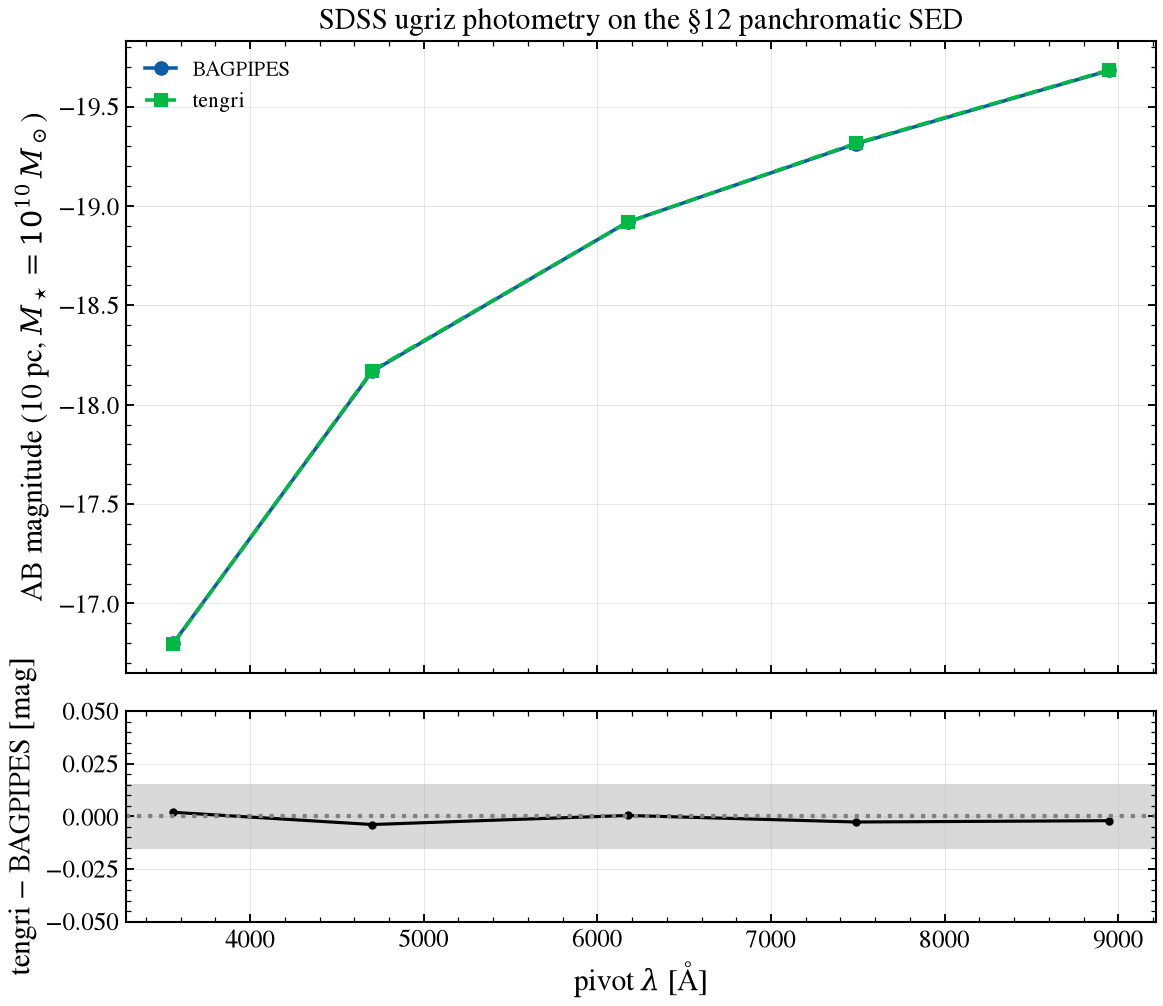

In [30]:
from tengri.filters import load_filter
from tengri.utils.physics_constants import MAGGIES_ZP_CGS, TEN_PC_CM

_sdss_bands = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
_filters = [load_filter(b) for b in _sdss_bands]
_curves = [(f.wave, f.trans / f.trans.max()) for f in _filters]
_dimm = 4.0 * np.pi * TEN_PC_CM**2  # cm², F_ν = L_ν / _dimm at 10 pc


def _band_lnu(wave, L_nu):
    """Photon-weighted band-average L_ν [erg/s/Hz] through each SDSS curve, on the SED's own nodes."""
    return np.array([V.band_average(wave, L_nu, fw, ft, integrate="sed") for fw, ft in _curves])


def _ab_mag(L_nu_band):
    """AB magnitude of a band-averaged L_ν [erg/s/Hz] at 10 pc."""
    return -2.5 * np.log10(np.asarray(L_nu_band) / _dimm / MAGGIES_ZP_CGS)


bp_mags = _ab_mag(_band_lnu(w_b_full, L_b_full))
_L_t_full = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)
tng_mags = _ab_mag(_band_lnu(np.asarray(s_full.wave), _L_t_full))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
_pivot = np.array([V.pivot_wavelength(fw, ft) for fw, ft in _curves])
ax_top.plot(_pivot, bp_mags, "o-", color="C0", linewidth=1.7, label="BAGPIPES")
ax_top.plot(_pivot, tng_mags, "s--", color="C1", linewidth=1.7, label="tengri")
ax_top.invert_yaxis()
ax_top.set_ylabel(r"AB magnitude (10 pc, $M_\star = 10^{10}\,M_\odot$)")
ax_top.set_title("SDSS ugriz photometry on the §12 panchromatic SED")
ax_top.grid(True, alpha=0.3)
ax_top.legend(fontsize=10)
ax_bot.plot(_pivot, np.array(tng_mags) - np.array(bp_mags), "k.-", linewidth=1.5)
ax_bot.axhline(0.0, color="gray", linestyle=":")
ax_bot.axhspan(-0.015, 0.015, color="0.85", zorder=0)
ax_bot.set_xlabel(r"pivot $\lambda$ [Å]")
ax_bot.set_ylabel("tengri − BAGPIPES [mag]")
ax_bot.set_ylim(-0.05, 0.05)
ax_bot.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("bagpipes_17_photometry_sdss.png")

for band, m_b, m_t in zip(_sdss_bands, bp_mags, tng_mags):
    print(f"§12 {band}: BAGPIPES {m_b:.3f}, tengri {m_t:.3f}, Δ {m_t - m_b:+.3f} mag")
RESULTS["§12 SED-level SDSS magnitudes"] = ("worst band, tengri - BAGPIPES", float(np.max(np.abs(np.array(tng_mags) - np.array(bp_mags)))))

### Budget

The difference tengri $-$ BAGPIPES in each band is the sum of four terms, obtained by replacing BAGPIPES's
piece by tengri's one at a time: intrinsic stellar light, dust transmission (Calzetti curve with the IR
re-emission), nebular lines (each code's attenuated line table) and nebular continuum. The pieces sum to
the full-model difference by construction.

§12 budget of tengri − BAGPIPES [mag], SDSS bands (SED-level, 10 pc):
                       sdss_u   sdss_g   sdss_r   sdss_i   sdss_z
intrinsic stellar     -0.0026  -0.0024  -0.0029  -0.0032  -0.0034
dust transmission     -0.0052  -0.0015  +0.0010  +0.0004  +0.0003
nebular lines         +0.0105  -0.0003  +0.0022  +0.0001  +0.0010
nebular continuum     -0.0007  +0.0003  +0.0001  +0.0001  +0.0001
sum of pieces         +0.0019  -0.0039  +0.0004  -0.0027  -0.0020
full model            +0.0019  -0.0039  +0.0004  -0.0027  -0.0020
lines, tengri/BAGPIPES      0.807    1.005    0.955    0.961    0.902
continuum, tengri/BAGPIPES    1.011    0.963    0.985    0.991    0.984


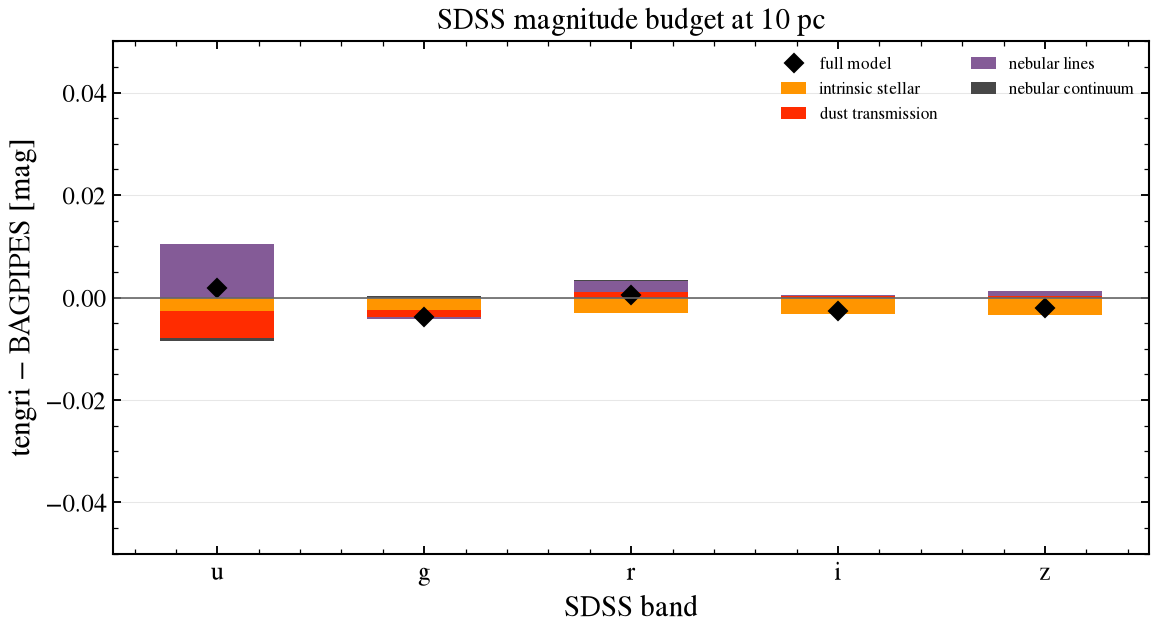

In [31]:
comp_b_nonneb = dict(comp_b_full)
del comp_b_nonneb["nebular"]
mg_b_nonneb = B._build_model(comp_b_nonneb)
w_b_nonneb, L_b_nonneb = B.to_lnu(mg_b_nonneb)

m_full_nonneb = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_full_nonneb = m_full_nonneb.predict_state({})
_L_t_nonneb = np.asarray(s_full_nonneb.derived["sed_dust_attenuated"]) + np.asarray(
    s_full_nonneb.derived["sed_dust_ir"]
)

# Intrinsic stellar light (no dust, no nebular): the §4 models.
w_b_int, L_b_int = B.stellar_only_lnu(
    massformed=LOG_MASS_FIDUCIAL,
    metallicity=1.0,
    age_max=AGE_GYR_FIDUCIAL,
    tau=TAU_GYR_FIDUCIAL,
    sfh_type="delayed",
)
s_int = m_stellar.predict_state({})
_w_t_full = np.asarray(s_full.wave)


def _line_band_lnu(wave, lum):
    """Band-average L_ν [erg/s/Hz] that a set of lines (wavelength [Å], luminosity [erg/s]) adds.

    A line of luminosity F at wavelength λ0 adds F λ0 T(λ0) / c to the numerator of the
    photon-weighted average, which is normalized by ∫ T dλ / λ.
    """
    out = []
    for fw, ft in _curves:
        T = np.interp(wave, fw, ft, left=0.0, right=0.0)
        out.append(np.sum(lum * wave * T) / U.C_ANGSTROM_PER_S / np.trapezoid(ft / fw, fw))
    return np.array(out)


# Band quantities, tengri (t) and BAGPIPES (b): I intrinsic stellar, S stellar + dust (no
# nebular), F full model; N = F − S is the nebular block, split into its lines (from each
# code's attenuated line table) and the continuum C = N − lines.
_I_t, _I_b = _band_lnu(np.asarray(s_int.wave), np.asarray(s_int.sed_intrinsic)), _band_lnu(w_b_int, L_b_int)
_S_t, _S_b = _band_lnu(np.asarray(s_full_nonneb.wave), _L_t_nonneb), _band_lnu(w_b_nonneb, L_b_nonneb)
_F_t, _F_b = _band_lnu(_w_t_full, _L_t_full), _band_lnu(w_b_full, L_b_full)
_N_t, _N_b = _F_t - _S_t, _F_b - _S_b
_wl_b, _ll_b = B.line_table(mg_b_full)
_Ln_b = _line_band_lnu(_wl_b, _ll_b)
_Ln_t = _line_band_lnu(
    np.asarray(s_full.derived["line_waves"]), 10.0 ** np.asarray(s_full.derived["log_line_lums_attenuated"])
)
_C_t, _C_b = _N_t - _Ln_t, _N_b - _Ln_b


def _mag(x):
    return -2.5 * np.log10(x)


# Replace BAGPIPES's pieces by tengri's one at a time; each step's magnitude change is
# that piece's share of tengri − BAGPIPES, and the steps sum to the full-model difference.
_S_b_with_I_t = _S_b * _I_t / _I_b
PHOT_BUDGET = {
    "intrinsic stellar": _mag(_S_b_with_I_t + _N_b) - _mag(_S_b + _N_b),
    "dust transmission": _mag(_S_t + _N_b) - _mag(_S_b_with_I_t + _N_b),
    "nebular lines": _mag(_S_t + _Ln_t + _C_b) - _mag(_S_t + _Ln_b + _C_b),
    "nebular continuum": _mag(_S_t + _Ln_t + _C_t) - _mag(_S_t + _Ln_t + _C_b),
}
PHOT_BUDGET_SUM = sum(PHOT_BUDGET.values())
PHOT_BUDGET_TOTAL = _mag(_F_t) - _mag(_F_b)

print("§12 budget of tengri − BAGPIPES [mag], SDSS bands (SED-level, 10 pc):")
print(f"{'':20s}" + "".join(f"{b:>9s}" for b in _sdss_bands))
for _name, _vals in PHOT_BUDGET.items():
    print(f"{_name:20s}" + "".join(f"{v:+9.4f}" for v in _vals))
print(f"{'sum of pieces':20s}" + "".join(f"{v:+9.4f}" for v in PHOT_BUDGET_SUM))
print(f"{'full model':20s}" + "".join(f"{v:+9.4f}" for v in PHOT_BUDGET_TOTAL))
print(
    f"{'lines, tengri/BAGPIPES':24s}" + "".join(f"{v:9.3f}" for v in _Ln_t / _Ln_b)
    + f"\n{'continuum, tengri/BAGPIPES':24s}" + "".join(f"{v:9.3f}" for v in _C_t / _C_b)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
_x = np.arange(len(_sdss_bands))
_pos = np.zeros(len(_sdss_bands))
_neg = np.zeros(len(_sdss_bands))
for _i, (_name, _vals) in enumerate(PHOT_BUDGET.items()):
    _base = np.where(_vals >= 0, _pos, _neg)
    ax.bar(_x, _vals, bottom=_base, width=0.55, color=f"C{_i + 2}", label=_name)
    _pos = _pos + np.where(_vals >= 0, _vals, 0.0)
    _neg = _neg + np.where(_vals < 0, _vals, 0.0)
ax.plot(_x, PHOT_BUDGET_TOTAL, "kD", label="full model")
ax.axhline(0.0, color="0.4", linewidth=0.8)
ax.set_xticks(_x, [b.split("_")[1] for b in _sdss_bands])
ax.set_ylim(-0.05, 0.05)
ax.set_xlabel("SDSS band")
ax.set_ylabel("tengri − BAGPIPES [mag]")
ax.set_title("SDSS magnitude budget at 10 pc")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
save_fig("bagpipes_18_photometry_budget.png")

### $z = 0.5$ at SED level

The §12 SED at $z = 0.5$ with the Inoue et al. (2014) transmission applied on both sides, in the rest-frame
$L_\nu$ convention (no luminosity distance, so the cosmology drops out).

In [32]:
Z_PHOT = 0.5

w_b_igm_z05, T_b_igm_z05 = B.igm_transmission(Z_PHOT)
T_b_on_full = np.interp(w_b_full, w_b_igm_z05, T_b_igm_z05, left=0.0, right=1.0)
L_b_z05 = L_b_full * T_b_on_full
wave_b_obs_z05 = w_b_full * (1.0 + Z_PHOT)

wave_t_obs_z05 = np.asarray(s_full.wave) * (1.0 + Z_PHOT)
T_t_igm_z05 = np.asarray(_tngigm(wave_t_obs_z05, np.asarray(Z_PHOT)))
L_t_z05 = _L_t_full * T_t_igm_z05

_assert_comparable(L_b_z05, L_t_z05, name="§12 photometry z=0.5")

bp_mags_z05 = _ab_mag(_band_lnu(wave_b_obs_z05, L_b_z05))
tng_mags_z05 = _ab_mag(_band_lnu(wave_t_obs_z05, L_t_z05))
print(f"§12 SDSS photometry at z = {Z_PHOT}:")
print(f"{'band':8s} BAGPIPES  tengri  Δ mag")
for _b, _mb, _mt in zip(_sdss_bands, bp_mags_z05, tng_mags_z05):
    print(f"{_b:8s} {_mb:7.3f}  {_mt:7.3f}  {_mt - _mb:+.3f}")

§12 SDSS photometry at z = 0.5:
band     BAGPIPES  tengri  Δ mag
sdss_u   -15.587  -15.600  -0.012
sdss_g   -16.331  -16.340  -0.009
sdss_r   -17.596  -17.599  -0.003
sdss_i   -18.376  -18.380  -0.003
sdss_z   -18.817  -18.817  -0.001


### Each code's own photometry

BAGPIPES's `model_galaxy(components, filt_list=...)` photometry against tengri's `pred.photometry()` through the
same five SDSS curves (written to two-column files for BAGPIPES). BAGPIPES returns a band-averaged $F_\lambda$
converted to $F_\nu$ with its effective wavelength, on a model grid of $R_{\rm phot} = 100$ across the filters; the
table also gives $R_{\rm phot} = 1000$. At $z = 0$ BAGPIPES's `spectrum_full` is the luminosity, so the 10 pc flux is
that value over $4\pi(10\,\mathrm{pc})^2$. At $z = 0.5$ each code uses its own luminosity distance.

In [33]:
from tengri.cosmology import luminosity_distance as _tng_dl


def _full_model_with_filters(redshift):
    """The §12 fiducial as a tengri model that projects the five SDSS bands."""
    return SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh={
            "type": "delayed",
            "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
            "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
            "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation={
            "type": "two_component",
            "law_bc": "calzetti",
            "law_diff": "calzetti",
            "tau_bc": Fixed(TAU_BC),
            "tau_diff": Fixed(TAU_DIFF),
            "all_params": Fixed(DEFAULT),
        },
        dust_emission={
            "type": "draine_li2007",
            "qpah": Fixed(QPAH_FIDUCIAL),
            "umin": Fixed(UMIN_FIDUCIAL),
            "gamma_dl": Fixed(GAMMA_FIDUCIAL),
            "all_params": Fixed(DEFAULT),
        },
        neb={
            "type": "cue",
            "neb_logU": Fixed(-2.0),
            "neb_logZ_gas": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        filters=_filters,
        redshift=Fixed(redshift),
    )


def _ab_from_fnu(F_nu):
    return -2.5 * np.log10(np.asarray(F_nu) / MAGGIES_ZP_CGS)


OWN_PHOT = {}
for _z in (0.0, 0.5):
    _comp = dict(comp_b_full)
    _comp["redshift"] = _z
    # microjansky at z > 0; L_ν × 1e29 at z = 0, where BAGPIPES returns the luminosity
    _unit = 1e-29 / (_dimm if _z == 0.0 else 1.0)
    _fb = {conv: B.own_photometry(_comp, _curves, converged=conv) * _unit for conv in (False, True)}
    _ft = np.asarray(_full_model_with_filters(_z).predict({}).photometry())
    OWN_PHOT[_z] = {
        "BAGPIPES R_phot=100": _ab_from_fnu(_fb[False]),
        "BAGPIPES R_phot=1000": _ab_from_fnu(_fb[True]),
        "tengri": _ab_from_fnu(_ft),
    }

print("§12 own photometry, AB mag (z = 0: 10 pc) and tengri − BAGPIPES [mag]")
for _z, _res in OWN_PHOT.items():
    print(f" z = {_z:g}")
    print(f"  {'band':8s} {'B R=100':>9s} {'B R=1000':>9s} {'tengri':>9s} {'Δ(100)':>8s} {'Δ(1000)':>8s}")
    for _i, _b in enumerate(_sdss_bands):
        _m100, _m1000, _mt = (_res[k][_i] for k in ("BAGPIPES R_phot=100", "BAGPIPES R_phot=1000", "tengri"))
        print(f"  {_b:8s} {_m100:9.3f} {_m1000:9.3f} {_mt:9.3f} {_mt - _m100:+8.3f} {_mt - _m1000:+8.3f}")

import bagpipes.utils as _bp_utils

_dl_t = float(_tng_dl(0.5))
_dl_b = 3.086e24 * float(np.interp(0.5, _bp_utils.z_array, _bp_utils.ldist_at_z))
DM_DIFF_Z05 = 5.0 * np.log10(_dl_t / _dl_b)
print(
    f"§12 luminosity distance at z = 0.5: tengri {_dl_t:.4e} cm, BAGPIPES {_dl_b:.4e} cm; "
    f"distance-modulus difference {DM_DIFF_Z05:+.4f} mag"
)
_d_corr = OWN_PHOT[0.5]["tengri"] - OWN_PHOT[0.5]["BAGPIPES R_phot=1000"] - DM_DIFF_Z05
print("§12 z = 0.5, tengri − BAGPIPES (R_phot = 1000) after removing it: " + " ".join(f"{v:+.3f}" for v in _d_corr))
RESULTS["§12 own photometry, z = 0"] = ("worst band, R_phot = 1000", float(np.max(np.abs(OWN_PHOT[0.0]["tengri"] - OWN_PHOT[0.0]["BAGPIPES R_phot=1000"]))))
RESULTS["§12 own photometry, z = 0.5 (after D_L)"] = ("worst band, distance modulus removed", float(np.max(np.abs(_d_corr))))
_raw05 = OWN_PHOT[0.5]["tengri"] - OWN_PHOT[0.5]["BAGPIPES R_phot=1000"]
caveat(
    f"at $z = 0.5$ tengri is fainter than BAGPIPES by {_raw05.min():.3f} to {_raw05.max():.3f} mag in the five bands. "
    f"That difference is the luminosity distance, not the SED: the two codes use the cosmologies printed in the "
    f"Setup, giving $D_L$ = {_dl_t:.4e} cm (tengri) and {_dl_b:.4e} cm (BAGPIPES), a distance-modulus difference of "
    f"{DM_DIFF_Z05:+.4f} mag. With it removed the residuals are {_d_corr.min():+.3f} to {_d_corr.max():+.3f} mag. "
    f"tengri's cosmology is not a build option, so the offset is to be expected when a BAGPIPES fit at fixed redshift "
    f"is compared in absolute flux."
)

§12 own photometry, AB mag (z = 0: 10 pc) and tengri − BAGPIPES [mag]
 z = 0
  band       B R=100  B R=1000    tengri   Δ(100)  Δ(1000)
  sdss_u     -16.808   -16.798   -16.796   +0.012   +0.002
  sdss_g     -18.162   -18.168   -18.171   -0.010   -0.004
  sdss_r     -18.924   -18.920   -18.919   +0.005   +0.001
  sdss_i     -19.311   -19.313   -19.316   -0.005   -0.003
  sdss_z     -19.676   -19.682   -19.684   -0.008   -0.002
 z = 0.5
  band       B R=100  B R=1000    tengri   Δ(100)  Δ(1000)
  sdss_u      26.238    26.234    26.287   +0.049   +0.053
  sdss_g      25.498    25.490    25.546   +0.048   +0.056
  sdss_r      24.209    24.225    24.287   +0.078   +0.062
  sdss_i      23.453    23.445    23.507   +0.053   +0.062
  sdss_z      23.003    23.005    23.069   +0.066   +0.065
§12 luminosity distance at z = 0.5: tengri 9.0090e+27 cm, BAGPIPES 8.7424e+27 cm; distance-modulus difference +0.0652 mag
§12 z = 0.5, tengri − BAGPIPES (R_phot = 1000) after removing it: -0.012 -0.009 -0.0

**Caveat:** at $z = 0.5$ tengri is fainter than BAGPIPES by 0.053 to 0.065 mag in the five bands. That difference is the luminosity distance, not the SED: the two codes use the cosmologies printed in the Setup, giving $D_L$ = 9.0090e+27 cm (tengri) and 8.7424e+27 cm (BAGPIPES), a distance-modulus difference of +0.0652 mag. With it removed the residuals are -0.012 to -0.001 mag. tengri's cosmology is not a build option, so the offset is to be expected when a BAGPIPES fit at fixed redshift is compared in absolute flux.

## §13 Panchromatic head-to-head

tengri configured as above, overlaid on BAGPIPES's full output at the fiducial parameters. The residual panel
is sized to the continuum claim, and emission lines fall outside it; the optical normalization is the median
of tengri/BAGPIPES over 1000-10000 Å with its 16-84 % spread.

full-SED head-to-head tengri/BAGPIPES optical (1000–10000 Å): normalization 1.008×, 16–84% spread 1.002–1.018×


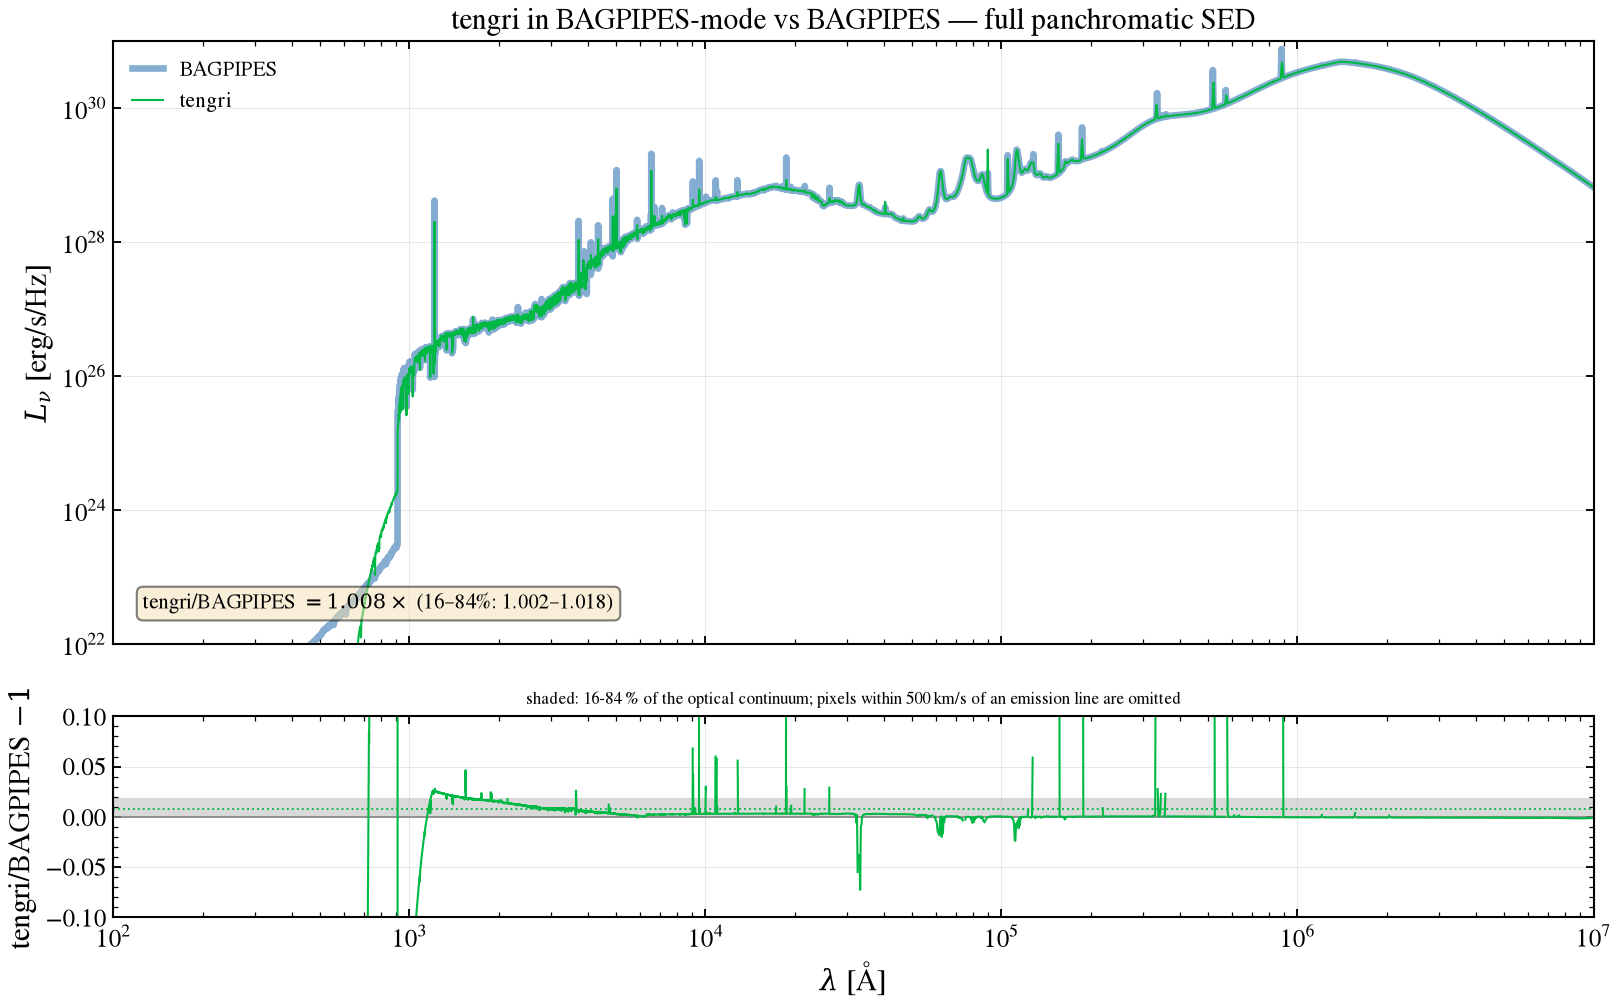

In [34]:
import chex

# Reuse the §12 panchromatic full SED: tengri's BAGPIPES-mode model and
# BAGPIPES' own output, both at the fiducial galaxy.
w_ext, L_ext = np.asarray(w_b_full), np.asarray(L_b_full)
wave_t = np.asarray(s_full.wave)
L_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)

# Put tengri on BAGPIPES' wavelength grid so the two compare point for point.
L_t_on_ext = U.regrid(wave_t, L_t, w_ext)
chex.assert_equal_shape([L_ext, L_t_on_ext])

mask = (w_ext > 0) & (L_ext > 0) & (L_t_on_ext > 0)
resid = np.full(w_ext.shape, np.nan, dtype=float)
resid[mask] = L_t_on_ext[mask] / L_ext[mask] - 1.0

# Optical normalization of the continuum: median and robust 16-84 % spread of tengri/BAGPIPES.
opt = mask & (w_ext >= 1000.0) & (w_ext <= 10000.0)
ratio_opt = L_t_on_ext[opt] / L_ext[opt]
norm = float(np.median(ratio_opt))
p16, p84 = float(np.percentile(ratio_opt, 16)), float(np.percentile(ratio_opt, 84))
print(
    f"full-SED head-to-head tengri/BAGPIPES optical (1000–10000 Å): "
    f"normalization {norm:.3f}×, 16–84% spread {p16:.3f}–{p84:.3f}×"
)
_assert_comparable(L_ext, L_t, name="full-SED head-to-head")

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
ax.plot(w_ext, L_ext, "C0-", linewidth=3.2, alpha=0.5, label="BAGPIPES")
ax.plot(w_ext, L_t_on_ext, "C1-", linewidth=1.0, label="tengri")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e7)
ax.set_ylim(1e22, 1e31)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.set_title("tengri in BAGPIPES-mode vs BAGPIPES — full panchromatic SED")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(
    0.02,
    0.05,
    rf"tengri/BAGPIPES $= {norm:.3f}\times$ (16–84%: {p16:.3f}–{p84:.3f})",
    transform=ax.transAxes,
    fontsize=10,
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

ax_r.axhspan(p16 - 1.0, p84 - 1.0, color="0.85", zorder=0)
ax_r.axhline(0.0, color="0.5", linewidth=0.8)
ax_r.axhline(norm - 1.0, color="C1", linestyle=":", linewidth=0.9)
ax_r.plot(w_ext, np.where(V.line_window_mask(w_ext, LINE_MASK_AA), np.nan, resid), "C1-", linewidth=1.0)
ax_r.set_xscale("log")
ax_r.set_xlim(1e2, 1e7)
ax_r.set_ylim(-0.1, 0.1)
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"tengri/BAGPIPES $-1$")
ax_r.set_title("shaded: 16-84 % of the optical continuum; pixels within 500 km/s of an emission line are omitted", fontsize=8)
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("bagpipes_19_headtohead.png")
plt.show()

RESULTS["§13 head-to-head (optical continuum)"] = ("median tengri/BAGPIPES, 1000-10000 A", abs(norm - 1.0))

## Summary

Section by section at matched inputs: the table is assembled from the values the cells above computed, and
the class column states what the remaining difference is. Cells with a **Caveat:** block give the numbers on
both sides and the reason the section's conclusion survives it.

| Section | Quantity | Deviation | Class |
|---|---|---|---|
| Setup BAGPIPES sampling | band average, 2x vs 1x sampling | 0.0001 | numerical |
| §1 SSP templates | max SSP flux deviation | 1.7e-06 | numerical |
| §2 SFH: formed mass | integrated SFR, BAGPIPES vs 1e10 | 3.1e-05 | numerical |
| §2 SFH forms | worst band ratio over the six forms | 0.022 | reference code |
| §3 continuity SFH | worst stellar band ratio over the three histories | 0.0021 | numerical |
| §4 composite stellar SED | optical median, 3000-10000 A | 0.0026 | reference code |
| §5 metallicity | worst band, nodes and between nodes | 0.09 | convention |
| §6 attenuation curves | Calzetti A/A_V at 1500 A | 0.0076 | reference code |
| §7 birth-cloud gate (eta = 2, 30 Myr burst) | worst UV-NIR band | 0.23 | convention |
| §7 attenuated SED | worst band over the sweeps (Calzetti A_V=3) | 0.057 | reference code |
| §8 dust emission | worst IR band over the DL07 sweep (q_PAH=0.47) | 0.06 | open |
| §8 energy balance (L_abs) | L_abs, nebular off, default | 0.099 | convention |
| §9 [N II] 6584 (Z = 0.3 Z☉, matched [N/O]) | line-table luminosity | 0.23 | open |
| §9 nebular lines ([O II] 3727, logU = -2) | line-table luminosity | 0.23 | open |
| §9 escape fraction (f_esc = 0.5) | line scaling | 0.23 | convention |
| §9 H-alpha per photon (Z = 2.5 Z☉) | BAGPIPES vs case B | 0.74 | open |
| §10 line widths | tengri fitted FWHM at width 0 vs kernel | 0.0069 | numerical |
| §11 IGM vs BAGPIPES generator | max transmission difference | 0.0022 | numerical |
| §11 IGM vs BAGPIPES table | max transmission difference | 0.86 | reference code |
| §12 SED-level SDSS magnitudes | worst band, tengri - BAGPIPES | 0.0039 mag | reference code |
| §12 own photometry, z = 0 | worst band, R_phot = 1000 | 0.0038 mag | numerical |
| §12 own photometry, z = 0.5 (after D_L) | worst band, distance modulus removed | 0.012 mag | convention |
| §13 head-to-head (optical continuum) | median tengri/BAGPIPES, 1000-10000 A | 0.0077 | reference code |

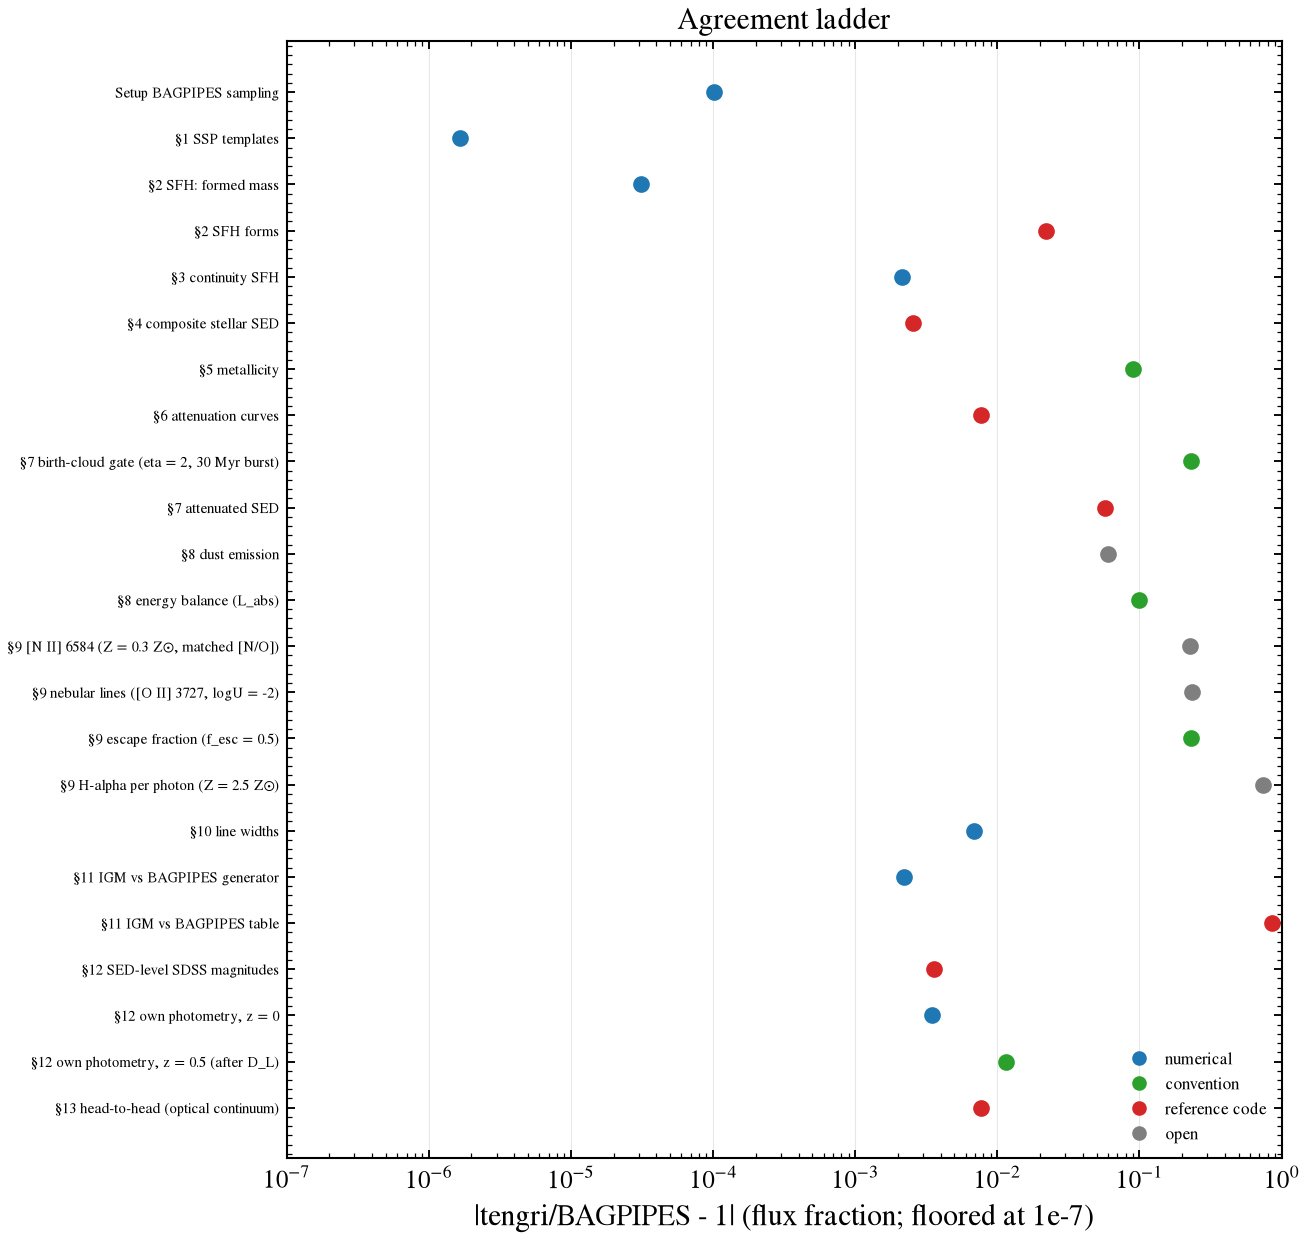

In [35]:
# The class of each comparison: numerical (sampling or quadrature), convention (a documented choice of
# one code), reference code (a BAGPIPES-side behavior), open (cause not isolated).
CLASSES = {
    "Setup BAGPIPES sampling": "numerical",
    "§1 SSP templates": "numerical",
    "§2 SFH: formed mass": "numerical",
    "§2 SFH forms": "reference code",
    "§3 continuity SFH": "numerical",
    "§4 composite stellar SED": "reference code",
    "§5 metallicity": "convention",
    "§6 attenuation curves": "reference code",
    "§7 birth-cloud gate (eta = 2, 30 Myr burst)": "convention",
    "§7 attenuated SED": "reference code",
    "§8 dust emission": "open",
    "§8 energy balance (L_abs)": "convention",
    "§9 nebular lines ([O II] 3727, logU = -2)": "open",
    "§9 [N II] 6584 (Z = 0.3 Z☉, matched [N/O])": "open",
    "§9 escape fraction (f_esc = 0.5)": "convention",
    "§9 H-alpha per photon (Z = 2.5 Z☉)": "open",
    "§10 line widths": "numerical",
    "§11 IGM vs BAGPIPES generator": "numerical",
    "§11 IGM vs BAGPIPES table": "reference code",
    "§12 SED-level SDSS magnitudes": "reference code",
    "§12 own photometry, z = 0": "numerical",
    "§12 own photometry, z = 0.5 (after D_L)": "convention",
    "§13 head-to-head (optical continuum)": "reference code",
}
_missing = sorted(set(RESULTS) - set(CLASSES))
assert not _missing, f"results without a class: {_missing}"
_stale = sorted(set(CLASSES) - set(RESULTS))
assert not _stale, f"classes without a result: {_stale}"


def _frac(v):
    return v


_rows = ["| Section | Quantity | Deviation | Class |", "|---|---|---|---|"]
_unit = {"§12 SED-level SDSS magnitudes": "mag", "§12 own photometry, z = 0": "mag", "§12 own photometry, z = 0.5 (after D_L)": "mag"}
for _key, (_what, _val) in RESULTS.items():
    _u = _unit.get(_key, "")
    _rows.append(f"| {_key} | {_what} | {_val:.2g}{' ' + _u if _u else ''} | {CLASSES[_key]} |")
display(Markdown("\n".join(_rows)))

# Agreement ladder: one marker per row on a log axis; magnitudes converted to a flux fraction.
_fig_vals = {
    k: (10.0 ** (0.4 * v) - 1.0 if _unit.get(k) == "mag" else v) for k, (_, v) in RESULTS.items()
}
_class_color = {"numerical": "#1f77b4", "convention": "#2ca02c", "reference code": "#d62728", "open": "#7f7f7f"}
fig, ax = plt.subplots(figsize=(9, 0.32 * len(_fig_vals) + 1.2))
for _i, (_key, _v) in enumerate(_fig_vals.items()):
    ax.plot(max(_v, 1e-7), len(_fig_vals) - 1 - _i, "o", color=_class_color[CLASSES[_key]], markersize=7)
ax.set_yticks(range(len(_fig_vals)), list(_fig_vals)[::-1], fontsize=7)
ax.set_xscale("log")
ax.set_xlim(1e-7, 1.0)
ax.set_xlabel("|tengri/BAGPIPES - 1| (flux fraction; floored at 1e-7)")
ax.set_title("Agreement ladder")
ax.grid(True, axis="x", alpha=0.3)
ax.legend(
    handles=[Line2D([], [], marker="o", linestyle="none", color=c, label=k) for k, c in _class_color.items()],
    fontsize=8,
    loc="lower right",
)
fig.tight_layout()
save_fig("bagpipes_20_agreement_ladder.png")

## References

* Carnall et al. 2018, MNRAS 480, 4379: BAGPIPES
* Bruzual & Charlot 2003, MNRAS 344, 1000: BC03 SSPs
* Sánchez-Blázquez et al. 2006, MNRAS 371, 703: MILES library
* Kroupa 2001, MNRAS 322, 231: IMF
* Leja et al. 2019, ApJ 876, 3: continuity SFH
* Calzetti et al. 2000, ApJ 533, 682: starburst attenuation
* Cardelli, Clayton & Mathis 1989, ApJ 345, 245: MW extinction
* Charlot & Fall 2000, ApJ 539, 718: two-component dust
* Salim, Boquien & Lee 2018, ApJ 859, 11: attenuation modification
* Draine & Li 2007, ApJ 657, 810: dust IR emission
* Dopita, Kewley, Heisler & Sutherland 2000, ApJ 542, 224, "A Theoretical Recalibration of the Extragalactic H II Region Sequence": solar abundances and depletion
* Inoue et al. 2014, MNRAS 442, 1805: IGM absorption
* Li et al. 2025, ApJ 986, 9 (arXiv:2405.04598): Cue nebular emulator